In [ ]:
# 上から順に実行

In [1]:
#PyTorchのimport
#IProgress not foundのエラーは無視
import torch, torch.nn as nn, torch.nn.functional as F
from transformers import DetrModel, DetrFeatureExtractor
import numpy as np, cv2, random, math, matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from torch.utils.data import Dataset, DataLoader

C:\Users\afmpc\anaconda3\envs\torchcuda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#GPU使用チェック
print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version  :", torch.version.cuda)
    print("cuDNN version :", torch.backends.cudnn.version())
    print("Device count  :", torch.cuda.device_count())
    print("Device name   :", torch.cuda.get_device_name(0))
    
    # 簡単なテスト計算
    x = torch.rand(10000, 10000, device="cuda")
    y = torch.mm(x, x)
    print("Matrix multiply test OK, result shape:", y.shape)
else:
    print("⚠️ GPU が検出されていません。ドライバや CUDA インストールを確認してください。")


PyTorch version: 2.8.0+cu129
CUDA available : True
CUDA version  : 12.9
cuDNN version : 91002
Device count  : 1
Device name   : NVIDIA GeForce RTX 5070 Ti
Matrix multiply test OK, result shape: torch.Size([10000, 10000])


In [4]:
import torch
import torch.nn as nn
from transformers import DetrModel, DetrConfig
class RingDETR_HF(nn.Module):
    def __init__(self, num_classes=1, num_queries=100, pretrained=True):
        super().__init__()
        self.num_classes = num_classes
        self.num_queries = num_queries

        if pretrained:
            config = DetrConfig.from_pretrained("facebook/detr-resnet-50")
            config.num_queries = num_queries
            self.backbone = DetrModel.from_pretrained(
                "facebook/detr-resnet-50",
                config=config,
                low_cpu_mem_usage=False,
                device_map=None,
                ignore_mismatched_sizes=True
            )
        else:
            config = DetrConfig(num_queries=num_queries)
            self.backbone = DetrModel(config)

        hidden_dim = self.backbone.config.d_model
        self.class_embed = nn.Linear(hidden_dim, num_classes + 1)
        self.param_embed = nn.Linear(hidden_dim, 5)  # 5次元に変更: [cx, cy, a, b, angle]

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)
        hs = outputs.last_hidden_state  # (B, Q, hidden_dim)
        out_logits = self.class_embed(hs)                 # (B, Q, num_classes+1)
        out_params = torch.sigmoid(self.param_embed(hs))  # (B, Q, 5) 正規化 [0,1]
        return {"pred_logits": out_logits, "pred_params": out_params}

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HungarianMatcher(nn.Module):
    def __init__(self, cost_class=6, cost_bbox=5):
        super().__init__()
        self.cost_class = cost_class; self.cost_bbox = cost_bbox
    @torch.no_grad()
    # 例: your HungarianMatcher.forward 内
    def forward(self, outputs, targets):
        logits = outputs["pred_logits"]         # (B,Q,C+1)
        params = outputs["pred_params"]         # (B,Q,5) 0..1
    
        # --- 安全な p_ring とクラスコスト ---
        probs   = torch.softmax(logits, dim=-1)              # (B,Q,C+1)
        p_noobj = probs[..., -1]
        p_ring  = (1.0 - p_noobj).clamp_(min=1e-6, max=1-1e-6)
        cost_class_allQ = -torch.log(p_ring)                 # (B,Q)
    
        out_bbox = params
        indices = []
        B, Q, _ = out_bbox.shape
        for b in range(B):
            tgt = targets[b]
            tgt_bbox = tgt["params"]
            # --- (A) ターゲット 0 件なら空の対応を返す ---
            if tgt_bbox.numel() == 0:
                indices.append((
                    torch.empty(0, dtype=torch.int64, device=out_bbox.device),
                    torch.empty(0, dtype=torch.int64, device=out_bbox.device)
                ))
                continue
    
            # --- (B) コスト計算（NaN/Inf を丸める） ---
            cost_class = cost_class_allQ[b].unsqueeze(1).expand(Q, tgt_bbox.size(0))
            cost_bbox  = torch.cdist(out_bbox[b], tgt_bbox, p=1)             # (Q,Ni)
    
            # ここで数値を掃除
            cost_class = torch.nan_to_num(cost_class, nan=1e4, posinf=1e4, neginf=1e4)
            cost_bbox  = torch.nan_to_num(cost_bbox,  nan=1e4, posinf=1e4, neginf=1e4)
    
            C = self.cost_class * cost_class + self.cost_bbox * cost_bbox
            C = torch.nan_to_num(C, nan=1e4, posinf=1e4, neginf=1e4).cpu().numpy()
    
            # --- デバッグ: もし万一不正値があればバッチ情報を出す ---
            if not np.isfinite(C).all():
                print("[matcher] non-finite cost detected.",
                      "logits finite:", torch.isfinite(logits[b]).all().item(),
                      "params finite:", torch.isfinite(out_bbox[b]).all().item(),
                      "tgt finite:", torch.isfinite(tgt_bbox).all().item())
                # 応急処置：全部 1e4 にして続行（クラッシュ回避）
                C = np.nan_to_num(C, nan=1e4, posinf=1e4, neginf=1e4)
    
            i, j = linear_sum_assignment(C)
            indices.append((
                torch.as_tensor(i, dtype=torch.int64, device=out_bbox.device),
                torch.as_tensor(j, dtype=torch.int64, device=out_bbox.device),
            ))
        return indices



class SetCriterion(nn.Module):
    def __init__(self, num_classes, matcher, weight_dict, eos_coef=0.4):
        super().__init__()
        self.num_classes  = num_classes
        self.matcher      = matcher
        self.weight_dict  = weight_dict
        # CE 用のクラス重み: [cls0(=ring), ..., no-object]
        empty_weight = torch.ones(self.num_classes + 1, dtype=torch.float32)
        empty_weight[-1] = eos_coef  # no-object だけ軽くする（例: 0.1〜0.5）
        self.register_buffer("empty_weight", empty_weight)

    # ---- utilities
    @staticmethod
    def _get_src_permutation_idx(indices):
        # indices: list of (src_idx, tgt_idx) for each batch item
        device = None
        non_empty = []
        for i, (src, _) in enumerate(indices):
            if device is None:
                device = src.device if hasattr(src, "device") else torch.device("cpu")
            if src.numel() > 0:
                non_empty.append((i, src))
    
        if len(non_empty) == 0:
            # 空でも device は返す
            empty = torch.empty(0, dtype=torch.long, device=device or torch.device("cpu"))
            return empty, empty
    
        batch_idx = torch.cat([torch.full_like(src, i) for i, src in non_empty], dim=0)
        src_idx   = torch.cat([src for _, src in non_empty], dim=0)
        return batch_idx, src_idx


    @staticmethod
    def _num_targets(targets):
        # バッチ中の全インスタンス数（L1の正規化に使用）
        return sum(t["labels"].numel() for t in targets)

    # ---- losses
    def loss_labels(self, outputs, targets, indices):
        src_logits = outputs["pred_logits"]  # (B, Q, C+1)
        B, Q, _ = src_logits.shape
    
        # 既定は no-object（=最後のクラス）
        target_classes = torch.full((B, Q), self.num_classes,
                                    dtype=torch.long, device=src_logits.device)
    
        # マッチしている分だけ上書き
        cats = []
        idx  = []
        for b, (src_idx, tgt_idx) in enumerate(indices):
            if src_idx.numel() > 0:
                cats.append(targets[b]["labels"][tgt_idx])
                idx.append((b, src_idx))
        if len(cats) > 0:
            target_classes[torch.cat([torch.full_like(s, b) for b, s in idx], dim=0),
                           torch.cat([s for _, s in idx], dim=0)] = torch.cat(cats, dim=0)
    
        return F.cross_entropy(src_logits.transpose(1, 2), target_classes, weight=self.empty_weight)

    def loss_params(self, outputs, targets, indices):
        if len(indices) == 0:
            return torch.tensor(0.0, device=outputs["pred_params"].device)
    
        batch_idx, src_idx = self._get_src_permutation_idx(indices)
        if src_idx.numel() == 0:
            return torch.tensor(0.0, device=outputs["pred_params"].device)
    
        src_params = outputs["pred_params"][batch_idx, src_idx]  # (M, 6)
        tgt_params = torch.cat([t["params"][J] for t, (_, J) in zip(targets, indices) if J.numel() > 0], dim=0)
    
        if tgt_params.numel() == 0:
            return torch.tensor(0.0, device=outputs["pred_params"].device)
    
        return F.l1_loss(src_params, tgt_params, reduction="sum") / tgt_params.size(0)

    # ---- main
    def forward(self, outputs, targets):
        """
        outputs: {"pred_logits": (B,Q,C+1), "pred_params": (B,Q,6)}
        targets: list of dicts { "labels":(Ni,), "params":(Ni,6) }
        """
        # Hungarian matching
        indices = self.matcher(outputs, targets)

        loss_ce   = self.loss_labels(outputs, targets, indices)
        loss_bbox = self.loss_params(outputs, targets, indices)

        loss = (self.weight_dict.get("loss_ce", 1.0)  * loss_ce +
                self.weight_dict.get("loss_bbox", 1.0) * loss_bbox)

        return {"loss": loss, "loss_ce": loss_ce, "loss_bbox": loss_bbox}


In [6]:
import json, os
from pathlib import Path
import cv2
import numpy as np
import torch

def save_ring_dataset(root_dir, split, images, labels):
    """
    images: list[np.ndarray(H,W) uint8]
    labels: list[{"labels": Tensor[n], "params": Tensor[n,6]}] （正規化）
    保存先: root_dir/split/{images, labels.jsonl}
    """
    root = Path(root_dir) / split
    img_dir = root / "images"
    img_dir.mkdir(parents=True, exist_ok=True)
    jl_path = root / "labels.jsonl"
    with open(jl_path, "w", encoding="utf-8") as f:
        for i, (img, lab) in enumerate(zip(images, labels)):
            fname = f"img_{i:06d}.png"
            cv2.imwrite(str(img_dir / fname), img)
            params = lab["params"].cpu().numpy().tolist()
            rec = {"file": fname, "params": params}
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    print(f"[OK] saved: {img_dir} ({len(images)} images) & {jl_path}")

def dataset_exists(root_dir, split):
    root = Path(root_dir) / split
    return (root / "images").exists() and (root / "labels.jsonl").exists()


from torch.utils.data import Dataset

class RingFolderDataset(Dataset):
    def __init__(self, root_dir, split="train", resize_to=(512,512)):
        self.root = Path(root_dir) / split
        self.img_dir = self.root / "images"
        self.jl_path = self.root / "labels.jsonl"
        self.resize_to = resize_to
        self.records = []
        with open(self.jl_path, "r", encoding="utf-8") as f:
            for line in f:
                obj = json.loads(line)
                self.records.append(obj)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        ip  = str(self.img_dir / rec["file"])
        img = cv2.imread(ip, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise RuntimeError(f"画像の読み込みに失敗しました: {ip}")
        if self.resize_to is not None:
            Rh, Rw = self.resize_to
            img = cv2.resize(img, (Rw, Rh), interpolation=cv2.INTER_AREA)

        img3 = np.repeat(img[..., None], 3, axis=2).astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img3 = (img3 - mean) / std
        img_t = torch.from_numpy(img3.transpose(2, 0, 1)).float()

        params_np = np.array(rec["params"], dtype=np.float32)
        p = torch.from_numpy(params_np)
        if p.ndim == 1:
            p = p.view(-1, 6)
        elif p.numel() == 0:
            p = torch.zeros((0, 6), dtype=torch.float32)
        if p.shape[-1] == 6:
            p = p[:, :5]  # 厚み(th)をここで落とす
        elif p.shape[-1] != 5:
            raise RuntimeError(f"params の次元が不正です: {p.shape}")

        tgt = {
            "labels": torch.zeros(len(p), dtype=torch.long),
            "params": p
        }
        return img_t, tgt


In [7]:
# =========================================
# 合成リング生成 v6（形状統一/円切替、半径で明るさ、3モード半径分布 改良版）
# =========================================
import numpy as np, cv2, torch, random, math
from typing import List, Tuple

# ---------- ここだけ触れば挙動が変えられる「定数ブロック」 ----------
SIZES_LIST            = "649x649, 420x421, 383x382, 512x511"
SIZE_JITTER           = 0.08
RINGS_DENSITY         = 120.0
RINGS_DENSITY_JITTER  = 0.9
RINGS_MIN, RINGS_MAX  = 2, 150

RMIN_FRAC, RMAX_FRAC  = 0.02, 0.15
THICK_MIN_FRAC        = 0.0004
THICK_MAX_FRAC        = 0.0001

# --- 形状モード: "shared_ellipse" / "circle_only" / "independent"
SHAPE_MODE = "shared_ellipse"
GLOBAL_ELLIPSE_RATIO_RANGE = (0.85, 1.25)
GLOBAL_ELLIPSE_ANGLE_RANGE = (175.0, 185.0)

BREAK_PROB_SOFT       = 0.35
BREAK_PROB_STRONG     = 0.20
ARC_KEEP_FRAC_RANGE   = (0.5, 0.9)
OCCLUDER_PROB         = 0.0
OCCLUDER_MAX_N        = 3

# --- 明るさ設定（半径と連動）
INTENSITY_MIN, INTENSITY_MAX = 100, 255
INTENSITY_SIZE_GAMMA   = 0.6
INTENSITY_JITTER_FRAC  = 0.8

ILLUM_STRENGTH_RANGE  = (0.05, 0.15)
MOTION_BLUR_PROB      = 0.05
DEFOCUS_BLUR_PROB     = 0.05
PIXELATE_PROB         = 0.05
SPECKLE_PROB          = 1.0
POISSON_PROB          = 1.0
SCANLINE_PROB         = 0.05
ELLIPSE_PROB          = 1.0
SEED_DEFAULT          = 0

AFM_SPECKLE_PROB      = 0.05
AFM_GRAIN_RANGE       = (10, 24)
AFM_STRENGTH_RANGE    = (0.25, 0.60)
AFM_OCTAVES           = 3

# --- 小さすぎるリングは塗りつぶし ---
FILL_SMALL_ENABLE      = True
FILL_R_MAX_FRAC        = 0.08
FILL_THICK_RATIO_THR   = 0.15

# 追加の定数
MIN_THICK_PX           = 0.0
VISIBLE_MIN_PX         = 1.0

# --- 密度が高いほど半径を小さめにする ---
DENSITY_REF_MPX        = 80.0
DENSITY_SHRINK_K       = 20
RMIN_KEEP_FRAC         = 0.8

# --- 端で見切れるリング ---
EDGE_CUT_PROB          = 0.30
EDGE_MARGIN_FRAC       = 0.10
EDGE_CUT_MODE          = "shift_center"
EDGE_CROP_FRAC_RANGE   = (0.15, 0.45)
EDGE_CENTER_EPS_PX     = 1.0

# リング0個の画像も混ぜる
ZERO_IMG_PROB          = 0.10

# --- 半径の3モード分布（小:中:大） ---
# （基準ウェイト／中心分位／相対σ）
SIZE_CLUSTER_WEIGHTS   = (0.35, 0.35, 0.3)
SIZE_CLUSTER_POSITIONS = (0.1, 0.50, 0.94)
SIZE_CLUSTER_REL_SIGMA = (0.05, 0.08, 0.06)

# ★NEW/CHANGED: クラスタ生成の“揺らぎ”＆密度バイアス設定
SIZE_DIRICHLET_CONC    = 40.0   # 画像ごとのクラスタ比率のばらつき（大→固定化、小→変動大）
SIZE_QJITTER_STD       = 0.06   # 中心分位のジッタ（±）
SIZE_SIGMA_DENS_BIAS   = 0.30   # 密なとき小径クラスタのσを広げる度合い
DENSITY_WEIGHT_BIAS    = 0.60   # 密なとき小径クラスタの重みを上げる（大径は下げる）

# ----------------------------------------------------------------------

def _parse_sizes_list(sizes_list: str) -> List[Tuple[int,int]]:
    items = [t.strip().lower() for t in sizes_list.replace(",", " ").split() if "x" in t]
    out = []
    for it in items:
        w,h = it.split("x")
        out.append((int(h), int(w)))  # (H,W)
    if not out:
        raise ValueError("SIZES_LIST の書式は 'WxH, WxH, ...' です")
    return out

def _illumination(img, strength=0.35, sigma=101):
    h,w = img.shape
    f = np.random.rand(h,w).astype(np.float32)
    f = cv2.GaussianBlur(f, (0,0), sigmaX=sigma, sigmaY=sigma)
    f = (f-f.min())/(f.max()-f.min()+1e-8)
    f = 1.0 - strength*f
    out = img.astype(np.float32)*f
    return np.clip(out,0,255).astype(np.uint8)

def _random_motion_blur(img, k_range=(5,25)):
    k=int(np.random.randint(*k_range));  k+= (k%2==0)
    angle=np.random.uniform(0,180)
    ker=np.zeros((k,k),np.float32); cv2.line(ker,(k//2,0),(k//2,k-1),1.0,1)
    M=cv2.getRotationMatrix2D((k/2-0.5,k/2-0.5),angle,1.0)
    ker=cv2.warpAffine(ker,M,(k,k)); ker/= (ker.sum()+1e-8)
    return cv2.filter2D(img,-1,ker)

def _random_defocus_blur(img, r_range=(2,7)):
    r=int(np.random.randint(*r_range)); k=2*r+1
    return cv2.GaussianBlur(img,(k,k),0)

def _pixelate(img, scale_range=(0.3,0.95)):
    h, w = img.shape
    s = np.random.uniform(*scale_range)
    nh, nw = max(4, int(h*s)), max(4, int(w*s))
    small = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_NEAREST)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)
    
def _speckle(img, std_range=(0.02,0.2)):
    std=np.random.uniform(*std_range)
    x=img.astype(np.float32)/255.0
    noise=np.random.randn(*img.shape).astype(np.float32)*std
    return np.clip((x+x*noise)*255.0,0,255).astype(np.uint8)

def _afm_coarse_speckle(img, grain=16, strength=0.4, octaves=3):
    h, w = img.shape
    x = img.astype(np.float32) / 255.0
    def make_band(scale):
        hh = max(4, h // scale)
        ww = max(4, w // scale)
        n  = np.random.randn(hh, ww).astype(np.float32)
        n  = cv2.resize(n, (w, h), interpolation=cv2.INTER_CUBIC)
        ks = max(3, int(scale//2)*2+1)
        n  = cv2.GaussianBlur(n, (ks, ks), 0)
        return n
    noise = np.zeros((h, w), np.float32)
    amp = 1.0
    scale = grain
    for _ in range(max(1, int(octaves))):
        noise += amp * make_band(scale)
        amp   *= 0.5
        scale  = max(4, int(scale * 0.6))
    noise -= noise.min(); noise /= (noise.max() + 1e-8)
    noise = (noise * 2.0 - 1.0) * strength
    out = x * (1.0 + noise)
    return (np.clip(out, 0.0, 1.0) * 255.0).astype(np.uint8)

def _poisson(img, scale=25.0, strength=3.0):
    vals = img.astype(np.float32)
    lam  = np.maximum(1.0, vals/255.0 * scale)
    noisy = np.random.poisson(lam).astype(np.float32)
    out = (noisy - lam) * strength + lam
    return np.clip(out/scale*255.0, 0, 255).astype(np.uint8)

def _scanlines(img, prob=1.0):
    if np.random.rand()>prob: return img
    h,w=img.shape; out=img.astype(np.int16).copy()
    for _ in range(np.random.randint(1,4)):
        y=np.random.randint(0,h); amp=np.random.randint(-40,40)
        out[y,:]=np.clip(out[y,:]+amp,0,255)
    return out.astype(np.uint8)

def _ring_mask_circle(h,w,cx,cy,r_out,t):
    r_in=max(1.0, r_out-t)
    mo=np.zeros((h,w),np.uint8); mi=np.zeros((h,w),np.uint8)
    cv2.circle(mo,(int(cx),int(cy)),int(round(r_out)),255,-1, lineType=cv2.LINE_AA)
    cv2.circle(mi,(int(cx),int(cy)),int(round(r_in)),255,-1, lineType=cv2.LINE_AA)
    return cv2.subtract(mo,mi)

def _ring_mask_ellipse(h,w,cx,cy,rx,ry,t,angle=0.0):
    rxi=max(1.0, rx-t); ryi=max(1.0, ry-t)
    mo=np.zeros((h,w),np.uint8); mi=np.zeros((h,w),np.uint8)
    cv2.ellipse(mo,(int(cx),int(cy)),(int(rx),int(ry)),angle,0,360,255,-1, lineType=cv2.LINE_AA)
    cv2.ellipse(mi,(int(cx),int(cy)),(int(rxi),int(ryi)),angle,0,360,255,-1, lineType=cv2.LINE_AA)
    return cv2.subtract(mo,mi)

def _soft_break(mask, gaps=(1,2)):
    h,w=mask.shape
    for _ in range(np.random.randint(gaps[0], gaps[1]+1)):
        p1=(np.random.randint(0,w), np.random.randint(0,h))
        p2=(np.random.randint(0,w), np.random.randint(0,h))
        cv2.line(mask, p1, p2, 0, thickness=np.random.randint(2,8), lineType=cv2.LINE_AA)
    return mask

def _strong_break_soft(mask, cx, cy, rx, ry, angle_deg, keep_frac,
                       atten=0.25, feather=4.0, gamma=0.7, force_core_one=True):
    h, w = mask.shape
    span = 360.0 * float(keep_frac)
    a0 = np.random.uniform(0, 360-span); a1 = a0 + span
    t_est = max(1, int(round((rx + ry) * 0.03)))
    t_outer = t_est; t_inner = max(1, t_est - 2)
    arc_bin = np.zeros_like(mask)
    cv2.ellipse(arc_bin, (int(cx), int(cy)), (int(rx), int(ry)),
                angle_deg, a0, a1, 255, thickness=t_outer, lineType=cv2.LINE_AA)
    inner = np.zeros_like(mask)
    cv2.ellipse(inner, (int(cx), int(cy)), (int(max(1, rx-2)), int(max(1, ry-2))),
                angle_deg, a0, a1, 255, thickness=t_inner, lineType=cv2.LINE_AA)
    arc_bin = cv2.subtract(arc_bin, inner)
    if feather and feather > 0:
        k = int(max(1, round(feather*2)) | 1)
        arc_soft = cv2.GaussianBlur(arc_bin, (k, k), feather)
    else:
        arc_soft = arc_bin.copy()
    arc_soft = arc_soft.astype(np.float32)
    m = arc_soft.max()
    if m > 0: arc_soft /= m
    arc_soft = np.power(arc_soft, gamma)
    if force_core_one:
        arc_soft = np.maximum(arc_soft, (arc_bin > 127).astype(np.float32))
    gain = atten + (1.0 - atten) * arc_soft
    return (mask.astype(np.float32) * gain).clip(0, 255).astype(np.uint8)

def _random_occluders(mask, max_n=2):
    h,w=mask.shape
    for _ in range(np.random.randint(1, max_n+1)):
        if np.random.rand() < 0.5:
            cx,cy=np.random.randint(0,w),np.random.randint(0,h)
            rx,ry=np.random.randint(10,w//4),np.random.randint(10,h//4)
            a=np.random.uniform(0,180)
            cv2.ellipse(mask,(cx,cy),(rx,ry),a,0,360,0,-1, lineType=cv2.LINE_AA)
        else:
            x1,y1=np.random.randint(0,w),np.random.randint(0,h)
            x2,y2=np.random.randint(0,w),np.random.randint(0,h)
            cv2.rectangle(mask,(min(x1,x2),min(y1,y2)),(max(x1,x2),max(y1,y2)),0,-1)
    return mask

# ---- 3モード半径のサンプル関数（改良版）----
def _sample_radii_clustered(rng, n, rmin, rmax, dens_ratio=1.0):  # ★NEW/CHANGED
    """
    画像ごとに:
      - クラスタ比率: Dirichlet でサンプル（ベース比率に収束しつつ適度に揺れる）
      - 中心分位: 少しジッタ（0.05..0.95に制限）、昇順に並べ替え
      - 各クラスタ: 対数空間でサンプル（乗法ノイズ）→ [rmin,rmax] でクリップ
      - 密度が高いほど: 小径の重み↑、小径σ↑（微調整）
      - クラスタ境界（隣接中心の中点）でトリミング→混ざりを抑制
    """
    if n <= 0: return []

    # --- 密度バイアス（小径↑, 大径↓）
    small_bias = max(0.0, DENSITY_WEIGHT_BIAS * (dens_ratio - 1.0))
    bias_vec = np.array([1.0 + small_bias, 1.0, 1.0 / (1.0 + small_bias)], dtype=np.float64)

    base_w = np.array(SIZE_CLUSTER_WEIGHTS, dtype=np.float64)
    base_w = base_w / base_w.sum()
    w_biased = base_w * bias_vec
    w_biased = w_biased / w_biased.sum()

    # Dirichlet で揺らぎ
    alpha = SIZE_DIRICHLET_CONC * w_biased
    w_img = rng.dirichlet(alpha)
    counts = rng.multinomial(n, w_img).tolist()  # [ns, nm, nl]

    # 中心分位をジッタ
    q0 = np.array(SIZE_CLUSTER_POSITIONS, dtype=np.float64)
    q  = q0 + rng.normal(loc=0.0, scale=SIZE_QJITTER_STD, size=3)
    q  = np.clip(q, 0.05, 0.95)
    # r空間の中心
    centers = rmin + q * (rmax - rmin)

    # クラスタを中心位置で昇順に整列（weights/σ/カウントも揃える）
    order = np.argsort(centers)
    centers = centers[order]
    counts  = [counts[i] for i in order]
    relsig  = np.array(SIZE_CLUSTER_REL_SIGMA, dtype=np.float64)[order]

    # 密度で小径σを少し広げる
    sigma_scale = np.array([1.0 + SIZE_SIGMA_DENS_BIAS * max(0.0, dens_ratio - 1.0), 1.0, 1.0], dtype=np.float64)
    sigma_scale = sigma_scale[order]
    relsig = np.clip(relsig * sigma_scale, 1e-4, 0.50)

    # 対数空間のσに変換（relσ ≈ 幾何標準偏差-1 とみなす簡易式）
    # relσが小さいとき、 log(1+relσ^2) ≈ relσ^2
    sigma_log = np.sqrt(np.log(1.0 + np.square(relsig)))

    # クラスタ境界（隣同士の中点）で切るレンジ
    bounds_low  = np.empty(3, dtype=np.float64)
    bounds_high = np.empty(3, dtype=np.float64)
    bounds_low[0]  = rmin
    bounds_high[-1] = rmax
    mid01 = 0.5*(centers[0] + centers[1])
    mid12 = 0.5*(centers[1] + centers[2])
    bounds_high[0] = mid01; bounds_low[1] = mid01
    bounds_high[1] = mid12; bounds_low[2] = mid12

    out = []
    for idx, (c, slog, k) in enumerate(zip(centers, sigma_log, counts)):
        if k <= 0: continue
        mu = np.log(max(1e-6, c))
        # 対数正規でサンプル
        rs = rng.lognormal(mean=mu, sigma=float(slog), size=k)
        # [rmin,rmax]にまずクリップ
        rs = np.clip(rs, rmin, rmax)
        # クラスタ境界でもトリミング（小/中/大の分離を維持）
        rs = np.clip(rs, bounds_low[idx], bounds_high[idx])
        out.extend(rs.tolist())

    rng.shuffle(out)
    return out

def make_synth_dataset_params_v6(n_samples=200, seed=SEED_DEFAULT):
    rng = np.random.RandomState(seed)
    sizes = _parse_sizes_list(SIZES_LIST)

    images, labels = [], []
    for _ in range(n_samples):
        # ---- 画像サイズ（ジッタ込み）
        H0,W0 = random.choice(sizes)
        if SIZE_JITTER>0:
            H = max(64, int(round(H0 * rng.uniform(1-SIZE_JITTER, 1+SIZE_JITTER))))
            W = max(64, int(round(W0 * rng.uniform(1-SIZE_JITTER, 1+SIZE_JITTER))))
        else:
            H,W = H0,W0

        # 背景
        bg = rng.uniform(25, 110)
        img = np.full((H,W), bg, np.uint8)
        params = []

        # ---- 個数（面積×密度のポアソン）
        area_mpx = (H*W)/1e6
        dens = max(1e-6, RINGS_DENSITY * rng.uniform(1-RINGS_DENSITY_JITTER, 1+RINGS_DENSITY_JITTER))
        n_rings = int(np.random.poisson(dens * area_mpx))
        if RINGS_MIN >= 0: n_rings=max(n_rings, RINGS_MIN)
        if RINGS_MAX >= 0: n_rings=min(n_rings, RINGS_MAX)
        if rng.rand() < ZERO_IMG_PROB: n_rings = 0

        base=min(H,W)
        dens_ratio   = (dens / max(1e-6, DENSITY_REF_MPX))
        shrink_factor = 1.0 / (1.0 + DENSITY_SHRINK_K*(dens_ratio-1.0))
        shrink_factor = float(np.clip(shrink_factor, 0.55, 1.0))
        rmin_base, rmax_base = base*RMIN_FRAC, base*RMAX_FRAC
        rmax = rmax_base * shrink_factor
        rmin = rmin_base * (1.0 - (1.0-shrink_factor)*(1.0-RMIN_KEEP_FRAC))

        # ---- 画像内で共通の“楕円形状”を決める（SHAPE_MODE）
        if SHAPE_MODE == "shared_ellipse":
            ratio = rng.uniform(*GLOBAL_ELLIPSE_RATIO_RANGE)   # ry/rx
            angle = rng.uniform(*GLOBAL_ELLIPSE_ANGLE_RANGE)   # [deg]
        elif SHAPE_MODE == "circle_only":
            ratio = 1.0
            angle = 0.0
        else:  # independent
            ratio = None
            angle = None

        # ---- 半径を3モードで割当（密度バイアスを渡す）★CHANGED
        radii = _sample_radii_clustered(rng, n_rings, rmin, rmax, dens_ratio=dens_ratio)

        # 画素系の見た目のための縮小率見積り（ここでは未使用に等しいが残す）
        if np.random.rand() < PIXELATE_PROB:
            s_est = np.random.uniform(0.45, 0.9)
        else:
            s_est = 1.0

        layer = np.zeros((H,W), np.uint8)

        for r in radii:
            # 1) 厚み t
            t = rng.uniform(base*THICK_MIN_FRAC, base*THICK_MAX_FRAC)
            t = max(MIN_THICK_PX, t)
            t = max(t, VISIBLE_MIN_PX / max(1e-6, s_est))
            thin_protect = (t < 4.5)
            soft_prob    = 0.0 if thin_protect else BREAK_PROB_SOFT
            strong_prob  = 0.0 if thin_protect else BREAK_PROB_STRONG

            # 2) 形状（画像内統一 or 円 or 個別）
            if SHAPE_MODE == "shared_ellipse":
                rx = r; ry = r * ratio; ang = angle
            elif SHAPE_MODE == "circle_only":
                rx = ry = r; ang = 0.0
            else:
                if rng.rand() < 0.5:
                    rx = r; ry = r * rng.uniform(0.8, 1.2); ang = rng.uniform(0,180)
                else:
                    rx = ry = r; ang = 0.0

            # 3) 中心座標（端で見切れあり）
            cx  = rng.uniform(rx+3, W-rx-3)
            cy  = rng.uniform(ry+3, H-ry-3)
            if rng.rand() < EDGE_CUT_PROB and EDGE_CUT_MODE == "shift_center":
                crop = rng.uniform(*EDGE_CROP_FRAC_RANGE)
                side = rng.randint(0,4)
                if side == 0:   cx = max(EDGE_CENTER_EPS_PX, rx*(1.0 - crop))
                elif side == 1: cx = min(W-EDGE_CENTER_EPS_PX, W - rx*(1.0 - crop))
                elif side == 2: cy = max(EDGE_CENTER_EPS_PX, ry*(1.0 - crop))
                else:           cy = min(H-EDGE_CENTER_EPS_PX, H - ry*(1.0 - crop))

            # 4) マスク生成
            if abs(rx-ry) < 1e-6 and ang == 0.0:
                ring = _ring_mask_circle(H,W,cx,cy,rx,t)
            else:
                ring = _ring_mask_ellipse(H,W,cx,cy,rx,ry,t,ang)

            a_out, b_out, angle_used = rx, ry, ang

            # 5) 小半径は塗りつぶし
            if FILL_SMALL_ENABLE:
                r_eff   = max(a_out, b_out)
                r_small = (r_eff <= min(H,W)*FILL_R_MAX_FRAC)
                thick_ratio = t / max(1e-6, min(a_out, b_out))
                if r_small or (thick_ratio >= FILL_THICK_RATIO_THR):
                    filled = np.zeros((H,W), np.uint8)
                    cv2.ellipse(filled, (int(cx),int(cy)),
                                (int(round(a_out)), int(round(b_out))),
                                angle_used, 0, 360, 255, -1, lineType=cv2.LINE_AA)
                    ring = filled
                    t = 0.0

            # 6) 欠損
            if np.random.rand() < soft_prob:
                ring = _soft_break(ring, gaps=(1,2))
            if np.random.rand() < strong_prob:
                keep = np.random.uniform(*ARC_KEEP_FRAC_RANGE)
                ring = _strong_break_soft(ring, cx, cy, a_out, b_out, angle_used, keep,
                                          atten=0.1, feather=4.0)

            # 7) 明るさ：半径と連動（小さいほど明るい）
            r_eff = max(a_out, b_out)
            r_norm = (r_eff - rmin) / max(1e-6, (rmax - rmin))  # 0..1
            inten_base = INTENSITY_MIN + (1.0 - (r_norm ** INTENSITY_SIZE_GAMMA)) * (INTENSITY_MAX - INTENSITY_MIN)
            inten = float(inten_base * rng.uniform(1.0-INTENSITY_JITTER_FRAC, 1.0+INTENSITY_JITTER_FRAC))
            inten = float(np.clip(inten, INTENSITY_MIN, INTENSITY_MAX))

            # 8) 合成
            alpha  = ring.astype(np.float32) / 255.0
            img    = np.maximum(img.astype(np.float32), alpha * inten).astype(np.uint8)
            layer  = np.maximum(layer, (alpha > 1e-3).astype(np.uint8)*255)

            # 9) ラベル
            params.append([
                cx/W, cy/H, a_out/W, b_out/H, angle_used/180.0,
                float(np.clip(t / max(base*THICK_MAX_FRAC,1e-6), 0, 1))
            ])

        # オクルーダ
        if np.random.rand() < OCCLUDER_PROB and n_rings>0:
            layer = _random_occluders(layer, max_n=OCCLUDER_MAX_N)
            img   = np.minimum(img, layer)

        # イルミ/ノイズ
        if np.random.rand() < 0.8:
            img = _illumination(img, strength=np.random.uniform(*ILLUM_STRENGTH_RANGE),
                                sigma=np.random.uniform(61,141))
        if np.random.rand() < AFM_SPECKLE_PROB:
            grain    = np.random.randint(AFM_GRAIN_RANGE[0], AFM_GRAIN_RANGE[1]+1)
            strength = np.random.uniform(*AFM_STRENGTH_RANGE)
            img = _afm_coarse_speckle(img, grain=grain, strength=strength, octaves=AFM_OCTAVES)
        if np.random.rand() < MOTION_BLUR_PROB:  img = _random_motion_blur(img,(5,25))
        if np.random.rand() < DEFOCUS_BLUR_PROB: img = _random_defocus_blur(img,(2,7))
        if s_est < 1.0: img = _pixelate(img, scale_range=(s_est, s_est))
        if np.random.rand() < SPECKLE_PROB:      img = _speckle(img, std_range=(0.01,0.04))
        if np.random.rand() < POISSON_PROB:      img = _poisson(img, scale=np.random.uniform(15,40))
        if np.random.rand() < SCANLINE_PROB:     img = _scanlines(img, prob=1.0)

        # 可視性ブースト
        BOOST_ADD = 15
        img = np.clip(img.astype(np.int16) + (layer > 0).astype(np.int16) * BOOST_ADD, 0, 255).astype(np.uint8)

        images.append(img)
        labels.append({"labels": torch.zeros(len(params), dtype=torch.long),
                       "params": torch.tensor(params, dtype=torch.float32)})

    return images, labels


In [8]:
# === ここでパラメータをまとめて制御（お好みで） ===
DATA_ROOT   = "data/rings_v5"   # 保存先ルート
RESIZE_TO   = (512, 512)
N_TRAIN, N_VAL = 400000, 20000
SEED_TRAIN, SEED_VAL = 11, 211


import os, math, json, cv2, numpy as np, multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path
from tqdm import tqdm

import os, json, math, cv2, numpy as np
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
import numpy as np, json, cv2, os
from tqdm import tqdm

from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
import numpy as np, json, cv2, os
from tqdm import tqdm

def _to_pylist_params(x):
    # x: torch.Tensor or np.ndarray or list
    if hasattr(x, "detach"):  # torch.Tensor
        x = x.detach().cpu().numpy()
    x = np.asarray(x, dtype=np.float32)
    # 1Dなら(1, D)に揃える、空なら(0, D)でもそのままtolistでOK
    if x.ndim == 1:
        x = x.reshape(1, -1)
    return x.tolist()
import json, numpy as np, torch, cv2
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

def _to_jsonable(obj):
    # 再帰的に Tensor/ndarray を Python 型へ変換
    if isinstance(obj, torch.Tensor):
        if obj.ndim == 0:
            return obj.detach().cpu().item()
        return obj.detach().cpu().numpy().tolist()
    if isinstance(obj, np.ndarray):
        if obj.ndim == 0:
            return obj.item()
        return obj.tolist()
    if isinstance(obj, (np.float32, np.float64, np.int32, np.int64, np.uint8)):
        return obj.item()
    if isinstance(obj, dict):
        return {k: _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_jsonable(v) for v in obj]
    return obj

def _worker_generate_shard_thread(start_idx, count, seed, resize_to, out_img_dir, tmp_jsonl_path):
    try:
        try:
            cv2.setNumThreads(1)
        except Exception:
            pass

        imgs, labels = make_synth_dataset_params_v5(n_samples=count, seed=seed)

        with open(tmp_jsonl_path, "w", encoding="utf-8") as f:
            for k, (img, rec) in enumerate(zip(imgs, labels)):
                idx = start_idx + k
                fn = f"img_{idx:06d}.png"
                ip = str(out_img_dir / fn)

                # 画像保存をuint8に統一
                if isinstance(img, torch.Tensor):
                    img = img.detach().cpu().numpy()
                if img.dtype != np.uint8:
                    img = img.astype(np.uint8)
                if img.ndim == 3 and img.shape[2] == 3:
                    cv2.imwrite(ip, cv2.cvtColor(img, cv2.COLOR_RGB2BGR), [cv2.IMWRITE_PNG_COMPRESSION, 1])
                else:
                    cv2.imwrite(ip, img, [cv2.IMWRITE_PNG_COMPRESSION, 1])

                # ラベルを深変換してから上書きでfileを付与
                rec_out = _to_jsonable(rec)
                rec_out["file"] = fn

                # よくある形の正規化（空配列や一次元の統一）
                if "params" in rec_out:
                    arr = np.asarray(rec_out["params"], dtype=np.float32)
                    if arr.ndim == 1:
                        arr = arr.reshape(1, -1)
                    rec_out["params"] = arr.tolist()

                f.write(json.dumps(rec_out, ensure_ascii=False) + "\n")

        return count

    except Exception as e:
        return RuntimeError(f"worker failed at start={start_idx} count={count}: {e}")

import os, json, math, cv2, numpy as np
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

def _encode_png_gray(img_uint8):
    # PNG圧縮はスレッドに投げるためバッファ化
    ok, buf = cv2.imencode(".png", img_uint8, [cv2.IMWRITE_PNG_COMPRESSION, 1])
    if not ok: 
        raise RuntimeError("imencode failed")
    return buf

def build_synth_streaming(
    root_dir: str, split: str, n_samples: int, seed: int, resize_to=(512,512),
    io_workers: int = 4
):
    """
    生成→即保存（画像はPNGバッファ化してThreadPoolで書き出し）
    JSONLも逐次追記。巨大リストを持たないので速くて省メモリ。
    """
    from time import perf_counter
    cv2.setUseOptimized(True)
    # マルチプロセスでなければスレッド数増やす、プロセス併用時は 1 に
    try:
        cv2.setNumThreads(max(1, os.cpu_count() // 2))
    except Exception:
        pass

    rng = np.random.default_rng(seed)
    sizes = _parse_sizes_list(SIZES_LIST)

    root = Path(root_dir) / split
    img_dir = root / "images"
    img_dir.mkdir(parents=True, exist_ok=True)
    jl_path = root / "labels.jsonl"

    # JSON は行ごと追記で OK
    jf = open(jl_path, "w", encoding="utf-8")

    # 画像保存はスレッドで非同期に（CPU→I/Oを重ねる）
    tp = ThreadPoolExecutor(max_workers=io_workers)
    pending = []

    # 再利用バッファ
    # 最大サイズ想定で確保して、必要に応じて再割当（サイズ変化時のみ）
    Hc, Wc = resize_to
    img_buf = np.zeros((Hc, Wc), np.uint8)  # 出力サイズ用
    ring_layer = np.zeros((Hc, Wc), np.uint8)


    t0 = perf_counter()
    for i in range(n_samples):
        # === 元サイズ選択 + ジッタ ===
        H0, W0 = sizes[rng.integers(0, len(sizes))]
        if SIZE_JITTER > 0:
            Hs = max(64, int(round(H0 * rng.uniform(1-SIZE_JITTER, 1+SIZE_JITTER))))
            Ws = max(64, int(round(W0 * rng.uniform(1-SIZE_JITTER, 1+SIZE_JITTER))))
        else:
            Hs, Ws = H0, W0
        if 'tmp_mask' not in locals() or tmp_mask.shape != (Hs, Ws):
            tmp_mask  = np.zeros((Hs, Ws), np.uint8)
            tmp_mask2 = np.zeros((Hs, Ws), np.uint8)
        else:
            tmp_mask.fill(0)
            tmp_mask2.fill(0)
        # 元画像を一旦生成（Hs,Ws）
        base = min(Hs, Ws)
        bg = rng.uniform(25, 110)
        img0 = np.full((Hs, Ws), int(bg), np.uint8)
        layer0 = np.zeros_like(img0)

        # 個数を一発サンプリング
        area_mpx = (Hs*Ws)/1e6
        dens = max(1e-6, RINGS_DENSITY * rng.uniform(1-RINGS_DENSITY_JITTER, 1+RINGS_DENSITY_JITTER))
        n_rings = int(rng.poisson(dens * area_mpx))
        if RINGS_MIN >= 0: n_rings = max(n_rings, RINGS_MIN)
        if RINGS_MAX >= 0: n_rings = min(n_rings, RINGS_MAX)
        if rng.random() < ZERO_IMG_PROB:
            n_rings = 0

        # 半径/厚みの上限/下限（密度依存）
        dens_ratio   = dens / max(1e-6, DENSITY_REF_MPX)
        shrink_factor = float(np.clip(1.0 / (1.0 + DENSITY_SHRINK_K*(dens_ratio-1.0)), 0.55, 1.0))
        rmin_base, rmax_base = base*RMIN_FRAC, base*RMAX_FRAC
        rmax = rmax_base * shrink_factor
        rmin = rmin_base * (1.0 - (1.0-shrink_factor)*(1.0-RMIN_KEEP_FRAC))
        tmin, tmax = max(1.0, base*THICK_MIN_FRAC), max(2.0, base*THICK_MAX_FRAC)
        t_norm_denom = base*THICK_MAX_FRAC

        # ピクセレートの有無から可視線幅の最低値を決定
        if rng.random() < PIXELATE_PROB:
            s_est = rng.uniform(0.45, 0.9)
        else:
            s_est = 1.0
        VISIBLE_MIN_PX = 6.0

        params = []
        if n_rings > 0:
            # ---- 乱数をベクトルで一括生成（Pythonループの内側でrand呼ばない）
            is_ellipse   = rng.random(n_rings) < ELLIPSE_PROB
            ang_deg_all  = rng.uniform(0, 180, size=n_rings)

            # 楕円／円の半径
            rx_all = rng.uniform(rmin, rmax, size=n_rings)
            ry_all = rx_all * rng.uniform(0.8, 1.2, size=n_rings)
            r_all  = rng.uniform(rmin, rmax, size=n_rings)

            # 厚み
            t_all  = rng.uniform(tmin, tmax, size=n_rings)
            t_all  = np.maximum(t_all, MIN_THICK_PX)
            t_all  = np.maximum(t_all, VISIBLE_MIN_PX / max(1e-6, s_est))

            # 位置
            cx_e = rng.uniform(rx_all+3, Ws-rx_all-3, size=n_rings)
            cy_e = rng.uniform(ry_all+3, Hs-ry_all-3, size=n_rings)
            cx_c = rng.uniform(r_all+3, Ws-r_all-3, size=n_rings)
            cy_c = rng.uniform(r_all+3, Hs-r_all-3, size=n_rings)

            # 端見切れ（必要分だけ判定）
            edge_flags = rng.random(n_rings) < EDGE_CUT_PROB
            edge_side  = rng.integers(0, 4, size=n_rings)
            edge_crop  = rng.uniform(*EDGE_CROP_FRAC_RANGE, size=n_rings)

            # ここから描画（python ループは残るが、rand呼び出しはゼロ）
            for k in range(n_rings):
                if is_ellipse[k]:
                    rx, ry, ang = rx_all[k], ry_all[k], ang_deg_all[k]
                    cx, cy = cx_e[k], cy_e[k]
                    if edge_flags[k] and EDGE_CUT_MODE == "shift_center":
                        crop = edge_crop[k]; side = edge_side[k]
                        if   side == 0: cx = max(EDGE_CENTER_EPS_PX, rx*(1.0-crop))
                        elif side == 1: cx = min(Ws-EDGE_CENTER_EPS_PX, Ws-rx*(1.0-crop))
                        elif side == 2: cy = max(EDGE_CENTER_EPS_PX, ry*(1.0-crop))
                        else:           cy = min(Hs-EDGE_CENTER_EPS_PX, Hs-ry*(1.0-crop))
                    # マスク描画（再利用バッファ）
                    tmp_mask.fill(0); tmp_mask2.fill(0)
                    cv2.ellipse(tmp_mask, (int(cx),int(cy)), (int(rx),int(ry)),
                                float(ang), 0, 360, 255, -1, lineType=cv2.LINE_AA)
                    cv2.ellipse(tmp_mask2, (int(cx),int(cy)), 
                                (int(max(1, rx-t_all[k])), int(max(1, ry-t_all[k]))),
                                float(ang), 0, 360, 255, -1, lineType=cv2.LINE_AA)
                    ring = cv2.subtract(tmp_mask, tmp_mask2)
                    a_out, b_out, angle = rx, ry, ang
                else:
                    r  = r_all[k]
                    cx, cy = cx_c[k], cy_c[k]
                    if edge_flags[k] and EDGE_CUT_MODE == "shift_center":
                        crop = edge_crop[k]; side = edge_side[k]
                        if   side == 0: cx = max(EDGE_CENTER_EPS_PX, r*(1.0-crop))
                        elif side == 1: cx = min(Ws-EDGE_CENTER_EPS_PX, Ws-r*(1.0-crop))
                        elif side == 2: cy = max(EDGE_CENTER_EPS_PX, r*(1.0-crop))
                        else:           cy = min(Hs-EDGE_CENTER_EPS_PX, Hs-r*(1.0-crop))
                    tmp_mask.fill(0); tmp_mask2.fill(0)
                    cv2.circle(tmp_mask, (int(cx),int(cy)), int(round(r)), 255, -1, lineType=cv2.LINE_AA)
                    cv2.circle(tmp_mask2,(int(cx),int(cy)), int(round(max(1.0, r-t_all[k]))), 255, -1, lineType=cv2.LINE_AA)
                    ring = cv2.subtract(tmp_mask, tmp_mask2)
                    a_out = b_out = r; angle = 0.0

                # 欠損（細線保護判定は t_all[k] で）
                thin = t_all[k] < 4.5
                if (not thin) and (rng.random() < BREAK_PROB_SOFT):
                    ring = _soft_break(ring, gaps=(1,2))
                if (not thin) and (rng.random() < BREAK_PROB_STRONG):
                    keep = rng.uniform(*ARC_KEEP_FRAC_RANGE)
                    ring = _strong_break_soft(ring, cx, cy, a_out, b_out, angle, keep,
                                              atten=0.1, feather=4.0)

                inten  = rng.uniform(INTENSITY_MIN, INTENSITY_MAX)
                alpha  = ring.astype(np.float32) / 255.0
                img0   = np.maximum(img0.astype(np.float32), alpha * float(int(inten))).astype(np.uint8)
                layer0 = np.maximum(layer0, (alpha > 1e-3).astype(np.uint8)*255)
                params.append([cx/Ws, cy/Hs, a_out/Ws, b_out/Hs, angle/180.0,
                               float(np.clip(t_all[k]/max(t_norm_denom,1e-6), 0, 1))])

        # ノイズ系（必要最低限）
        if rng.random() < 0.8:
            img0 = _illumination(img0, strength=rng.uniform(*ILLUM_STRENGTH_RANGE),
                                 sigma=rng.uniform(61,141))
        if rng.random() < DEFOCUS_BLUR_PROB:
            img0 = _random_defocus_blur(img0,(2,7))
        if rng.random() < SPECKLE_PROB:
            img0 = _speckle(img0, std_range=(0.01,0.04))
        if rng.random() < POISSON_PROB:
            img0 = _poisson(img0, scale=rng.uniform(15,40))

        # 可視性ブースト
        img0 = np.clip(img0.astype(np.int16) + (layer0 > 0).astype(np.int16) * 26, 0, 255).astype(np.uint8)

        # 出力サイズに合わせて1枚のバッファへ（INTER_AREA）
        if (img_buf.shape[0] != resize_to[0]) or (img_buf.shape[1] != resize_to[1]):
            img_buf = np.zeros(resize_to, np.uint8)
            ring_layer = np.zeros(resize_to, np.uint8)
            tmp_mask = np.zeros(resize_to, np.uint8)
            tmp_mask2 = np.zeros(resize_to, np.uint8)

        if (img0.shape[0], img0.shape[1]) != resize_to:
            img_resized = cv2.resize(img0, (resize_to[1], resize_to[0]), cv2.INTER_AREA)
        else:
            img_resized = img0

        # ここで即エンコード→非同期保存
        fn = f"img_{i:06d}.png"
        buf = _encode_png_gray(img_resized.copy())
        future = tp.submit((Path.write_bytes), (img_dir / fn), buf.tobytes())
        pending.append(future)

        # JSON 1行追記（すべて Python 型に）
        rec_out = {
            "file": fn,
            "labels": [0] * len(params),
            "params": np.asarray(params, dtype=np.float32).tolist()
        }
        jf.write(json.dumps(rec_out, ensure_ascii=False, separators=(",", ":")) + "\n")

        # I/Oキューが溜まりすぎないよう適度に掃除
        if len(pending) >= io_workers * 8:
            for _ in range(io_workers * 4):
                if not pending: break
                pending.pop(0).result()

    # 残ジョブ flush
    for fut in pending:
        fut.result()
    jf.close()
    tp.shutdown(wait=True)



# ① 初回：無ければ作る
if not dataset_exists(DATA_ROOT, "train") or not dataset_exists(DATA_ROOT, "val"):
    print("[i] dataset not found -> generating synthetic data (streaming + threaded I/O)")
    build_synth_streaming(DATA_ROOT, "train", n_samples=N_TRAIN, seed=SEED_TRAIN, resize_to=RESIZE_TO, io_workers=8)
    build_synth_streaming(DATA_ROOT, "val",   n_samples=N_VAL,   seed=SEED_VAL,   resize_to=RESIZE_TO, io_workers=4)
else:
    print("[i] dataset already exists:", DATA_ROOT)


# ② 学習時：フォルダから即ロード
train_ds = RingFolderDataset(DATA_ROOT, split="train", resize_to=RESIZE_TO)
val_ds   = RingFolderDataset(DATA_ROOT, split="val",   resize_to=RESIZE_TO)
print(f"[i] loaded: train={len(train_ds)}, val={len(val_ds)}")

[i] dataset already exists: data/rings_v5
[i] loaded: train=400000, val=20000


In [9]:
#Data Loader
from torch.utils.data import DataLoader
import platform
IS_WIN = (platform.system() == "Windows")
NUM_WORKERS = 0 if IS_WIN else 2
PIN_MEMORY  = torch.cuda.is_available()

def collate_fn(batch):
    imgs = torch.stack([b[0] for b in batch], dim=0)  # (B,3,H,W)
    targets = [b[1] for b in batch]                   # list of dict
    return imgs, targets

train_ld = DataLoader(train_ds, batch_size=16, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                      collate_fn=collate_fn)
val_ld   = DataLoader(val_ds, batch_size=16, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                      collate_fn=collate_fn)

In [10]:
from pathlib import Path

# --- マスクからリングパラメータ抽出 ---
def mask_to_ring_params(mask, min_area=50, max_thickness=20):
    h, w = mask.shape
    rings = []
    cnts, hier = cv2.findContours((mask>0).astype(np.uint8), cv2.RETR_CCOMP, cv2.CHAIN_APPROX_NONE)
    if hier is None:
        return []
    hier = hier[0]

    for i, cnt in enumerate(cnts):
        if hier[i][3] != -1:  # 子は無視
            continue
        if cv2.contourArea(cnt) < min_area:
            continue
        if len(cnt) >= 5:
            (cx,cy),(MA,ma),angle = cv2.fitEllipse(cnt)
            a, b = MA/2.0, ma/2.0
        else:
            (cx,cy),r = cv2.minEnclosingCircle(cnt)
            a = b = r; angle = 0.0
        thickness = 3.0  # 仮の厚み（改良可）
        rings.append([cx/w, cy/h, a/w, b/h, angle/180.0, min(thickness/max_thickness,1.0)])
    return rings

# --- マスクディレクトリから Dataset 作成 ---
def make_real_dataset_from_masks(mask_dir, max_thickness=20):
    mask_dir = Path(mask_dir)
    images, labels = [], []
    for ip in mask_dir.glob("*.png"):
        mask = cv2.imread(str(ip), cv2.IMREAD_GRAYSCALE)
        params = mask_to_ring_params(mask, max_thickness=max_thickness)
        if not params:
            continue
        images.append(mask)
        labels.append({
            "labels": torch.zeros(len(params), dtype=torch.long),
            "params": torch.tensor(params, dtype=torch.float32)
        })
    return np.array(images), labels

# --- 実験マスクから Dataset を作成 ---
real_imgs, real_labels = make_real_dataset_from_masks("preds/")  # ←マスク保存先
# real_ds = RingDataset(real_imgs, real_labels)

# --- 合成データと結合 ---
train_ds_all = torch.utils.data.ConcatDataset([train_ds])
train_ld_all = torch.utils.data.DataLoader(train_ds_all, batch_size=16, shuffle=True)

print("合成:", len(train_ds), " 合計:", len(train_ds_all))


合成: 400000  合計: 400000


合成データ例（Datasetから直接）


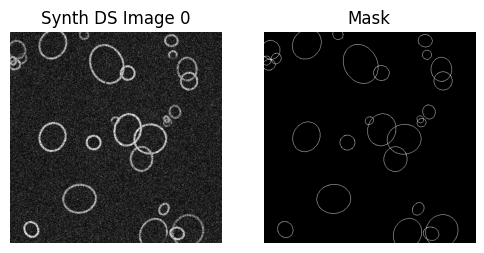

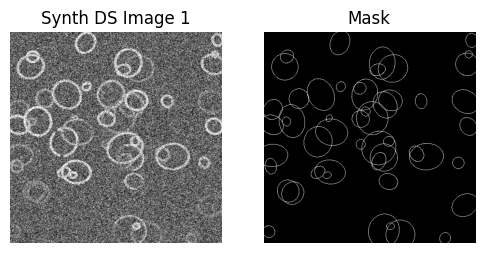

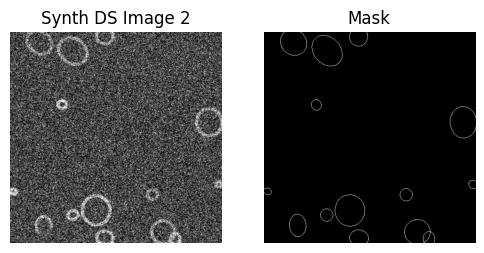

実データマスク由来
実データマスクが見つかりませんでした


In [11]:
def denorm_imagenet(img_t):
    """
    img_t: (3,H,W) torch.float
    戻り: (H,W) uint8 グレースケール
    """
    mean = torch.tensor([0.485, 0.456, 0.406], dtype=img_t.dtype, device=img_t.device)[:, None, None]
    std  = torch.tensor([0.229, 0.224, 0.225], dtype=img_t.dtype, device=img_t.device)[:, None, None]
    x = img_t * std + mean         # 0..1 スケールに戻す
    x = x.clamp(0, 1)
    g = x[0]                       # 先頭チャネルを表示用に
    return (g.cpu().numpy() * 255.0).astype(np.uint8)

def show_ring_examples_from_dataset(ds, n=3, title="Dataset"):
    for i in range(min(n, len(ds))):
        got = ds[i]
        if isinstance(got, tuple) and len(got) == 3:
            img_t, tgt, meta = got
        else:
            img_t, tgt = got
            meta = None

        img = denorm_imagenet(img_t)  # ★ 逆正規化して表示
        H, W = img.shape

        mask = np.zeros((H, W), np.uint8)
        params = tgt["params"].numpy()
        for (cx,cy,a,b,ang) in params:
            cx, cy = int(cx*W), int(cy*H)
            a,  b  = int(a*W), int(b*H)
            ang    = float(ang)*180.0
            cv2.ellipse(mask, (cx,cy), (a,b), ang, 0, 360, 255)

        plt.figure(figsize=(6,3))
        plt.subplot(1,2,1); plt.imshow(img,  cmap="gray"); plt.title(f"{title} Image {i}"); plt.axis("off")
        plt.subplot(1,2,2); plt.imshow(mask, cmap="gray"); plt.title("Mask");     plt.axis("off")
        plt.show()



# ✅ 合成データの可視化
print("合成データ例（Datasetから直接）")
show_ring_examples_from_dataset(train_ds, n=3, title="Synth DS")

# ✅ 実験マスク由来データの可視化
print("実データマスク由来")
if len(real_imgs) > 0:
    show_ring_examples(real_imgs, real_labels, n=3, title="Real")
else:
    print("実データマスクが見つかりませんでした")


In [12]:
!nvidia-smi

Fri Feb  6 15:06:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.63                 Driver Version: 581.63         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
| 33%   28C    P8             24W /  300W |    8567MiB /  16303MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [13]:
# 学習パート。すでにbest.ptが存在し省略する場合は、進捗バー(train:   0%|)が出るまで実行したら中断してよい。


"""
RingDETR_HF 学習（続き学習対応・安定化パッチ統合版, FP32アイランド適用）

- AMP(保守設定) / channels_last（bf16優先, fp16時のみGradScaler使用）
- criterion / matcher を常に FP32（FP32アイランド）
- EMA
- Warmup→Cosine Warm Restarts (SGDR)
- SWA（終盤）
- 勾配蓄積（Gradient Accumulation）
- ヘッド/クエリ LR 緩和
- 非有限値ウォッチドッグ（Rollback + LR decay）
- 出力の nan_to_num + clamp（params±5e2）, 勾配クリップ + 非有限勾配スクラブ
- 連続スクラブ検知でクォランティン（AMP切替・LR抑制・強クリップ）
- 安全なクエリ埋め込み拡張
- resume(best/last)
- targets サニタイズ
- 精度重視: 学習終盤はAMPをOFF、空画像サブサンプル、matched_ring監視
- ★ Early Stopping（最小限）
"""

from pathlib import Path
from torch.utils.data import DataLoader
from tqdm import tqdm
import platform
import torch
import numpy as np
import time
from typing import Dict, Any, List

# ====== AMP & channels_last ======
from torch import amp

AMP_ENABLED = torch.cuda.is_available()
BF16_OK = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
AMP_DTYPE = torch.bfloat16 if BF16_OK else torch.float16
USE_FP16_SCALER = AMP_ENABLED and (AMP_DTYPE == torch.float16)


class DummyScaler:
    def scale(self, loss):
        return loss

    def step(self, opt):
        opt.step()

    def update(self):
        pass

    def unscale_(self, opt):
        pass


scaler = amp.GradScaler(
    init_scale=2.0**10,
    growth_factor=1.5,
    backoff_factor=0.25,
    growth_interval=2000,
) if USE_FP16_SCALER else DummyScaler()

USE_CHANNELS_LAST = True

# ---- 環境 ----
IS_WIN = (platform.system() == "Windows")
NUM_WORKERS = 0 if IS_WIN else 2
PIN_MEMORY = torch.cuda.is_available()
device = "cuda" if torch.cuda.is_available() else "cpu"
print("[device]", device, "| AMP:", AMP_ENABLED, "| dtype:", "bf16" if AMP_DTYPE == torch.bfloat16 else "fp16")


# ======== ハイパラ =========
NUM_FG_CLASSES = 1
NUM_QUERIES = 100
BATCH_SIZE = 16
EPOCHS_PER_RUN = 40

# ★追加：勾配蓄積（実効バッチ = BATCH_SIZE * ACCUM_STEPS）
ACCUM_STEPS = 2

# 精度詰め：終盤エポックはAMPを切る
TAIL_OFF_EPOCHS_AMP_OFF = 6

# 空画像（GT 0件）サブサンプル
EMPTY_KEEP_PROB = 0.5

# ---- 再開設定 ----
RESUME = True
RESUME_FROM = "last"
start_epoch = 0
best_val = float("inf")

# ========= DataLoader =========
def _is_empty_target(t: dict) -> bool:
    n = 0
    if isinstance(t, dict):
        if "labels" in t and isinstance(t["labels"], torch.Tensor):
            n = max(n, int(t["labels"].numel()))
        if "params" in t and isinstance(t["params"], torch.Tensor):
            n = max(n, int(t["params"].shape[0]))
    return n == 0


def collate_fn_balanced(batch):
    kept = []
    empty_cnt = 0
    for img, tgt in batch:
        if _is_empty_target(tgt):
            empty_cnt += 1
            if np.random.rand() < EMPTY_KEEP_PROB:
                kept.append((img, tgt))
        else:
            kept.append((img, tgt))
    if len(kept) == 0:
        kept = batch
    imgs, targets = zip(*kept)
    imgs = torch.stack(imgs, dim=0)
    collate_fn_balanced.last_empty_ratio = empty_cnt / max(1, len(batch))
    return imgs, list(targets)


collate_fn_balanced.last_empty_ratio = 0.0


def scaler_update_if_ready():
    if not USE_FP16_SCALER:
        return
    states = getattr(scaler, "_per_optimizer_states", None)
    if states and len(states) > 0:
        try:
            scaler.update()
        except AssertionError:
            pass


train_ld = DataLoader(
    train_ds_all,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_fn_balanced,
)
val_ld = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=lambda b: (torch.stack([x for x, _ in b], 0), [t for _, t in b]),
)

# ========= モデル =========
model = RingDETR_HF(num_classes=NUM_FG_CLASSES, num_queries=NUM_QUERIES).to(device)
if USE_CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)


def expand_query_embed(module: torch.nn.Embedding, new_Q: int):
    old_w = module.weight.data
    Q_old, d = old_w.shape
    assert new_Q >= Q_old
    if new_Q == Q_old:
        return module
    reps = (new_Q - Q_old)
    extra = old_w[:reps].clone()
    extra.add_(1e-4 * torch.randn_like(extra))
    new_w = torch.cat([old_w, extra], dim=0)
    new_emb = torch.nn.Embedding(new_Q, d, device=old_w.device, dtype=old_w.dtype)
    new_emb.weight.data.copy_(new_w)
    return new_emb


if hasattr(model, "query_position_embeddings"):
    model.query_position_embeddings = expand_query_embed(model.query_position_embeddings, NUM_QUERIES)
elif hasattr(model, "query_embed"):
    model.query_embed = expand_query_embed(model.query_embed, NUM_QUERIES)

with torch.no_grad():
    dummy = torch.randn(1, 3, 512, 512, device=device)
    if USE_CHANNELS_LAST:
        dummy = dummy.to(memory_format=torch.channels_last)
    out = model(dummy)
    print("pred_logits:", out["pred_logits"].shape)
    print("pred_params:", out["pred_params"].shape)
    assert out["pred_logits"].shape[1] == NUM_QUERIES

# ========= Criterion / Matcher =========
matcher = HungarianMatcher(cost_class=6, cost_bbox=10.0)
criterion = SetCriterion(
    num_classes=NUM_FG_CLASSES,
    matcher=matcher,
    weight_dict={"loss_ce": 3.0, "loss_bbox": 6.0},
    eos_coef=0.4,
).to(device)
if hasattr(criterion, "empty_weight"):
    criterion.empty_weight = criterion.empty_weight.to(device)

# ========= Optimizer / Scheduler =========
base_lr = 2e-7
opt = torch.optim.AdamW(
    [
        {"params": model.backbone.parameters(), "lr": base_lr},
        {"params": model.param_embed.parameters(), "lr": base_lr * 2.0},
        {"params": model.class_embed.parameters(), "lr": base_lr * 2.0},
    ],
    lr=base_lr,
    betas=(0.9, 0.995),
    eps=1e-6,
    weight_decay=1e-4,
)
if hasattr(model, "query_position_embeddings"):
    opt.add_param_group({"params": model.query_position_embeddings.parameters(), "lr": base_lr * 4.0})
elif hasattr(model, "query_embed"):
    opt.add_param_group({"params": model.query_embed.parameters(), "lr": base_lr * 4.0})

from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

SGDR_T0 = 10
SGDR_Tmult = 2
ETA_MIN = 1e-7
scheduler = CosineAnnealingWarmRestarts(opt, T_0=SGDR_T0, T_mult=SGDR_Tmult, eta_min=ETA_MIN)

# ---- Logging throttle (Jupyter対策) ----
LOG_EVERY = 100
VAL_LOG_EVERY = 20
TQDM_MININTERVAL = 2.0

# ========= Backbone 凍結 =========
FREEZE_BACKBONE_EPOCHS = 1
for p in model.backbone.parameters():
    p.requires_grad_(False)
_backbone_frozen = True

# ========= EMA =========
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1.0 - self.decay)

    @torch.no_grad()
    def apply_to(self, model):
        model.load_state_dict(self.shadow, strict=False)


ema = EMA(model, decay=0.999)

# ========= SWA =========
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

SWA_EPOCHS = 8
swa_start_epoch = EPOCHS_PER_RUN - SWA_EPOCHS + 1
swa_model = AveragedModel(model)
swa_scheduler = SWALR(opt, swa_lr=base_lr * 0.5)

# ========= 非有限ウォッチドッグ =========
class NonFiniteWatchdog:
    def __init__(self, optimizer, ema_obj, model_obj, patience=5, lr_decay=0.5):
        self.opt = optimizer
        self.ema = ema_obj
        self.model = model_obj
        self.patience = patience
        self.lr_decay = lr_decay
        self.bad = 0
        self.last_ok = {k: v.detach().clone() for k, v in model_obj.state_dict().items()}

    def step_ok(self):
        self.bad = 0
        self.last_ok = {k: v.detach().clone() for k, v in self.model.state_dict().items()}

    def step_bad(self):
        self.bad += 1
        if self.bad >= self.patience:
            print("[watchdog] too many non-finite steps → rollback & lr decay")
            self.model.load_state_dict(self.last_ok, strict=False)
            try:
                self.ema.apply_to(self.model)
            except Exception:
                pass
            for g in self.opt.param_groups:
                g["lr"] *= self.lr_decay
            print("[watchdog] new lrs:", [g["lr"] for g in self.opt.param_groups])
            self.bad = 0


watchdog = NonFiniteWatchdog(opt, ema, model, patience=5, lr_decay=0.5)

# ========= ターゲットのサニタイズ =========
def sanitize_targets_list(targets: List[dict], device: str) -> List[dict]:
    cleaned = []
    for t in targets:
        labels = t.get("labels", None)
        params = t.get("params", None)

        if labels is None:
            labels = torch.empty(0, dtype=torch.long)
        if params is None:
            params = torch.empty(0, 5, dtype=torch.float32)

        if not isinstance(labels, torch.Tensor):
            labels = torch.as_tensor(labels)
        if not isinstance(params, torch.Tensor):
            params = torch.as_tensor(params, dtype=torch.float32)

        if labels.ndim == 0:
            labels = labels[0:1]
        if params.ndim == 1:
            params = params[None, :]

        labels = labels.to(dtype=torch.long)
        params = params.to(dtype=torch.float32)

        n = min(labels.shape[0], params.shape[0])
        labels = labels[:n]
        params = params[:n]

        params = torch.nan_to_num(params, nan=0.0, posinf=1e6, neginf=-1e6)

        if n > 0:
            mask = torch.ones(n, dtype=torch.bool)
            mask &= (labels >= 0) & (labels < NUM_FG_CLASSES)
            mask &= torch.isfinite(params).all(dim=1)
            if params.shape[1] >= 3:
                mask &= (params[:, 2] > 0)
            labels = labels[mask]
            params = params[mask]

        cleaned.append({"labels": labels.to(device), "params": params.to(device)})
    return cleaned


def to_device_targets(targets, device):
    return sanitize_targets_list(targets, device)


def dump_bad_batch(imgs, targets, outdir="nan_repro"):
    p = Path(outdir)
    p.mkdir(exist_ok=True)
    try:
        torch.save(
            {
                "imgs": imgs.cpu(),
                "targets": [{k: v.cpu() for k, v in t.items()} for t in targets],
            },
            p / f"batch_{int(time.time())}.pt",
        )
    except Exception as e:
        print(f"[dump] failed: {e}")

# ========= 勾配スクラブ＆クリップ =========
MAX_NORM_BASE = 0.30
MAX_GRAD_VALUE_BASE = 1.0
MAX_NORM_QUAR = 0.20
MAX_GRAD_VALUE_QUAR = 0.5


def scrub_nonfinite_grads(model) -> int:
    cnt = 0
    for _, p in model.named_parameters():
        if p.grad is None:
            continue
        if not torch.isfinite(p.grad).all():
            bad = ~torch.isfinite(p.grad)
            p.grad[bad] = 0
            cnt += 1
    return cnt

# ========= 連続スクラブ検知 → クォランティン =========
SCRUB_TENSOR_THRESHOLD = 64
SCRUB_PATIENCE = 3
QUAR_COOLDOWN_STEPS = 400
LR_DECAY_ON_QUAR = 0.5


class ScrubMonitor:
    def __init__(self):
        self.streak = 0
        self.quar_steps_left = 0
        self.last_ok_state = None

    def enter_quarantine(self, model, opt):
        self.quar_steps_left = QUAR_COOLDOWN_STEPS
        if self.last_ok_state is not None:
            model.load_state_dict(self.last_ok_state, strict=False)
        try:
            ema.apply_to(model)
        except Exception:
            pass
        for g in opt.param_groups:
            g["lr"] *= LR_DECAY_ON_QUAR
        print(f"[quarantine] entered for {QUAR_COOLDOWN_STEPS} steps | new lrs:", [g["lr"] for g in opt.param_groups])

    def step_before_batch(self, model):
        self.last_ok_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    def step_after_update(self, scrubbed_cnt, model, opt):
        if scrubbed_cnt >= SCRUB_TENSOR_THRESHOLD:
            self.streak += 1
            print(f"[monitor] scrubbed tensors={scrubbed_cnt} (streak {self.streak}/{SCRUB_PATIENCE})")
            if self.streak >= SCRUB_PATIENCE and self.quar_steps_left == 0:
                self.enter_quarantine(model, opt)
                self.streak = 0
        else:
            self.streak = 0
        if self.quar_steps_left > 0:
            self.quar_steps_left -= 1

    def in_quarantine(self) -> bool:
        return self.quar_steps_left > 0


scrubmon = ScrubMonitor()

# ========= 損失スパイク検知 =========
class LossEMA:
    def __init__(self, alpha=0.02):
        self.alpha = alpha
        self.value = None

    def update(self, x):
        if self.value is None:
            self.value = float(x)
        else:
            self.value = self.alpha * float(x) + (1 - self.alpha) * self.value


loss_ema = LossEMA(alpha=0.01)
LOSS_SPIKE_MULT = 6.0

# ========= 学習・評価 =========
def train_one_epoch_detr(model, loader, optimizer, criterion, device, amp_enabled_flag: bool, epoch_idx: int):
    model.train()
    running = 0.0
    empty_ratio_sum = 0.0
    pbar = tqdm(loader, desc="train", ncols=150, mininterval=TQDM_MININTERVAL)

    optimizer.zero_grad(set_to_none=True)
    for step, (imgs, targets) in enumerate(pbar, start=1):
        scrubmon.step_before_batch(model)

        imgs = imgs.to(device, non_blocking=True)
        if USE_CHANNELS_LAST:
            imgs = imgs.to(memory_format=torch.channels_last)
        targets_dev = to_device_targets(targets, device)

        with amp.autocast(
            device_type='cuda',
            dtype=AMP_DTYPE,
            enabled=AMP_ENABLED and amp_enabled_flag and (not scrubmon.in_quarantine()),
        ):
            outputs = model(imgs)
            for k in ("pred_logits", "pred_params"):
                if k in outputs:
                    outputs[k] = torch.nan_to_num(outputs[k], nan=0.0, posinf=1e6, neginf=-1e6)
            if "pred_logits" in outputs:
                outputs["pred_logits"].clamp_(-12.0, 12.0)
            if "pred_params" in outputs:
                outputs["pred_params"].clamp_(-5e2, 5e2)

        outs32 = {k: (v.float() if torch.is_floating_point(v) else v) for k, v in outputs.items()}
        with amp.autocast(device_type='cuda', enabled=False):
            loss_dict = criterion(outs32, targets_dev)
            loss = loss_dict["loss"]

        loss_to_backprop = loss / ACCUM_STEPS

        if loss_ema.value is not None and (loss.detach().item() > LOSS_SPIKE_MULT * loss_ema.value):
            print(f"[warn] loss spike: {loss.detach().item():.3f} > {LOSS_SPIKE_MULT}x ema({loss_ema.value:.3f}) → skip")
            optimizer.zero_grad(set_to_none=True)
            scaler_update_if_ready()
            watchdog.step_bad()
            dump_bad_batch(imgs, targets)
            continue

        if not torch.isfinite(loss):
            print("[warn] non-finite loss. skip batch.")
            optimizer.zero_grad(set_to_none=True)
            scaler_update_if_ready()
            watchdog.step_bad()
            dump_bad_batch(imgs, targets)
            continue

        scaler.scale(loss_to_backprop).backward()

        if step % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            badg = scrub_nonfinite_grads(model)
            if badg > 0:
                print(f"[warn] scrubbed non-finite grads in {badg} tensors.")

            if scrubmon.in_quarantine():
                torch.nn.utils.clip_grad_value_(model.parameters(), MAX_GRAD_VALUE_QUAR)
                total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_NORM_QUAR)
            else:
                torch.nn.utils.clip_grad_value_(model.parameters(), MAX_GRAD_VALUE_BASE)
                total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_NORM_BASE)

            if not torch.isfinite(total_norm):
                print("[warn] grad norm non-finite after scrub/clip. skip step.")
                optimizer.zero_grad(set_to_none=True)
                scaler_update_if_ready()
                watchdog.step_bad()
            else:
                scaler.step(optimizer)
                scaler_update_if_ready()
                optimizer.zero_grad(set_to_none=True)
                ema.update(model)
                scrubmon.step_after_update(badg, model, optimizer)
                watchdog.step_ok()

        loss_ema.update(loss.detach().item())
        running += float(loss.detach().item())
        empty_ratio_sum += getattr(collate_fn_balanced, "last_empty_ratio", 0.0)
        if (step % LOG_EVERY) == 0:
            pbar.set_postfix(
                loss=f"{loss.detach().item():.4f}",
                ce=f"{loss_dict['loss_ce'].detach().item():.3f}",
                l1=f"{loss_dict['loss_bbox'].detach().item():.3f}",
                quar="ON" if scrubmon.in_quarantine() else "off",
                empty=f"{getattr(collate_fn_balanced, 'last_empty_ratio', 0.0):.2f}",
                acc=f"{ACCUM_STEPS}x",
            )

    avg_empty_ratio = empty_ratio_sum / max(1, len(loader))
    if avg_empty_ratio > 0:
        print(f"[train] avg empty ratio in batches (pre-drop): {avg_empty_ratio:.3f}")
    return running / max(1, len(loader))


@torch.no_grad()
def evaluate_detr(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_l1 = 0.0
    pbar = tqdm(loader, desc="valid", ncols=150, mininterval=TQDM_MININTERVAL)

    total_l1_match = 0.0
    count_l1_match = 0
    ring_prob_sum = 0.0
    ring_prob_cnt = 0
    ring_prob_gt05 = 0.0
    matched_ring_prob_sum = 0.0
    matched_ring_prob_cnt = 0

    for imgs, targets in pbar:
        imgs = imgs.to(device, non_blocking=True)
        if USE_CHANNELS_LAST:
            imgs = imgs.to(memory_format=torch.channels_last)
        targets_dev = to_device_targets(targets, device)

        outputs = model(imgs)
        for k in ("pred_logits", "pred_params"):
            if k in outputs:
                outputs[k] = torch.nan_to_num(outputs[k], nan=0.0, posinf=1e6, neginf=-1e6)
        if "pred_logits" in outputs:
            outputs["pred_logits"].clamp_(-12.0, 12.0)
        if "pred_params" in outputs:
            outputs["pred_params"].clamp_(-5e2, 5e2)

        outs32 = {k: (v.float() if torch.is_floating_point(v) else v) for k, v in outputs.items()}
        with amp.autocast(device_type='cuda', enabled=False):
            loss_dict = criterion(outs32, targets_dev)
            indices = matcher(outs32, targets_dev)

        total_loss += float(loss_dict["loss"].item())
        total_l1 += float(loss_dict["loss_bbox"].item())

        probs = torch.softmax(outs32["pred_logits"], dim=-1)
        p_ring = 1.0 - probs[..., -1]
        ring_prob_sum += p_ring.mean().item()
        ring_prob_cnt += 1
        ring_prob_gt05 += (p_ring > 0.5).float().mean().item()

        for b, (src_idx, tgt_idx) in enumerate(indices):
            if len(src_idx) == 0:
                continue
            pred = outs32["pred_params"]
            src = pred[b, src_idx]
            tgt = targets_dev[b]["params"][tgt_idx]
            total_l1_match += torch.abs(src - tgt).mean().item()
            count_l1_match += 1
            matched_ring_prob_sum += p_ring[b, src_idx].mean().item()
            matched_ring_prob_cnt += 1

        if (ring_prob_cnt % VAL_LOG_EVERY) == 0:
            pbar.set_postfix(
                loss=f"{float(loss_dict['loss'].item()):.4f}",
                l1=f"{float(loss_dict['loss_bbox'].item()):.3f}",
            )

    n = max(1, len(loader))
    avg_loss = total_loss / n
    avg_l1 = (total_l1_match / count_l1_match) if count_l1_match > 0 else float("nan")
    if ring_prob_cnt > 0:
        print(f"  ring_prob: mean={ring_prob_sum / ring_prob_cnt:.3f}  p>0.5={ring_prob_gt05 / ring_prob_cnt:.3f}")
    if matched_ring_prob_cnt > 0:
        print(f"  matched_ring_prob_mean: {matched_ring_prob_sum / matched_ring_prob_cnt:.3f}")
    return avg_loss, avg_l1

# ========= 単バッチ過学習チェック =========
def quick_overfit_check(model, loader, criterion, device, steps=200, lr=1e-4):
    model.train()
    opt_local = torch.optim.AdamW(
        [
            {"params": model.backbone.parameters(), "lr": lr},
            {"params": model.param_embed.parameters(), "lr": lr * 2.0},
            {"params": model.class_embed.parameters(), "lr": lr * 6.0},
        ],
        betas=(0.9, 0.995),
        eps=1e-6,
        weight_decay=1e-4,
    )

    it = iter(loader)
    imgs, targets = next(it)
    imgs = imgs.to(device, non_blocking=True)
    if USE_CHANNELS_LAST:
        imgs = imgs.to(memory_format=torch.channels_last)
    targets_dev = to_device_targets(targets, device)

    for s in range(steps):
        with amp.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=AMP_ENABLED):
            outputs = model(imgs)
            for k in ("pred_logits", "pred_params"):
                if k in outputs:
                    outputs[k] = torch.nan_to_num(outputs[k], nan=0.0, posinf=1e6, neginf=-1e6)
            if "pred_logits" in outputs:
                outputs["pred_logits"].clamp_(-12.0, 12.0)
            if "pred_params" in outputs:
                outputs["pred_params"].clamp_(-5e2, 5e2)

        outs32 = {k: (v.float() if torch.is_floating_point(v) else v) for k, v in outputs.items()}
        with amp.autocast(device_type='cuda', enabled=False):
            loss_dict = criterion(outs32, targets_dev)
            loss = loss_dict["loss"]

        opt_local.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(opt_local)
        scrub_nonfinite_grads(model)
        torch.nn.utils.clip_grad_value_(model.parameters(), MAX_GRAD_VALUE_BASE)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_NORM_BASE)
        scaler.step(opt_local)
        scaler_update_if_ready()

        if (s + 1) % 20 == 0:
            print(
                f"[overfit] step {s+1}/{steps} "
                f"loss={float(loss.detach().item()):.4f}, "
                f"ce={float(loss_dict['loss_ce'].detach().item()):.4f}, "
                f"l1={float(loss_dict['loss_bbox'].detach().item()):.4f}"
            )

# ========== ★ Early Stopping（最小限） ==========
EARLY_STOP_PATIENCE = 7  # これだけ連続で改善がなければ打ち切り
EARLY_STOP_MIN_DELTA = 1e-4  # 改善とみなす最小幅

# ========= メイン =========
def main():
    # quick_overfit_check(model, train_ld, criterion, device, steps=200, lr=1e-4)

    ckpt_dir = Path("checkpoints")
    ckpt_dir.mkdir(exist_ok=True)
    resume_path = ckpt_dir / (f"{RESUME_FROM}.pt")
    global start_epoch, best_val

    if RESUME and resume_path.exists():
        print(f"[resume] loading: {resume_path}")
        ckpt = torch.load(resume_path, map_location=device)
        state_dict = ckpt.get("model", ckpt)
        try:
            model.load_state_dict(state_dict, strict=True)
        except Exception as e:
            print(f"[resume] strict=True で失敗 ({e}), strict=False で再試行")
            model.load_state_dict(state_dict, strict=False)
        if "opt" in ckpt:
            try:
                opt.load_state_dict(ckpt["opt"])
            except Exception as e:
                print(f"[resume] optimizer state 読み込みスキップ: {e}")
        start_epoch = int(ckpt.get("epoch", 0))
        if "best_val" in ckpt:
            best_val = float(ckpt["best_val"])
        else:
            print("[resume] best_val 無し → 再計測します。")
        print(f"[resume] resumed from epoch {start_epoch}, best_val={best_val:.4f}")
    else:
        print(f"[resume] checkpoint not found ({resume_path}), start from scratch.")

    # === Early Stop ===
    no_improve_epochs = 0
    early_stopped = False

    try:
        for ep in range(start_epoch + 1, start_epoch + EPOCHS_PER_RUN + 1):
            if _backbone_frozen and ep > FREEZE_BACKBONE_EPOCHS:
                for p in model.backbone.parameters():
                    p.requires_grad_(True)
                globals()['_backbone_frozen'] = False
                print("[info] backbone unfrozen.")

            amp_enabled_flag = (ep < (start_epoch + EPOCHS_PER_RUN) - TAIL_OFF_EPOCHS_AMP_OFF)

            t0 = time.time()
            tl = train_one_epoch_detr(model, train_ld, opt, criterion, device, amp_enabled_flag, ep)

            if ep >= swa_start_epoch:
                swa_scheduler.step()
                swa_model.update_parameters(model)
            else:
                scheduler.step(ep)

            _state_backup = {k: v.detach().clone() for k, v in model.state_dict().items()}
            ema.apply_to(model)
            vl, vl1 = evaluate_detr(model, val_ld, criterion, device)
            model.load_state_dict(_state_backup, strict=False)

            dt = time.time() - t0
            tail_note = " (AMP-off tail)" if not amp_enabled_flag else ""
            print(f"[Epoch {ep:03d}] train_loss={tl:.4f} | val_loss={vl:.4f} | val_L1(avg)={vl1:.3f} | time={dt:.1f}s{tail_note}")

            META: Dict[str, Any] = {
                "model": "RingDETR_HF",
                "num_queries": NUM_QUERIES,
                "num_fg_classes": NUM_FG_CLASSES,
                "eos_coef": float(criterion.empty_weight[-1].item()) if hasattr(criterion, "empty_weight") else float("nan"),
                "loss_weights": {k: float(v) for k, v in criterion.weight_dict.items()},
                "costs": {"class": float(matcher.cost_class), "bbox": float(matcher.cost_bbox)},
                "opt_lr": base_lr,
                "opt_lr_class_head": base_lr * 2.0,
                "freeze_backbone_epochs": FREEZE_BACKBONE_EPOCHS,
                "amp_enabled": bool(AMP_ENABLED),
                "amp_dtype": "bf16" if AMP_DTYPE == torch.bfloat16 else "fp16",
                "channels_last": bool(USE_CHANNELS_LAST),
                "max_norm_base": MAX_NORM_BASE,
                "max_grad_value_base": MAX_GRAD_VALUE_BASE,
                "max_norm_quarantine": MAX_NORM_QUAR,
                "max_grad_value_quarantine": MAX_GRAD_VALUE_QUAR,
                "scrub_threshold": SCRUB_TENSOR_THRESHOLD,
                "scrub_patience": SCRUB_PATIENCE,
                "quarantine_steps": QUAR_COOLDOWN_STEPS,
                "empty_keep_prob": EMPTY_KEEP_PROB,
                "eta_min": float(ETA_MIN),
                "sgdr_T0": SGDR_T0,
                "sgdr_Tmult": SGDR_Tmult,
                "accum_steps": ACCUM_STEPS,
                "tail_off_epochs_amp_off": TAIL_OFF_EPOCHS_AMP_OFF,
                "swa_epochs": SWA_EPOCHS,
            }

            # best 保存 + 早期終了カウント
            if vl < best_val - EARLY_STOP_MIN_DELTA:
                best_val = vl
                no_improve_epochs = 0  # === Early Stop ===
                torch.save(
                    {"model": model.state_dict(), "opt": opt.state_dict(),
                     "epoch": ep, "best_val": best_val, "meta": META},
                    ckpt_dir / "best.pt",
                )
                print(f"  -> saved new best: val_loss={best_val:.4f}  to {ckpt_dir/'best.pt'}")
            else:
                no_improve_epochs += 1  # === Early Stop ===
                print(f"[early-stop] no improvement ({no_improve_epochs}/{EARLY_STOP_PATIENCE})")

            # last 保存
            torch.save(
                {"model": model.state_dict(), "opt": opt.state_dict(),
                 "epoch": ep, "best_val": best_val, "meta": META},
                ckpt_dir / "last.pt",
            )

            # === Early Stop 判定 ===
            if no_improve_epochs >= EARLY_STOP_PATIENCE:
                print(f"[early-stop] patience reached. Stop training at epoch {ep}.")
                early_stopped = True
                break

        # ===== 学習終了後：SWAモデルのBN更新 → 評価＆保存 =====
        print("[SWA] updating BatchNorm stats with training data...")
        try:
            update_bn(train_ld, swa_model, device=device)
        except Exception as e:
            print(f"[SWA] update_bn skipped ({e})")

        print("[SWA] evaluating averaged model ...")
        _orig = {k: v.detach().clone() for k, v in model.state_dict().items()}
        model.load_state_dict(swa_model.module.state_dict(), strict=False)
        vl_swa, vl1_swa = evaluate_detr(model, val_ld, criterion, device)
        model.load_state_dict(_orig, strict=False)
        print(f"[SWA] val_loss={vl_swa:.4f} | val_L1(avg)={vl1_swa:.3f}")

        torch.save(
            {"model": swa_model.module.state_dict(), "opt": opt.state_dict(),
             "epoch": (start_epoch + EPOCHS_PER_RUN) if not early_stopped else ep,
             "best_val": min(best_val, vl_swa), "meta": META},
            ckpt_dir / "best_swa.pt",
        )
        print(f"  -> saved SWA weights to {ckpt_dir/'best_swa.pt'}")

    except KeyboardInterrupt:
        print("\n[!] Interrupted by ukinnser. Best checkpoint kept at:", (ckpt_dir / "best.pt").resolve())


if __name__ == "__main__":
    main()


[device] cuda | AMP: True | dtype: bf16


C:\Users\afmpc\anaconda3\envs\torchcuda\Lib\site-packages\torch\nn\modules\module.py:2441: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
C:\Users\afmpc\anaconda3\envs\torchcuda\Lib\site-packages\torch\nn\modules\module.py:2441: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
C:\Users\afmpc\anaconda3\envs\torchcuda\Lib\site-packages\torch\nn\modules\module.py:2441: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the

pred_logits: torch.Size([1, 100, 2])
pred_params: torch.Size([1, 100, 5])
[resume] loading: checkpoints\last.pt
[resume] resumed from epoch 154, best_val=1.2650
[info] backbone unfrozen.


train:   0%|▎                                                                                                    | 64/25000 [00:31<3:21:33,  2.06it/s]


[!] Interrupted by ukinnser. Best checkpoint kept at: C:\Users\afmpc\circle_detection_updated\checkpoints\best.pt


In [13]:
# -*- coding: utf-8 -*-
# RingDETR 推論最適化版（AMP/bf16対応・GPU NMS・マスクNMSの二段・TTA任意・可視化/CSV）
# 使い方（例）:
#   model = RingDETR_HF(num_classes=1, num_queries=100)
#   load_ckpt(model, "checkpoints/best.pt", map_location="cuda")
#   ds = RealGrayFolder("path/to/images", resize_to=(512,512))
#   infer_real_and_save(ds, model, device="cuda", out_dir="vis", conf_thr=0.45, nms_iou=0.45, batch_size=16)
#   export_real_to_csv(ds, model, device="cuda", out_csv="pred.csv", conf_thr=0.45, nms_iou=0.45, batch_size=32)

import os, csv, math, cv2, torch, numpy as np
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import json

# ====== AMP 設定 ======
from torch import amp
AMP_ENABLED = torch.cuda.is_available()
BF16_OK     = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
AMP_DTYPE   = torch.bfloat16 if BF16_OK else torch.float16

# ====== 速度系の既定 ======
torch.backends.cudnn.benchmark = True  # 多様な解像度でなければONが速い
USE_CHANNELS_LAST = True               # Convのメモリフォーマット最適化

# ====== （任意）torchvision.ops.nms があれば利用 ======
try:
    from torchvision.ops import nms as tv_nms
    HAS_TV_NMS = True
except Exception:
    HAS_TV_NMS = False

# --- SNR(r) プロファイル（FEMポストプロセス側の CSV）から SNR を引く設定 ---
# 例: detect_from_ALLNODES_Ez/20251130_1234_Ez_norm_and_SNR_vs_r.csv
SNR_PROFILE_CSV = "detect_from_ALLNODES_Ez/20251201_1203_Ez_norm_and_SNR_vs_r.csv"

# 画像のピクセル→nm 変換（1ピクセルが何 nm か）
# 実験画像のスキャンサイズ / 画素数 から計算して入れてください
PIXEL_SIZE_NM = 1.0  # 例: 512ピクセルで 512 nm をカバーなら 1.0

# GT と予測リングのマッチング条件（ゆるめにしておく）
MATCH_CENTER_FRAC = 0.5   # 中心距離 <= MATCH_CENTER_FRAC * r_gt で OK
MATCH_RADIUS_FRAC = 0.5   # 半径差   <= MATCH_RADIUS_FRAC * r_gt で OK


def _load_snr_profile(path: str):
    """
    FEMポストプロセスで保存した「SNR vs r」CSVから
    r_nm, SNR_r を取り出す。

    期待フォーマット（先に作ったスクリプトのデフォルト）:
      header: r_nm,normalized_Ez,SNR_r
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"SNR profile CSV not found: {path}")

    data = np.genfromtxt(path, delimiter=",", names=True)
    names = [n.lower() for n in data.dtype.names]

    # r の列を探す
    ridx = None
    for i, n in enumerate(names):
        if "r_nm" in n or n.startswith("r"):
            ridx = i
            break
    if ridx is None:
        ridx = 0  # 最初の列を r とみなす（フォールバック）

    # SNR の列を探す
    sidx = None
    for i, n in enumerate(names):
        if "snr" in n:
            sidx = i
            break
    if sidx is None:
        raise RuntimeError("SNR column not found in SNR profile CSV.")

    cols = data.view((float, len(data.dtype.names)))
    r_nm = cols[:, ridx]
    snr  = cols[:, sidx]

    # NaN 除去 & r でソート
    mask = np.isfinite(r_nm) & np.isfinite(snr)
    r_nm = r_nm[mask]
    snr  = snr[mask]

    order = np.argsort(r_nm)
    return r_nm[order], snr[order]


def _load_labels_jsonl(path: str):
    """
    labels.jsonl を読み込み:
      {"file": "...png", "labels":[...], "params":[[cx,cy,a,b,angle,t], ...]}
    という 1行1サンプル形式を想定。
    戻り値: {ファイル名(str): params(np.ndarray shape=(N,6))}
    """
    mapping = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            fname = Path(obj["file"]).name
            params = np.array(obj["params"], dtype=np.float32)  # (N,6) 想定
            mapping[fname] = params
    return mapping


def _gt_radius_nm_from_param(param, H, W):
    """
    GT params の 1 行 (cx,cy,a,b,angle,t_norm) から
    物理半径 [nm] を計算する。
    """
    cx_n, cy_n, a_n, b_n, ang_n, _ = param
    a_px = float(a_n) * W
    b_px = float(b_n) * H
    r_px = 0.5 * (a_px + b_px)
    r_nm = r_px * PIXEL_SIZE_NM
    return r_px, r_nm


def _det_radius_nm_from_det(det, H, W):
    """
    decode_predictions() の det(dict) から
    物理半径 [nm] を計算する。
    det["a"], det["b"] は正規化 [0,1] 想定。
    """
    a_n = det["a"]
    b_n = det["b"]
    a_px = float(a_n) * W
    b_px = float(b_n) * H
    r_px = 0.5 * (a_px + b_px)
    r_nm = r_px * PIXEL_SIZE_NM
    return r_px, r_nm


def _match_gt_with_detections(gt_params_np, dets, H, W,
                              center_frac=MATCH_CENTER_FRAC,
                              radius_frac=MATCH_RADIUS_FRAC):
    """
    1画像分の GT params と decode_results(dets) を突き合わせて、
    各 GT ごとに (detected 0/1, best_score) を返す。

    マッチ条件:
      - 中心距離 <= center_frac * r_gt
      - 半径差   <= radius_frac * r_gt
    """
    results = []
    for g in gt_params_np:
        cx_n, cy_n, a_n, b_n, ang_n, t_n = g
        # GT中心・半径（ピクセル）
        cxg = float(cx_n) * W
        cyg = float(cy_n) * H
        ag  = float(a_n) * W
        bg  = float(b_n) * H
        r_g = 0.5 * (ag + bg)
        if r_g <= 0:
            results.append((0, 0.0))
            continue

        thr_center = center_frac * r_g
        thr_radius = radius_frac * r_g

        detected = 0
        best_score = 0.0

        for det in dets:
            # det は正規化座標
            cxd = float(det["cx"]) * W
            cyd = float(det["cy"]) * H
            ad  = float(det["a"]) * W
            bd  = float(det["b"]) * H
            r_d = 0.5 * (ad + bd)

            dx = cxd - cxg
            dy = cyd - cyg
            dist = math.hypot(dx, dy)

            if dist <= thr_center and abs(r_d - r_g) <= thr_radius:
                if not detected or det["score"] > best_score:
                    detected  = 1
                    best_score = float(det["score"])

        results.append((detected, best_score))

    return results





# ========== 便利関数 ==========
def load_ckpt(model, path, map_location=None, strict=False):
    ckpt = torch.load(path, map_location=map_location or "cpu")
    state = ckpt.get("model", ckpt)
    missing, unexpected = model.load_state_dict(state, strict=strict)
    print(f"[OK] loaded: {path} | strict={strict} | missing={len(missing)} unexpected={len(unexpected)}")

def clamp_params_norm(p):
    """
    p: (..., 5) = (cx,cy,a,b,angle) in [0,1]（想定）
    物理的に無効な値を最小限ガード
    """
    p[..., 0:2] = p[..., 0:2].clamp(0.0, 1.0)        # cx,cy
    p[..., 2:4] = p[..., 2:4].clamp(1e-4, 1.0)       # a,b は正
    p[..., 4:5] = p[..., 4:5].clamp(0.0, 1.0)        # angle(正規化)
    return p

def params_to_pixels(params_norm, H, W):
    cx = float(params_norm[0]) * W
    cy = float(params_norm[1]) * H
    a  = float(params_norm[2]) * W
    b  = float(params_norm[3]) * H
    ang_deg = float(params_norm[4]) * 180.0  # 0〜1 → 0〜180deg
    return cx, cy, a, b, ang_deg

def _boxes_from_ellipse_params_torch(params, H, W):
    # params: (N,5) in [0,1]
    cx = params[:, 0] * W
    cy = params[:, 1] * H
    a  = params[:, 2] * W
    b  = params[:, 3] * H
    x1 = cx - a
    y1 = cy - b
    x2 = cx + a
    y2 = cy + b
    return torch.stack([x1, y1, x2, y2], dim=1)  # (N,4)

def _torch_nms(boxes_xyxy: torch.Tensor, scores: torch.Tensor, iou_thr: float):
    # ★ ここで必ず FP32 化（TV nms は bf16 非対応）
    boxes_xyxy = boxes_xyxy.float().contiguous()
    scores     = scores.float().contiguous()

    if HAS_TV_NMS:
        return tv_nms(boxes_xyxy, scores, iou_thr)

    # fallback（CPU/GPU両対応）
    order = scores.sort(descending=True).indices
    keep = []
    while order.numel() > 0:
        i = order[0].item()
        keep.append(i)
        if order.numel() == 1: break
        rest = order[1:]
        b0 = boxes_xyxy[i:i+1]; bR = boxes_xyxy[rest]
        xx1 = torch.maximum(b0[:,0], bR[:,0]); yy1 = torch.maximum(b0[:,1], bR[:,1])
        xx2 = torch.minimum(b0[:,2], bR[:,2]); yy2 = torch.minimum(b0[:,3], bR[:,3])
        w = torch.clamp(xx2-xx1, min=0); h = torch.clamp(yy2-yy1, min=0)
        inter = w*h
        area0 = (b0[:,2]-b0[:,0])*(b0[:,3]-b0[:,1])
        areaR = (bR[:,2]-bR[:,0])*(bR[:,3]-bR[:,1])
        union = area0 + areaR - inter
        iou = torch.where(union>0, inter/union, torch.zeros_like(union))
        order = rest[iou <= iou_thr]
    return torch.tensor(keep, device=boxes_xyxy.device, dtype=torch.long)


def _mask_nms_pairwise(params, scores, H, W, iou_thr=0.40, min_th_px=3, close_pair_iou=0.5):
    """
    GPUで残った近接候補にだけマスクIoUをあてる微調整NMS。
    引数:
      params: (N,5) torch, scores: (N,) torch
      close_pair_iou: ボックスIoUがこの値を超えるペアのみ、コストの高いマスクIoU評価へ。
    戻り値: keep(1D long tensor indices)
    """
    N = params.size(0)
    if N <= 1:
        return torch.arange(N, device=params.device, dtype=torch.long)

    # まずボックスIoUで近接候補を抽出
    boxes = _boxes_from_ellipse_params_torch(params, H, W)
    with torch.no_grad():
        # 粗い近接判定（行列計算はコストが高いのでサンプリングでも可）
        iou_close = _pairwise_iou_torch(boxes, boxes) > close_pair_iou
        # マスクIoUを使う必要がなければそのままスコア順NMSで十分
    # 既存NMSで一次選別（重複をざっくり削る）
    keep_stage1 = _torch_nms(boxes, scores, iou_thr)
    if keep_stage1.numel() <= 1:
        return keep_stage1

    # さらに近接している同士だけマスクIoUで厳密チェック
    to_eval = keep_stage1
    used = torch.zeros(to_eval.numel(), dtype=torch.bool, device=params.device)
    final_keep = []
    # マスク生成はCPU numpy + cv2 の方が簡単＆十分。必要数だけ計算。
    params_cpu = params[to_eval].detach().cpu().numpy()
    scores_cpu = scores[to_eval].detach().cpu().numpy()
    Hc, Wc = int(H), int(W)
    masks = []
    for p in params_cpu:
        cx = float(p[0] * Wc); cy=float(p[1]*Hc); a=float(p[2]*Wc); b=float(p[3]*Hc)
        ang = float(p[4]*180.0)
        m = np.zeros((Hc, Wc), np.uint8)
        th_px = max(min_th_px, int(round(min(Hc, Wc) * 0.018)))
        cv2.ellipse(m, (int(round(cx)), int(round(cy))), (int(round(a)), int(round(b))),
                    ang, 0, 360, 255, th_px, lineType=cv2.LINE_AA)
        masks.append(m.astype(bool))
    masks = np.stack(masks, 0)  # (K,H,W)

    order = np.argsort(-scores_cpu)
    for ii in order:
        if used[ii]: continue
        used[ii] = True
        final_keep.append(int(to_eval[ii].item()))
        mi = masks[ii]
        # 近接だけ厳密IoU評価
        for jj in order:
            if ii == jj or used[jj]: continue
            # ボックス近接でないならスキップ（高速化の要）
            if not iou_close[to_eval[ii], to_eval[jj]]:  # bool tensor indexing OK
                continue
            inter = (mi & masks[jj]).sum()
            if inter == 0: continue
            uni   = (mi | masks[jj]).sum()
            if uni == 0: continue
            iou = float(inter) / float(uni)
            if iou >= iou_thr:
                used[jj] = True
    return torch.tensor(final_keep, device=params.device, dtype=torch.long)

def _pairwise_iou_torch(boxes1, boxes2):
    # boxes: (N,4)
    N = boxes1.size(0); M = boxes2.size(0)
    if N == 0 or M == 0:
        return boxes1.new_zeros((N, M))
    x11, y11, x12, y12 = boxes1[:,0:1], boxes1[:,1:2], boxes1[:,2:3], boxes1[:,3:4]
    x21, y21, x22, y22 = boxes2[:,0], boxes2[:,1], boxes2[:,2], boxes2[:,3]
    xx1 = torch.maximum(x11, x21)
    yy1 = torch.maximum(y11, y21)
    xx2 = torch.minimum(x12, x22)
    yy2 = torch.minimum(y12, y22)
    w = torch.clamp(xx2 - xx1, min=0)
    h = torch.clamp(yy2 - yy1, min=0)
    inter = w * h
    area1 = (x12 - x11) * (y12 - y11)
    area2 = (x22 - x21) * (y22 - y21)
    union = area1 + area2 - inter
    return torch.where(union > 0, inter / union, torch.zeros_like(union))

# ========== デコード（GPU主体・FP32アイランド） ==========
@torch.no_grad()
def decode_predictions(outputs, conf_thr=0.5, nms_iou=0.4, nms_size_hw=None, topk=None,
                       refine_mask_nms=True, mask_nms_close_iou=0.5, min_ab_frac=0.003):
    """
    outputs: dict with 'pred_logits' (B,Q,C+1) and 'pred_params' (B,Q,5) in [0,1]
    conf_thr: ringスコア閾値
    nms_iou : bbox IoU NMSの閾値
    nms_size_hw: (H,W) ← 正規化パラメータをピクセル化するため必須
    topk: 上位K（前NMS）を残す（速度用）
    refine_mask_nms: Trueなら、ボックスNMS後の近接候補だけマスクIoUで厳密化
    mask_nms_close_iou: 「ボックスがこれ以上重なるなら」だけマスクNMS（節約）
    min_ab_frac: a,b が画像最短辺のこの割合未満なら捨てる（微小楕円のノイズ抑制）
    戻り: list[list[det]]  det={"score","label","params","cx","cy","a","b","angle"}
    """
    logits = outputs["pred_logits"]      # (B, Q, C+1)
    params = outputs["pred_params"]      # (B, Q, 5)
    B, Q, _ = logits.shape

    # --- FP32アイランドで確率計算（安定）
    with amp.autocast(device_type='cuda', enabled=False):
        probs = torch.softmax(logits.float(), dim=-1)
        p_ring = 1.0 - probs[..., -1]

    # パラメータの範囲ガード
    params = clamp_params_norm(params)

    Hn, Wn = (nms_size_hw if nms_size_hw is not None else (1,1))

    dec_all = []
    for b in range(B):
        scores_b = p_ring[b]              # (Q,)
        params_b = params[b]              # (Q,5)
        keep = torch.nonzero(scores_b >= conf_thr, as_tuple=False).flatten()
        if keep.numel() == 0:
            dec_all.append([]); continue

        scores_k = scores_b[keep]
        params_k = params_b[keep]

        # 微小楕円を抑制（サイズが小さすぎるもの除外）
        if nms_size_hw is not None and min_ab_frac is not None:
            min_side = float(min(Hn, Wn))
            ab_pix = params_k[:, 2:4] * min_side
            mask_size = (ab_pix[:,0] >= (min_ab_frac * min_side)) & (ab_pix[:,1] >= (min_ab_frac * min_side))
            if mask_size.any():
                scores_k = scores_k[mask_size]
                params_k = params_k[mask_size]
            else:
                dec_all.append([]); continue

        # 速度のため前段で topK をかける（任意）
        if (topk is not None) and (scores_k.numel() > topk):
            top_idx = torch.topk(scores_k, k=topk, dim=0).indices
            scores_k = scores_k[top_idx]
            params_k = params_k[top_idx]

        if nms_iou is not None and nms_size_hw is not None and scores_k.numel() > 0:
            boxes = _boxes_from_ellipse_params_torch(params_k, Hn, Wn)
            keep_nms = _torch_nms(boxes, scores_k, float(nms_iou))
            scores_k = scores_k[keep_nms]
            params_k = params_k[keep_nms]
            # さらに近接候補だけマスクIoU精査
            if refine_mask_nms and scores_k.numel() > 1:
                keep_mask = _mask_nms_pairwise(params_k, scores_k, Hn, Wn,
                                               iou_thr=float(nms_iou),
                                               min_th_px=max(3, int(round(min(Hn,Wn)*0.008))),
                                               close_pair_iou=float(mask_nms_close_iou))
                scores_k = scores_k[keep_mask]
                params_k = params_k[keep_mask]

        # to CPU numpy
        scores_np = scores_k.detach().cpu().numpy()
        params_np = params_k.detach().cpu().numpy()

        dets = []
        for s, p in zip(scores_np, params_np):
            dets.append({
                "score": float(s),
                "label": 0,
                "params": p.copy(),
                "cx": float(p[0]),
                "cy": float(p[1]),
                "a":  float(p[2]),
                "b":  float(p[3]),
                "angle": float(p[4])
            })
        dec_all.append(dets)
    return dec_all

# ========== データセット（実画像フォルダ） ==========
class RealGrayFolder(Dataset):
    def __init__(self, root, resize_to=(512,512)):
        self.paths = [str(Path(root)/f) for f in os.listdir(root)
                      if f.lower().endswith((".png",".jpg",".jpeg",".tif",".tiff",".bmp"))]
        self.paths.sort()
        self.resize_to = resize_to
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img0 = cv2.imread(path, cv2.IMREAD_GRAYSCALE)  # (H0,W0)
        if img0 is None:
            raise FileNotFoundError(path)
        H0, W0 = img0.shape
        if self.resize_to is not None:
            Ht, Wt = self.resize_to
            img = cv2.resize(img0, (Wt, Ht), cv2.INTER_AREA)
        else:
            img = img0

        img3 = np.repeat(img[..., None], 3, axis=2).astype(np.float32) / 255.0
        img3 = (img3 - self.mean) / self.std
        img_t = torch.from_numpy(img3.transpose(2, 0, 1)).float()
        meta = {"path": path, "orig_hw": (H0, W0), "resized_hw": (img.shape[0], img.shape[1])}
        return img_t, meta

# ========== 推論用 DataLoader ==========
def _infer_make_loader(ds, batch_size=8, workers=0, pin_memory=True):
    def _collate(batch):
        imgs = torch.stack([x[0] for x in batch], dim=0)
        metas = [x[1] for x in batch]
        return imgs, metas
    return DataLoader(ds, batch_size=batch_size, shuffle=False,
                      num_workers=workers, pin_memory=pin_memory, collate_fn=_collate)

def _meta_get_visual_path(ds, meta):
    if "path" in meta:
        return meta["path"]
    if "file" in meta and hasattr(ds, "img_dir"):
        return str(Path(ds.img_dir) / meta["file"])
    return None

# ========== 予測（TTA任意） ==========
@torch.no_grad()
@torch.no_grad()
def _forward_model(model, x, amp_enabled=True):
    # 推論の計算はAMPでOK。ただし「返すテンソル」はFP32に落とす（後処理安全域）
    with amp.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=AMP_ENABLED and amp_enabled):
        out = model(x)
        for k in ("pred_logits", "pred_params"):
            if k in out:
                out[k] = torch.nan_to_num(out[k], nan=0.0, posinf=1e6, neginf=-1e6)

    # ここで必ず FP32 に統一（NMS等がbf16非対応のため）
    if "pred_logits" in out:
        out["pred_logits"] = out["pred_logits"].float().clamp(-12.0, 12.0).contiguous()
    if "pred_params" in out:
        out["pred_params"] = out["pred_params"].float().clamp(-5e2, 5e2).contiguous()
    return out


def _merge_tta(outputs_list, h, w, flips):
    """
    同形状(B,Q,*)の出力を平均融合。
    flips: 各出力が水平反転されたかのbool list（paramsは左右反転の補正が必要）
    角度は平均でOK（0..1->0..180degのため）。
    """
    # logitsはそのまま平均 → softmaxはデコード側で
    logits = torch.stack([o["pred_logits"] for o in outputs_list], dim=0).mean(0)
    params = []
    for o, flip in zip(outputs_list, flips):
        p = o["pred_params"].clone()
        if flip:
            # 水平反転： cx -> 1-cx, angle -> angle（180対称なので同じ扱いでもよい）
            p[..., 0] = 1.0 - p[..., 0]
        params.append(p)
    params = torch.stack(params, dim=0).mean(0)
    return {"pred_logits": logits, "pred_params": params}

# ========== 可視化&保存 ==========
@torch.no_grad()
def infer_real_and_save(ds, model, device="cuda", out_dir="real_pred_vis",
                        conf_thr=0.5, nms_iou=0.45, batch_size=8, tta=False,
                        topk=300, refine_mask_nms=True, mask_nms_close_iou=0.5):
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    loader = _infer_make_loader(ds, batch_size=batch_size, workers=0, pin_memory=True)

    model.eval().to(device)
    if USE_CHANNELS_LAST:
        model.to(memory_format=torch.channels_last)

    pbar = tqdm(loader, desc="infer(vis)", ncols=100, mininterval=1.5)
    with torch.inference_mode():
        for imgs, metas in pbar:
            imgs = imgs.to(device, non_blocking=True)
            if USE_CHANNELS_LAST:
                imgs = imgs.to(memory_format=torch.channels_last)

            if tta:
                # スケールTTA（例：1.0, 0.75）+ 水平反転
                scales = [1.0, 0.75]
                outs = []
                flips = []
                for s in scales:
                    if s == 1.0:
                        x = imgs
                    else:
                        H, W = imgs.shape[-2:]
                        x = torch.nn.functional.interpolate(imgs, size=(int(H*s), int(W*s)), mode="bilinear", align_corners=False)
                    o = _forward_model(model, x, amp_enabled=True)
                    outs.append(o); flips.append(False)
                    # flip
                    x_flip = torch.flip(x, dims=[-1])
                    of = _forward_model(model, x_flip, amp_enabled=True)
                    outs.append(of); flips.append(True)
                outputs = _merge_tta(outs, metas[0]["resized_hw"][0], metas[0]["resized_hw"][1], flips)
            else:
                outputs = _forward_model(model, imgs, amp_enabled=True)

            Hr, Wr = metas[0]["resized_hw"]
            decs = decode_predictions(
                outputs, conf_thr=conf_thr, nms_iou=nms_iou,
                nms_size_hw=(Hr, Wr), topk=topk,
                refine_mask_nms=refine_mask_nms, mask_nms_close_iou=mask_nms_close_iou
            )

            B = imgs.size(0)
            for b in range(B):
                vis_path = _meta_get_visual_path(ds, metas[b])
                if vis_path is None: continue
                img_vis = cv2.imread(vis_path, cv2.IMREAD_GRAYSCALE)
                if img_vis is None: continue

                Rh, Rw = img_vis.shape[:2]
                sx = Rw / float(Wr); sy = Rh / float(Hr)
                overlay = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2BGR)

                for det in decs[b]:
                    cx, cy, a, bsemi, ang = params_to_pixels(det["params"], Hr, Wr)
                    cx *= sx; cy *= sy; a *= sx; bsemi *= sy
                    thick = max(1, int(round(min(Rh, Rw) * 0.008)))
                    cv2.ellipse(
                        overlay,
                        center=(int(round(cx)), int(round(cy))),
                        axes=(int(round(a)), int(round(bsemi))),
                        angle=ang,
                        startAngle=0, endAngle=360,
                        color=(0, 255, 0), thickness=thick, lineType=cv2.LINE_AA
                    )
                    # スコアも軽く表示（小さめフォント）
                    # cv2.putText(overlay, f"{det['score']:.2f}",
                    #             (int(round(cx+a))+4, int(round(cy))),
                    #             cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,0), 1, cv2.LINE_AA)

                # 出力名
                if "path" in metas[b]:
                    stem = Path(metas[b]["path"]).stem
                elif "file" in metas[b]:
                    stem = Path(metas[b]["file"]).stem
                else:
                    stem = f"idx_{b}"
                out_path = str(Path(out_dir) / f"pred_{stem}.png")
                cv2.imwrite(out_path, overlay)

# ========== CSV出力 ==========
@torch.no_grad()
def export_real_to_csv(ds, model, device="cuda", out_csv="real_pred_with_snr.csv",
                       conf_thr=0.5, nms_iou=0.45, batch_size=16, tta=False,
                       topk=500, refine_mask_nms=True, mask_nms_close_iou=0.5,
                       labels_jsonl=None,
                       snr_det_csv="snr_det_samples.csv"):
    """
    RingDETR 推論結果を CSV に出力する関数を拡張し、

      (A) 各「検出されたリング」について
          - radius_px, radius_nm
          - snr_phys (FEM由来SNR)
          - detected=1

      (B) labels.jsonl を与えた場合は、各「GTリング」について
          - radius_px_gt, radius_nm_gt
          - snr_phys_gt
          - detected (0/1: 何かしらの予測がマッチしたか)
          を snr_det_csv に保存（ロジスティック回帰用）

    を同時に行う。
    """
    loader = _infer_make_loader(ds, batch_size=batch_size, workers=0, pin_memory=True)

    model.eval().to(device)
    if USE_CHANNELS_LAST:
        model.to(memory_format=torch.channels_last)

    # ---- SNR(r) プロファイルの読み込み（あれば） ----
    snr_r_nm = None
    snr_vals = None
    if SNR_PROFILE_CSV:
        try:
            snr_r_nm, snr_vals = _load_snr_profile(SNR_PROFILE_CSV)
            print(f"[INFO] loaded SNR(r) profile from: {SNR_PROFILE_CSV}")
        except Exception as e:
            print(f"[WARN] could not load SNR profile CSV ({e}); "
                  f"SNR 列は NaN になります。")

    # ---- labels.jsonl の読み込み（あれば） ----
    gt_map = None
    if labels_jsonl is not None:
        try:
            gt_map = _load_labels_jsonl(labels_jsonl)
            print(f"[INFO] loaded GT labels from: {labels_jsonl}")
        except Exception as e:
            print(f"[WARN] could not load labels_jsonl ({e}); "
                  f"GT ベースの detected=0/1 出力はスキップされます。")

    # (A) 検出リングごとの情報
    rows_pred = []

    # (B) GTリングごとの (SNR, detected) サンプル
    rows_det = []

    pbar = tqdm(loader, desc="infer(csv+SNR+det)", ncols=100, mininterval=1.5)
    with torch.inference_mode():
        for imgs, metas in pbar:
            imgs = imgs.to(device, non_blocking=True)
            if USE_CHANNELS_LAST:
                imgs = imgs.to(memory_format=torch.channels_last)

            # ---- モデル推論（TTA あり/なし） ----
            if tta:
                scales = [1.0, 0.75]
                outs, flips = [], []
                for s in scales:
                    x = imgs if s == 1.0 else torch.nn.functional.interpolate(
                        imgs, size=(int(imgs.shape[-2]*s), int(imgs.shape[-1]*s)),
                        mode="bilinear", align_corners=False)
                    outs.append(_forward_model(model, x, amp_enabled=True)); flips.append(False)
                    x_flip = torch.flip(x, dims=[-1])
                    outs.append(_forward_model(model, x_flip, amp_enabled=True)); flips.append(True)
                outputs = _merge_tta(outs, metas[0]["resized_hw"][0], metas[0]["resized_hw"][1], flips)
            else:
                outputs = _forward_model(model, imgs, amp_enabled=True)

            Hr, Wr = metas[0]["resized_hw"]  # 推論時リサイズ後の H,W（ピクセル）

            decs = decode_predictions(
                outputs, conf_thr=conf_thr, nms_iou=nms_iou,
                nms_size_hw=(Hr, Wr), topk=topk,
                refine_mask_nms=refine_mask_nms, mask_nms_close_iou=mask_nms_close_iou
            )

            B = imgs.size(0)
            for b in range(B):
                # ファイル名を決める
                if "path" in metas[b]:
                    fname = Path(metas[b]["path"]).name
                elif "file" in metas[b]:
                    fname = metas[b]["file"]
                else:
                    fname = f"idx_{b}.png"

                dets_b = decs[b]

                # ---------- (A) 検出リングごとの情報 ----------
                for det in dets_b:
                    radius_px, radius_nm = _det_radius_nm_from_det(det, Hr, Wr)

                    # SNR(r) プロファイルから物理SNRを線形補間
                    if (snr_r_nm is not None) and (snr_vals is not None) \
                       and (radius_nm >= snr_r_nm.min()) and (radius_nm <= snr_r_nm.max()):
                        snr_phys = float(np.interp(radius_nm, snr_r_nm, snr_vals))
                    else:
                        snr_phys = float("nan")

                    rows_pred.append({
                        "file":      fname,
                        "score":     det["score"],
                        "cx":        det["cx"],
                        "cy":        det["cy"],
                        "a":         det["a"],
                        "b":         det["b"],
                        "angle":     det["angle"],
                        "radius_px": radius_px,
                        "radius_nm": radius_nm,
                        "snr_phys":  snr_phys,
                        "detected":  1,  # ここは「検出済みリングなので当然1」
                    })

                # ---------- (B) GTリングごとの (SNR, detected) ----------
                if gt_map is not None and fname in gt_map:
                    gt_params = gt_map[fname]  # (N_gt, 6) expected
                    # GT vs dets のマッチング（中心+半径）
                    match_results = _match_gt_with_detections(gt_params, dets_b, Hr, Wr)

                    for idx_gt, (param, (det_flag, best_score)) in enumerate(zip(gt_params, match_results)):
                        radius_px_gt, radius_nm_gt = _gt_radius_nm_from_param(param, Hr, Wr)
                        # SNR(r) から GT の SNR を補間
                        if (snr_r_nm is not None) and (snr_vals is not None) \
                           and (radius_nm_gt >= snr_r_nm.min()) and (radius_nm_gt <= snr_r_nm.max()):
                            snr_phys_gt = float(np.interp(radius_nm_gt, snr_r_nm, snr_vals))
                        else:
                            snr_phys_gt = float("nan")

                        rows_det.append({
                            "file":        fname,
                            "gt_index":    idx_gt,
                            "cx_gt":       float(param[0]),
                            "cy_gt":       float(param[1]),
                            "a_gt":        float(param[2]),
                            "b_gt":        float(param[3]),
                            "angle_gt":    float(param[4]),
                            "radius_px_gt": radius_px_gt,
                            "radius_nm_gt": radius_nm_gt,
                            "snr_phys_gt":  snr_phys_gt,
                            "detected":     int(det_flag),
                            "best_score":   float(best_score),
                        })

    # ---- (A) 検出リングごとの CSV 書き出し ----
    fieldnames_pred = [
        "file", "score",
        "cx", "cy", "a", "b", "angle",
        "radius_px", "radius_nm",
        "snr_phys", "detected"
    ]
    with open(out_csv, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames_pred)
        writer.writeheader()
        writer.writerows(rows_pred)

    print("[OK] wrote detection CSV:", out_csv)
    print("[INFO] detection columns:", fieldnames_pred)

    # ---- (B) GTリングごとの (SNR, detected) CSV 書き出し ----
    if rows_det and snr_det_csv is not None:
        fieldnames_det = [
            "file", "gt_index",
            "cx_gt", "cy_gt", "a_gt", "b_gt", "angle_gt",
            "radius_px_gt", "radius_nm_gt",
            "snr_phys_gt", "detected", "best_score"
        ]
        with open(snr_det_csv, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames_det)
            writer.writeheader()
            writer.writerows(rows_det)
        print("[OK] wrote SNR-det samples CSV:", snr_det_csv)
        print("[INFO] SNR-det columns:", fieldnames_det)
    elif snr_det_csv is not None:
        print("[INFO] no GT-based SNR-det samples were collected (rows_det is empty).")



In [ ]:
# 学習サイズに合わせる（例：512x512）
real_ds = RealGrayFolder("data/rings_v5/val/images", resize_to=(512,512)) #data/rings_v5/val/images/ or experiment/

# 重みロード（任意）
_ = load_ckpt(model, "checkpoints/best.pt", map_location=device)

# しきい値は 0.4〜0.6 から試すのが定番
# infer_real_and_save(real_ds, model, device, out_dir="sim_pred", conf_thr=0.976, batch_size=16)
export_real_to_csv(
    real_ds, model, device,
    out_csv="sim_pred_with_snr.csv",
    conf_thr=0.6, batch_size=64,
    labels_jsonl="data/rings_v5/val/labels.jsonl",           # ★ ここに GT を指定
    snr_det_csv="snr_det_samples.csv"      # ★ ロジスティック回帰用 (SNR, detected) が入る
)


[OK] loaded: checkpoints/best.pt | strict=False | missing=0 unexpected=0
[INFO] loaded SNR(r) profile from: detect_from_ALLNODES_Ez/20251201_1203_Ez_norm_and_SNR_vs_r.csv
[INFO] loaded GT labels from: data/rings_v5/val/labels.jsonl


infer(csv+SNR+det):   0%|                                                   | 0/313 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [16]:
# ==== 実験画像の前処理（歪み補正/フラットフィールド/CLAHE/DoG など）====
import cv2, numpy as np, torch
from torch.utils.data import Dataset

def preprocess_experiment_image(
    img_u8: np.ndarray,
    out_size=(512, 512),
    calib: dict | None = None,      # 例: {"K":K, "D":D, "alpha":0.0}
    do_undistort: bool = True,
    flatfield_sigma_frac: float = 0.12,     # 不均一照明補正のσ
    clip_low_high=(1.0, 99.5),              # パーセンタイルストレッチ
    clahe_clip=2.0, clahe_tile=(8,8),
    denoise_mode="bilateral",               # "bilateral" / "nlmeans" / None
    unsharp_amt=0.6, unsharp_sigma=1.2,
    dog_sigmas=(1.2, 3.0),                  # Difference of Gaussian
    to_tensor=True
):
    assert img_u8.ndim == 2 and img_u8.dtype == np.uint8
    img = img_u8

    # 1) 歪み補正（カメラ行列・歪み係数がある場合のみ）
    if calib and do_undistort:
        H, W = img.shape
        K, D = calib["K"], calib["D"]
        alpha = float(calib.get("alpha", 0.0))
        newK, _ = cv2.getOptimalNewCameraMatrix(K, D, (W, H), alpha)
        img = cv2.undistort(img, K, D, None, newK)

    # 2) フラットフィールド（除算）
    H, W = img.shape
    sigma = max(9, int(min(H, W) * flatfield_sigma_frac))
    ff = cv2.GaussianBlur(img, (0,0), sigma)
    ff = np.clip(ff, 5, 255).astype(np.float32)
    img = (img.astype(np.float32) / ff) * np.median(ff)
    img = np.clip(img, 0, 255).astype(np.uint8)

    # 3) 露出ストレッチ
    lo, hi = np.percentile(img, clip_low_high)
    if hi <= lo: lo, hi = 0, 255
    img = np.clip((img.astype(np.float32) - lo) / max(1.0, (hi - lo)) * 255.0, 0, 255).astype(np.uint8)

    # 4) CLAHE
    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_tile)
    img_clahe = clahe.apply(img)

    # 5) ノイズ低減
    if denoise_mode == "bilateral":
        img_dn = cv2.bilateralFilter(img_clahe, d=5, sigmaColor=20, sigmaSpace=3)
    elif denoise_mode == "nlmeans":
        img_dn = cv2.fastNlMeansDenoising(img_clahe, None, h=6, templateWindowSize=7, searchWindowSize=21)
    else:
        img_dn = img_clahe

    # 6) アンシャープ
    blur = cv2.GaussianBlur(img_dn, (0,0), unsharp_sigma)
    img_sh = cv2.addWeighted(img_dn, 1.0 + unsharp_amt, blur, -unsharp_amt, 0)

    # 7) DoG（エッジチャネル）
    g1 = cv2.GaussianBlur(img_dn, (0,0), dog_sigmas[0])
    g2 = cv2.GaussianBlur(img_dn, (0,0), dog_sigmas[1])
    dog = cv2.normalize(cv2.subtract(g1, g2), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 8) リサイズ（長辺基準＋パディングで out_size へ）
    th, tw = out_size
    H0, W0 = img_sh.shape
    scale = min(tw / W0, th / H0)
    nw, nh = int(round(W0*scale)), int(round(H0*scale))
    r1 = cv2.resize(img_sh, (nw, nh), interpolation=cv2.INTER_AREA)
    r2 = cv2.resize(dog,   (nw, nh), interpolation=cv2.INTER_AREA)

    c1 = np.zeros((th, tw), np.uint8)
    c2 = np.zeros((th, tw), np.uint8)
    y0, x0 = (th - nh)//2, (tw - nw)//2
    c1[y0:y0+nh, x0:x0+nw] = r1
    c2[y0:y0+nh, x0:x0+nw] = r2

    # 9) 3chパック（[強調済み, 軽い平滑, DoG]）
    ch0 = c1
    ch1 = cv2.GaussianBlur(c1, (0,0), 0.7)
    ch2 = c2
    rgb = np.stack([ch0, ch1, ch2], axis=-1)  # HxWx3, uint8

    if not to_tensor:
        return rgb
    ten = torch.from_numpy(rgb).permute(2,0,1).float() / 255.0   # 3xHxW
    return ten


# ==== 既存Datasetを“前処理つき”に見せるラッパー ====
class PreprocWrapper(Dataset):
    """
    既存 Dataset (例: RealGrayFolder) の __getitem__ 出力を解析して、
    先頭のグレースケール画像に前処理を適用して 3ch テンソルで返す。
    画像以外のメタ情報(パス等)はそのまま通す。
    """
    def __init__(self, base_ds, out_size=(512,512), calib=None):
        self.base = base_ds
        self.out_size = out_size
        self.calib = calib

    def __len__(self):
        return len(self.base)

    @staticmethod
    def _to_np_u8_gray(x):
        # x: np.uint8(H,W) or torch.Tensor(CxHxW/HxW) or PIL.Image
        if isinstance(x, torch.Tensor):
            arr = x.detach().cpu().numpy()
            if arr.ndim == 3:  # CxHxW or HxWxC
                if arr.shape[0] in (1,3):   # CxHxW
                    arr = arr[0] if arr.shape[0] == 1 else np.mean(arr, axis=0)
                else:                       # HxWxC
                    arr = arr.mean(axis=-1)
            # now HxW
            arr = np.clip(arr, 0, 255).astype(np.uint8) if arr.dtype != np.uint8 else arr
            return arr
        else:
            arr = np.array(x)
            if arr.ndim == 3:
                if arr.shape[2] == 3:      # RGB→Gray
                    arr = cv2.cvtColor(arr, cv2.COLOR_BGR2GRAY) if arr.flags['C_CONTIGUOUS'] else cv2.cvtColor(arr.copy(), cv2.COLOR_BGR2GRAY)
                else:
                    arr = arr[...,0]
            return arr.astype(np.uint8)

    def __getitem__(self, idx):
        item = self.base[idx]

        # 取り出し： (img, *rest) or {'image':img, ...} などに対応
        if isinstance(item, dict):
            img_u8 = self._to_np_u8_gray(item.get('image', item.get('img', item.get('pixel_values'))))
            ten = preprocess_experiment_image(img_u8, out_size=self.out_size, calib=self.calib, to_tensor=True)
            item = item.copy()
            item['image'] = ten
            return item

        if isinstance(item, (list, tuple)):
            img = item[0]
            rest = item[1:]
            img_u8 = self._to_np_u8_gray(img)
            ten = preprocess_experiment_image(img_u8, out_size=self.out_size, calib=self.calib, to_tensor=True)
            return (ten, *rest)

        # 画像単体
        img_u8 = self._to_np_u8_gray(item)
        ten = preprocess_experiment_image(img_u8, out_size=self.out_size, calib=self.calib, to_tensor=True)
        return ten


# 学習サイズに合わせる（例：512x512）
real_base = RealGrayFolder("experiment/", resize_to=None)
real_ds   = PreprocWrapper(real_base, out_size=(512,512), calib=None)  # 歪み補正するなら calib に K/D を渡す

# 重みロード（任意）
_ = load_ckpt(model, "checkpoints/best.pt", map_location="cuda")

# しきい値は 0.4〜0.6 から試すのが定番
infer_real_and_save(real_ds, model, device, out_dir="real_pred_exp", conf_thr=0.8, batch_size=16)
export_real_to_csv(real_ds, model, device, out_csv="real_pred_exp.csv", conf_thr=0.8, batch_size=16)

[OK] loaded: checkpoints/best.pt | strict=False | missing=0 unexpected=0


infer(vis):   0%|                                                             | 0/2 [00:18<?, ?it/s]


KeyboardInterrupt: 

In [50]:
# -*- coding: utf-8 -*-
# CSV入力 → 前処理 → NxNタイル推論（grid=1/2/3/4, overlap対応）→ 可視化PDF & PNG & 出力CSV
# ・CSVに radius=(a+b)/2 を追加
# ・出力画像: raw_*.pdf/png / grid_*.pdf/png / pred_*.pdf/png（フュージョン時は融合結果）
#
# 追加:
# - 画像保存を PNG + PDF の両方に対応（同名で拡張子違いを出力）
# - grid線「あり/なし」両方を出力（pred系も grid 版を追加）
# - 主なパラメータをログ保存（ファイル名=現在時刻）
# - fusionの選択肢を増やす（2経路→最大4経路: A,B,C,D）
# - Soft-NMSのkeep indexバグ修正（偏りの主因になり得る）
# - _pairwise_iou_torch のx2/y2取り違えバグ修正
#
# 既存APIは維持（既定値も同一）。追加引数はデフォルトで無効/従来互換。

import os, csv, math, cv2, torch, numpy as np
import datetime, json
from pathlib import Path
from typing import Tuple, Optional, Dict, Any, List, Union, Iterable
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ====== PDF保存用（matplotlib, headless対応） ======
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ====== AMP / 速度最適化 ======
from torch import amp
AMP_ENABLED = torch.cuda.is_available()
BF16_OK     = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
AMP_DTYPE   = torch.bfloat16 if BF16_OK else torch.float16
torch.backends.cudnn.benchmark = True
USE_CHANNELS_LAST = True

# ====== あれば torchvision.ops.nms を利用 ======
try:
    from torchvision.ops import nms as tv_nms
    HAS_TV_NMS = True
except Exception:
    HAS_TV_NMS = False

# ====== あなたのモデルを import / 準備してください ======
# from your_project.model import RingDETR_HF
# -----------------------------------------------

# ====== ログ / 画像保存ユーティリティ ======
def _now_stamp() -> str:
    return datetime.datetime.now().strftime("%Y%m%d_%H%M%S_%f")

def _write_run_log(save_dir: str, prefix: str, params: Dict[str, Any]) -> str:
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    ts = _now_stamp()
    log_path = Path(save_dir) / f"{prefix}_{ts}.json"
    with open(log_path, "w", encoding="utf-8") as f:
        json.dump(params, f, ensure_ascii=False, indent=2, sort_keys=True)
    print("[OK] wrote log:", str(log_path))
    return str(log_path)

def _save_bgr_as_pdf_png(path_pdf: str, bgr: np.ndarray, dpi: int = 200,
                         save_pdf: bool = True, save_png: bool = True):
    """
    path_pdf: ".../xxx.pdf" を想定
    - save_pdf=True ならPDF保存
    - save_png=True なら同名の .png も保存
    """
    p = Path(path_pdf)
    p.parent.mkdir(parents=True, exist_ok=True)

    if save_png:
        path_png = str(p.with_suffix(".png"))
        # cv2はBGRそのまま保存でOK
        cv2.imwrite(path_png, bgr)

    if save_pdf:
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        H, W = rgb.shape[:2]
        fig = plt.figure(figsize=(W / dpi, H / dpi), dpi=dpi)
        ax = plt.axes([0, 0, 1, 1])
        ax.axis("off")
        ax.imshow(rgb)
        fig.savefig(str(p), format="pdf", dpi=dpi)
        plt.close(fig)

# 互換：旧名を残す（呼び出し側を増やさずにPNG+PDF両方出る）
def _save_bgr_as_pdf(path_pdf: str, bgr: np.ndarray, dpi: int = 200):
    _save_bgr_as_pdf_png(path_pdf, bgr, dpi=dpi, save_pdf=True, save_png=True)

# ====== 重みロード ======
def load_ckpt(model, path, map_location=None, strict=False):
    ckpt = torch.load(path, map_location=map_location or "cpu")
    state = ckpt.get("model", ckpt)
    ret = model.load_state_dict(state, strict=strict)
    if isinstance(ret, tuple):
        missing, unexpected = ret
        m, u = len(missing), len(unexpected)
    else:
        m, u = len(ret.missing_keys), len(ret.unexpected_keys)
    print(f"[OK] loaded: {path} | strict={strict} | missing={m} unexpected={u}")

# ====== 数値ガード ======
def clamp_params_norm(p: torch.Tensor):
    # p: (...,5) = (cx,cy,a,b,angle) in [0,1]
    p[..., 0:2] = p[..., 0:2].clamp(0.0, 1.0)
    p[..., 2:4] = p[..., 2:4].clamp(1e-4, 1.0)
    p[..., 4:5] = p[..., 4:5].clamp(0.0, 1.0)
    return p

def params_to_pixels(params_norm, H, W):
    cx = float(params_norm[0]) * W
    cy = float(params_norm[1]) * H
    a  = float(params_norm[2]) * W
    b  = float(params_norm[3]) * H
    ang_deg = float(params_norm[4]) * 180.0
    return cx, cy, a, b, ang_deg

# ====== 前処理（学習互換の3ch化） ======
def preprocess_experiment_image(
    img_in: np.ndarray,
    out_size: Tuple[int,int]=(512,512),
    calib: Optional[Dict[str,Any]]=None,   # {"K":..., "D":..., "alpha":0.0}
    do_undistort: bool=True,
    flatfield_sigma_frac: float=0.02,
    clip_low_high=(0.5, 99.8),
    clahe_clip=7.5, clahe_tile=(18,18),
    denoise_mode="bilateral",              # "bilateral" / "nlmeans" / None / "None"
    unsharp_amt=0.8, unsharp_sigma=0.8,
    dog_sigmas=(0.6, 1.8),
    to_tensor=True
):
    assert img_in.ndim == 2, "grayscale array expected"
    img = img_in.astype(np.float32)

    # robust stretch → 0..255
    lo, hi = np.percentile(img, clip_low_high)
    if hi <= lo: lo, hi = float(img.min()), float(img.max() + 1e-6)
    img = np.clip((img - lo) / max(1e-6, (hi - lo)) * 255.0, 0, 255).astype(np.uint8)

    if calib and do_undistort:
        H, W = img.shape
        K, D = calib["K"], calib["D"]
        alpha = float(calib.get("alpha", 0.0))
        newK, _ = cv2.getOptimalNewCameraMatrix(K, D, (W, H), alpha)
        img = cv2.undistort(img, K, D, None, newK)

    H, W = img.shape
    sigma = max(9, int(min(H, W) * flatfield_sigma_frac))
    ff = cv2.GaussianBlur(img, (0,0), sigma)
    ff = np.clip(ff, 5, 255).astype(np.float32)
    img = (img.astype(np.float32) / ff) * np.median(ff)
    img = np.clip(img, 0, 255).astype(np.uint8)

    lo2, hi2 = np.percentile(img, (2.0, 99.8))
    if hi2 > lo2:
        img = np.clip((img.astype(np.float32) - lo2) / (hi2-lo2) * 255.0, 0, 255).astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_tile)
    img_clahe = clahe.apply(img)

    dm = denoise_mode
    if dm is None:
        img_dn = img_clahe
    else:
        dm = str(dm).lower()
        if dm == "bilateral":
            img_dn = cv2.bilateralFilter(img_clahe, d=5, sigmaColor=10, sigmaSpace=3)
        elif dm == "nlmeans":
            img_dn = cv2.fastNlMeansDenoising(img_clahe, None, h=10, templateWindowSize=7, searchWindowSize=21)
        else:
            img_dn = img_clahe

    blur = cv2.GaussianBlur(img_dn, (0,0), unsharp_sigma)
    img_sh = cv2.addWeighted(img_dn, 1.0 + unsharp_amt, blur, -unsharp_amt, 0)

    g1 = cv2.GaussianBlur(img_dn, (0,0), dog_sigmas[0])
    g2 = cv2.GaussianBlur(img_dn, (0,0), dog_sigmas[1])
    dog = cv2.normalize(cv2.subtract(g1, g2), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    th, tw = out_size
    H0, W0 = img_sh.shape
    scale = min(tw / W0, th / H0)
    nw, nh = int(round(W0*scale)), int(round(H0*scale))
    r1 = cv2.resize(img_sh, (nw, nh), interpolation=cv2.INTER_AREA)
    r2 = cv2.resize(dog,   (nw, nh), interpolation=cv2.INTER_AREA)
    c1 = np.zeros((th, tw), np.uint8)
    c2 = np.zeros((th, tw), np.uint8)
    y0, x0 = (th - nh)//2, (tw - nw)//2
    c1[y0:y0+nh, x0:x0+nw] = r1
    c2[y0:y0+nh, x0:x0+nw] = r2

    ch0 = c1
    ch1 = cv2.GaussianBlur(c1, (0,0), 0.7)
    ch2 = c2
    rgb = np.stack([ch0, ch1, ch2], axis=-1)  # HxWx3 uint8

    if not to_tensor:
        return rgb
    ten = torch.from_numpy(rgb).permute(2,0,1).float() / 255.0
    return ten  # 3xHxW

# ====== CSVデータセット ======
class CsvImageFolder(Dataset):
    def __init__(
        self, root: str, out_size=(512,512), calib=None, delimiter=",", cache_npy=True,
        preprocess_kwargs: Optional[Dict[str,Any]] = None
    ):
        self.paths = [str(Path(root)/f) for f in os.listdir(root) if f.lower().endswith(".csv")]
        self.paths.sort()
        self.out_size = out_size
        self.calib = calib
        self.delimiter = delimiter
        self.cache_npy = cache_npy
        self.preprocess_kwargs = preprocess_kwargs or {}

    def __len__(self):
        return len(self.paths)

    def _load_csv_matrix(self, path: str) -> np.ndarray:
        if self.cache_npy:
            cache_dir = Path(path).parent / ".cache_npy"
            cache_dir.mkdir(exist_ok=True)
            npy_path = cache_dir / (Path(path).stem + ".npy")
            if npy_path.exists() and os.path.getmtime(npy_path) >= os.path.getmtime(path):
                return np.load(npy_path)
        arr = np.loadtxt(path, delimiter=self.delimiter, dtype=np.float32)
        if self.cache_npy:
            try: np.save(npy_path, arr)
            except Exception: pass
        return arr

    def __getitem__(self, idx: int):
        path = self.paths[idx]
        img_mat = self._load_csv_matrix(path)   # 2D ndarray（float32）
        H0, W0 = img_mat.shape

        img_t = preprocess_experiment_image(
            img_mat, out_size=self.out_size, calib=self.calib, to_tensor=True, **self.preprocess_kwargs
        )
        meta = {
            "file": Path(path).name,
            "path_csv": path,
            "orig_hw": (H0, W0),
            "resized_hw": self.out_size,  # (= 学習入力サイズ)
            "raw_min": float(np.min(img_mat)),
            "raw_max": float(np.max(img_mat)),
        }
        return img_t, meta

# ====== DataLoader（推論用） ======
def _infer_make_loader(ds: Dataset, batch_size=8, workers=0, pin_memory=True):
    def _collate(batch):
        imgs = torch.stack([x[0] for x in batch], dim=0)
        metas = [x[1] for x in batch]
        return imgs, metas
    return DataLoader(ds, batch_size=batch_size, shuffle=False,
                      num_workers=workers, pin_memory=pin_memory, collate_fn=_collate)

# ====== NMS & デコード ======
def _boxes_from_ellipse_params_torch(params, H, W):
    cx = params[:, 0] * W
    cy = params[:, 1] * H
    a  = params[:, 2] * W
    b  = params[:, 3] * H
    x1 = cx - a; y1 = cy - b; x2 = cx + a; y2 = cy + b
    return torch.stack([x1, y1, x2, y2], dim=1)

def _pairwise_iou_torch(b1, b2):
    # FIX: xx2でxとyを取り違えていたのを修正
    N, M = b1.size(0), b2.size(0)
    if N == 0 or M == 0:
        return b1.new_zeros((N, M))
    x11, y11, x12, y12 = b1[:,0:1], b1[:,1:2], b1[:,2:3], b1[:,3:4]
    x21, y21, x22, y22 = b2[:,0], b2[:,1], b2[:,2], b2[:,3]
    xx1 = torch.maximum(x11, x21); yy1 = torch.maximum(y11, y21)
    xx2 = torch.minimum(x12, x22); yy2 = torch.minimum(y12, y22)
    w = torch.clamp(xx2 - xx1, min=0); h = torch.clamp(yy2 - yy1, min=0)
    inter = w * h
    area1 = (x12 - x11) * (y12 - y11); area2 = (x22 - x21) * (y22 - y21)
    union = area1 + area2 - inter
    return torch.where(union > 0, inter / union, torch.zeros_like(union))

def _torch_nms(boxes_xyxy: torch.Tensor, scores: torch.Tensor, iou_thr: float):
    boxes_xyxy = boxes_xyxy.float().contiguous()
    scores     = scores.float().contiguous()
    if HAS_TV_NMS:
        return tv_nms(boxes_xyxy, scores, iou_thr)
    order = scores.sort(descending=True).indices
    keep = []
    while order.numel() > 0:
        i = order[0].item()
        keep.append(i)
        if order.numel() == 1: break
        rest = order[1:]
        b0 = boxes_xyxy[i:i+1]; bR = boxes_xyxy[rest]
        xx1 = torch.maximum(b0[:,0], bR[:,0]); yy1 = torch.maximum(b0[:,1], bR[:,1])
        xx2 = torch.minimum(b0[:,2], bR[:,2]); yy2 = torch.minimum(b0[:,3], bR[:,3])
        w = torch.clamp(xx2-xx1, min=0); h = torch.clamp(yy2-yy1, min=0)
        inter = w*h
        area0 = (b0[:,2]-b0[:,0])*(b0[:,3]-b0[:,1])
        areaR = (bR[:,2]-bR[:,0])*(bR[:,3]-bR[:,1])
        union = area0 + areaR - inter
        iou = torch.where(union>0, inter/union, torch.zeros_like(union))
        order = rest[iou <= iou_thr]
    return torch.tensor(keep, device=boxes_xyxy.device, dtype=torch.long)

# --- Soft-NMS (Gaussian) ---
def _soft_nms_gaussian(boxes_xyxy: torch.Tensor, scores: torch.Tensor,
                       iou_thr: float = 0.5, sigma: float = 0.5, score_thr: float = 1e-3):
    """
    Gaussian Soft-NMS.
    FIX1: max_pos を Python int にして swap の index 解釈バグを防ぐ
    FIX2: keep は「元の index」で返す（idxsで追跡）
    """
    boxes  = boxes_xyxy.float().clone()
    scores = scores.float().clone()

    # 元の行番号を保持（swapしても追跡）
    idxs = torch.arange(boxes.size(0), device=boxes.device, dtype=torch.long)

    N = int(boxes.size(0))
    keep_orig: List[int] = []
    keep_scores: List[torch.Tensor] = []

    for i in range(N):
        # i..N-1 の最大スコアを i に持ってくる（boxes/scores/idxs を同時にswap）
        rel = int(torch.argmax(scores[i:]).item())
        max_pos = i + rel
        if max_pos != i:
            boxes[[i, max_pos], :] = boxes[[max_pos, i], :]
            scores[[i, max_pos]]   = scores[[max_pos, i]]
            idxs[[i, max_pos]]     = idxs[[max_pos, i]]

        # i と i+1.. の IoU に応じて減衰
        if i < N - 1:
            xx1 = torch.maximum(boxes[i, 0], boxes[i+1:, 0])
            yy1 = torch.maximum(boxes[i, 1], boxes[i+1:, 1])
            xx2 = torch.minimum(boxes[i, 2], boxes[i+1:, 2])
            yy2 = torch.minimum(boxes[i, 3], boxes[i+1:, 3])
            w = torch.clamp(xx2 - xx1, min=0)
            h = torch.clamp(yy2 - yy1, min=0)
            inter = w * h

            area_i = (boxes[i, 2] - boxes[i, 0]) * (boxes[i, 3] - boxes[i, 1])
            area_j = (boxes[i+1:, 2] - boxes[i+1:, 0]) * (boxes[i+1:, 3] - boxes[i+1:, 1])
            iou = inter / (area_i + area_j - inter + 1e-6)

            decay = torch.exp(- (iou * iou) / max(1e-6, float(sigma)))
            scores[i+1:] = scores[i+1:] * torch.where(iou > float(iou_thr),
                                                      decay,
                                                      torch.ones_like(decay))

        if scores[i] >= float(score_thr):
            keep_orig.append(int(idxs[i].item()))  # ★元index
            keep_scores.append(scores[i])

    if len(keep_orig) == 0:
        return (torch.empty((0,), device=boxes.device, dtype=torch.long),
                scores.new_zeros((0,)))

    keep_idx = torch.tensor(keep_orig, device=boxes.device, dtype=torch.long)
    keep_sc  = torch.stack(keep_scores).to(scores.dtype)
    return keep_idx, keep_sc


def _mask_nms_pairwise(params, scores, H, W, iou_thr=0.40, min_th_px=3, close_pair_iou=0.5):
    N = params.size(0)
    if N <= 1: return torch.arange(N, device=params.device, dtype=torch.long)
    boxes = _boxes_from_ellipse_params_torch(params, H, W)
    iou_close = _pairwise_iou_torch(boxes, boxes) > close_pair_iou

    keep_stage1 = _torch_nms(boxes, scores, iou_thr)
    if keep_stage1.numel() <= 1:
        return keep_stage1

    to_eval = keep_stage1
    used = torch.zeros(to_eval.numel(), dtype=torch.bool, device=params.device)
    final_keep = []
    params_cpu = params[to_eval].detach().cpu().numpy()
    scores_cpu = scores[to_eval].detach().cpu().numpy()
    Hc, Wc = int(H), int(W)
    masks = []
    for p in params_cpu:
        cx, cy, a, b, ang = float(p[0]*Wc), float(p[1]*Hc), float(p[2]*Wc), float(p[3]*Hc), float(p[4]*180.0)
        m = np.zeros((Hc, Wc), np.uint8)
        th_px = max(min_th_px, int(round(min(Hc, Wc) * 0.004)))
        cv2.ellipse(m, (int(round(cx)), int(round(cy))), (int(round(a)), int(round(b))),
                    ang, 0, 360, 255, th_px, lineType=cv2.LINE_AA)
        masks.append(m.astype(bool))
    masks = np.stack(masks, 0)

    order = np.argsort(-scores_cpu)
    for ii in order:
        if used[ii]: continue
        used[ii] = True
        final_keep.append(int(to_eval[ii].item()))
        mi = masks[ii]
        for jj in order:
            if ii == jj or used[jj]: continue
            if not iou_close[to_eval[ii], to_eval[jj]]:
                continue
            inter = (mi & masks[jj]).sum()
            if inter == 0: continue
            uni   = (mi | masks[jj]).sum()
            if uni == 0: continue
            iou = float(inter) / float(uni)
            if iou >= iou_thr:
                used[jj] = True
    return torch.tensor(final_keep, device=params.device, dtype=torch.long)

@torch.no_grad()
def decode_predictions(outputs, conf_thr=0.5, nms_iou=0.4, nms_size_hw=None, topk=None,
                       refine_mask_nms=True, mask_nms_close_iou=0.5, min_ab_frac=0.0005):
    logits = outputs["pred_logits"]  # (B,Q,C+1)
    params = outputs["pred_params"]  # (B,Q,5) in [0,1]
    B, Q, _ = logits.shape
    with amp.autocast(device_type='cuda', enabled=False):
        probs  = torch.softmax(logits.float(), dim=-1)
        p_ring = 1.0 - probs[..., -1]
    params = clamp_params_norm(params)
    Hn, Wn = (nms_size_hw if nms_size_hw is not None else (1,1))

    out_all = []
    for b in range(B):
        sc = p_ring[b]; pm = params[b]
        keep = torch.nonzero(sc >= conf_thr, as_tuple=False).flatten()
        if keep.numel() == 0: out_all.append([]); continue
        sc = sc[keep]; pm = pm[keep]

        if nms_size_hw is not None and min_ab_frac is not None:
            ms = float(min(Hn, Wn))
            ab = pm[:,2:4] * ms
            mask_size = (ab[:,0] >= (min_ab_frac*ms)) & (ab[:,1] >= (min_ab_frac*ms))
            if mask_size.any(): sc = sc[mask_size]; pm = pm[mask_size]
            else: out_all.append([]); continue

        if topk is not None and sc.numel() > topk:
            idx = torch.topk(sc, k=topk).indices
            sc = sc[idx]; pm = pm[idx]

        if nms_iou is not None and nms_size_hw is not None and sc.numel() > 0:
            boxes = _boxes_from_ellipse_params_torch(pm, Hn, Wn)
            keep1 = _torch_nms(boxes, sc, float(nms_iou))
            sc = sc[keep1]; pm = pm[keep1]
            if refine_mask_nms and sc.numel() > 1:
                keep2 = _mask_nms_pairwise(pm, sc, Hn, Wn, iou_thr=float(nms_iou),
                                           min_th_px=max(3, int(round(min(Hn,Wn)*0.008))),
                                           close_pair_iou=float(mask_nms_close_iou))
                sc = sc[keep2]; pm = pm[keep2]

        sc_np = sc.detach().cpu().numpy()
        pm_np = pm.detach().cpu().numpy()
        dets = [{"score": float(s), "label": 0,
                 "params": p.copy(),
                 "cx": float(p[0]), "cy": float(p[1]),
                 "a": float(p[2]), "b": float(p[3]), "angle": float(p[4])}
                for s, p in zip(sc_np, pm_np)]
        out_all.append(dets)
    return out_all

# ====== 汎用グリッド窓（grid=1/2/3/4, or (rows,cols)） ======
def _normalize_grid_arg(grid: Union[int, Tuple[int,int]]) -> Tuple[int,int]:
    if isinstance(grid, int):
        rows = cols = max(1, int(grid))
    else:
        rows = max(1, int(grid[0])); cols = max(1, int(grid[1]))
    return rows, cols

def _make_grid_windows(H: int, W: int, grid: Union[int, Tuple[int,int]], overlap_px: int):
    rows, cols = _normalize_grid_arg(grid)
    if rows == 1 and cols == 1:
        return [(0, H, 0, W, 0, 0, rows, cols)]
    o = int(overlap_px)
    y_edges = np.linspace(0, H, rows+1, dtype=int)
    x_edges = np.linspace(0, W, cols+1, dtype=int)
    wins = []
    for r in range(rows):
        for c in range(cols):
            y0 = y_edges[r]; y1 = y_edges[r+1]
            x0 = x_edges[c]; x1 = x_edges[c+1]
            # オーバーラップ拡張（外側はクリップ）
            y0e = max(0, y0 - o); y1e = min(H, y1 + o)
            x0e = max(0, x0 - o); x1e = min(W, x1 + o)
            wins.append((y0e, y1e, x0e, x1e, r, c, rows, cols))
    return wins

# ====== タイルバッチを作る（全タイルを HxW に拡大して一括推論） ======
import torch.nn.functional as F

# ====== 縦方向スケール（推論前の補正） ======
def _compute_ywarp_params(H: int, y_scale: float):
    ys = float(y_scale)
    if ys <= 0:
        ys = 1.0
    Hs = max(1, int(round(H * ys)))
    y_eff = Hs / float(H)
    if Hs <= H:
        y_off = (H - Hs) // 2  # pad top
        mode = "pad"
    else:
        y_off = (Hs - H) // 2  # crop top
        mode = "crop"
    return Hs, y_eff, y_off, mode

def _apply_y_scale_tensor(imgs: torch.Tensor, y_scale: float):
    """imgs: (B,C,H,W) -> (B,C,H,W)  縦だけ伸縮し、center pad/crop で元サイズに戻す"""
    ys = float(y_scale)
    if abs(ys - 1.0) < 1e-9:
        return imgs
    B, C, H, W = imgs.shape
    Hs, y_eff, y_off, mode = _compute_ywarp_params(H, ys)
    if Hs == H:
        return imgs
    x = F.interpolate(imgs, size=(Hs, W), mode="bilinear", align_corners=False)
    if mode == "pad":
        pad_top = int(y_off)
        pad_bot = int(H - Hs - pad_top)
        x = F.pad(x, (0, 0, pad_top, pad_bot), mode="constant", value=0.0)
    else:
        y0 = int(y_off)
        x = x[:, :, y0:y0+H, :]
    return x

def _apply_y_scale_u8(img_u8: np.ndarray, y_scale: float):
    """uint8(gray or bgr): 縦だけ伸縮し、center pad/crop で元サイズに戻す"""
    ys = float(y_scale)
    if abs(ys - 1.0) < 1e-9:
        return img_u8.copy()
    if img_u8.ndim == 2:
        H, W = img_u8.shape
        ch = None
    else:
        H, W, ch = img_u8.shape
    Hs, y_eff, y_off, mode = _compute_ywarp_params(H, ys)
    if Hs == H:
        return img_u8.copy()

    interp = cv2.INTER_AREA if Hs < H else cv2.INTER_LINEAR
    if img_u8.ndim == 2:
        rs = cv2.resize(img_u8, (W, Hs), interpolation=interp)
        if mode == "pad":
            out = np.zeros((H, W), np.uint8)
            out[int(y_off):int(y_off)+Hs, :] = rs
        else:
            y0 = int(y_off)
            out = rs[y0:y0+H, :].copy()
        return out
    else:
        rs = cv2.resize(img_u8, (W, Hs), interpolation=interp)
        if mode == "pad":
            out = np.zeros((H, W, ch), np.uint8)
            out[int(y_off):int(y_off)+Hs, :, :] = rs
        else:
            y0 = int(y_off)
            out = rs[y0:y0+H, :, :].copy()
        return out

def _map_params_ywarp_inv_np(p_corr: np.ndarray, H: int, W: int, y_scale: float) -> np.ndarray:
    """
    corrected(縦伸縮後の座標系; 出力はHxW) -> original(補正前; HxW)
    p: (cx,cy,a,b,angle) normalized
    """
    ys = float(y_scale)
    if abs(ys - 1.0) < 1e-9:
        return p_corr.copy()

    Hs, y_eff, y_off, mode = _compute_ywarp_params(H, ys)
    cx = float(p_corr[0])
    cy = float(p_corr[1])
    a  = float(p_corr[2])
    b  = float(p_corr[3])
    ang = float(p_corr[4])

    y_corr = cy * H
    if mode == "pad":
        y_orig = (y_corr - y_off) / max(1e-9, y_eff)
    else:
        y_orig = (y_corr + y_off) / max(1e-9, y_eff)
    cy_orig = y_orig / float(H)

    a_px = max(1e-6, a * W)
    b_px = max(1e-6, b * H)
    theta = (ang * 180.0) * math.pi / 180.0
    c, s = math.cos(theta), math.sin(theta)
    R = np.array([[c, -s],
                  [s,  c]], dtype=np.float64)
    D = np.array([[1.0/(a_px*a_px), 0.0],
                  [0.0, 1.0/(b_px*b_px)]], dtype=np.float64)
    Qcorr = R.T @ D @ R

    A = np.array([[1.0, 0.0],
                  [0.0, float(y_eff)]], dtype=np.float64)  # original -> corrected : y scaled by y_eff
    Qorig = A.T @ Qcorr @ A

    vals, vecs = np.linalg.eigh(Qorig)
    vals = np.maximum(vals, 1e-18)
    axes = 1.0 / np.sqrt(vals)

    order = np.argsort(-axes)
    axes = axes[order]
    vecs = vecs[:, order]

    a0_px = float(axes[0])
    b0_px = float(axes[1])

    vx, vy = float(vecs[0,0]), float(vecs[1,0])
    ang0 = math.degrees(math.atan2(vy, vx))
    ang0 = ang0 % 180.0
    ang0_norm = ang0 / 180.0

    p0 = np.array([
        float(np.clip(cx, 0.0, 1.0)),
        float(np.clip(cy_orig, 0.0, 1.0)),
        float(np.clip(a0_px / float(W), 1e-6, 1.0)),
        float(np.clip(b0_px / float(H), 1e-6, 1.0)),
        float(np.clip(ang0_norm, 0.0, 1.0)),
    ], dtype=np.float32)
    return p0

def _map_dets_ywarp_inv(dets_corr: List[dict], full_hw: Tuple[int,int], y_scale: float) -> List[dict]:
    """List[det] の params/cx/cy/a/b/angle を補正前座標へ写す（score等は維持）"""
    H, W = int(full_hw[0]), int(full_hw[1])
    if abs(float(y_scale) - 1.0) < 1e-9:
        return dets_corr
    out = []
    for d in (dets_corr or []):
        p_corr = np.array(d["params"], dtype=np.float32)
        p0 = _map_params_ywarp_inv_np(p_corr, H=H, W=W, y_scale=y_scale)
        nd = dict(d)
        nd["params"] = p0.copy()
        nd["cx"] = float(p0[0]); nd["cy"] = float(p0[1])
        nd["a"]  = float(p0[2]); nd["b"]  = float(p0[3])
        nd["angle"] = float(p0[4])
        out.append(nd)
    return out

def _build_tiles_batch(imgs: torch.Tensor, metas: List[dict], overlap_px: int,
                       grid: Union[int, Tuple[int,int]] = 2):
    """
    imgs : (B,3,H, W) 前処理後テンソル
    戻り : tiles (B*tiles,3,H,W), infos: list[dict] 各タイルの位置/スケール/セル情報
    """
    B, C, H, W = imgs.shape
    tiles, infos = [], []
    for b in range(B):
        wins = _make_grid_windows(H, W, grid, overlap_px)
        for (y0,y1,x0,x1,r,c,rows,cols) in wins:
            tile = imgs[b:b+1, :, y0:y1, x0:x1]
            h_eff = max(1, y1 - y0); w_eff = max(1, x1 - x0)
            tile_rs = F.interpolate(tile, size=(H, W), mode='bilinear', align_corners=False)
            tiles.append(tile_rs)
            infos.append({
                "b": b, "y0": y0, "x0": x0, "y1": y1, "x1": x1,
                "sy": h_eff / float(H), "sx": w_eff / float(W),
                "cell_y0": y0 + overlap_px,
                "cell_y1": y1 - overlap_px,
                "cell_x0": x0 + overlap_px,
                "cell_x1": x1 - overlap_px,
                "rows": rows, "cols": cols, "tile_row": r, "tile_col": c
            })
    if len(tiles) > 0:
        tiles = torch.cat(tiles, dim=0)
    else:
        tiles = torch.empty(0, C, H, W, dtype=imgs.dtype, device=imgs.device)
    return tiles, infos, (H, W)

# ====== グリッド線（点線）を描画 ======
def _draw_grid_dashed(gray_hw: Tuple[int,int], grid: Union[int, Tuple[int,int]], out_bgr: np.ndarray):
    H, W = gray_hw
    rows, cols = _normalize_grid_arg(grid)
    if rows == 1 and cols == 1:
        return out_bgr
    color = (255, 255, 255)
    dash_len = max(4, int(round(min(H, W) * 0.006)))
    gap_len  = dash_len
    for c in range(1, cols):
        x = int(round(W * c / cols))
        y = 0
        while y < H:
            y2 = min(H, y + dash_len)
            cv2.line(out_bgr, (x, y), (x, y2-1), color, 1, cv2.LINE_AA)
            y += dash_len + gap_len
    for r in range(1, rows):
        y = int(round(H * r / rows))
        x = 0
        while x < W:
            x2 = min(W, x + dash_len)
            cv2.line(out_bgr, (x, y), (x2-1, y), color, 1, cv2.LINE_AA)
            x += dash_len + gap_len
    return out_bgr

# ====== タイル結果 → フル座標へ合成（重複抑制 + リコール強化） ======
def _merge_tiles_to_full(decs_tiles: List[List[dict]], infos: List[dict],
                         full_hw: Tuple[int,int], overlap_px: int,
                         final_iou: float = 0.45, refine_mask_nms=True, mask_nms_close_iou=0.5,
                         use_soft_nms: bool = True, soft_sigma: float = 0.5, soft_score_thr: float = 1e-3,
                         ownership: str = "loose",
                         ownership_margin_frac: float = 0.10,
                         keep_top_m: Optional[int] = 200):
    Hf, Wf = full_hw
    B = max([inf["b"] for inf in infos]) + 1 if infos else 0
    assign_margin = overlap_px * float(ownership_margin_frac)
    ownership = (ownership or "loose").lower()

    merged_per_image = [[] for _ in range(B)]
    scores_per_image = [[] for _ in range(B)]

    for dets, inf in zip(decs_tiles, infos):
        b = inf["b"]; y0, x0, sy, sx = inf["y0"], inf["x0"], inf["sy"], inf["sx"]
        cy0 = max(0, inf["cell_y0"]); cy1 = min(Hf, inf["cell_y1"])
        cx0 = max(0, inf["cell_x0"]); cx1 = min(Wf, inf["cell_x1"])

        for d in dets:
            cx_tile = d["cx"] * Wf
            cy_tile = d["cy"] * Hf
            a_tile  = d["a"]  * Wf
            b_tile  = d["b"]  * Hf

            cx_full = cx_tile * sx + x0
            cy_full = cy_tile * sy + y0
            a_full  = a_tile  * sx
            b_full  = b_tile  * sy

            keep = True
            if ownership == "rule":
                if not (cx0 - assign_margin <= cx_full <= cx1 + assign_margin): keep = False
                if not (cy0 - assign_margin <= cy_full <= cy1 + assign_margin): keep = False
            if not keep:
                continue

            p_full = np.array([
                cx_full / Wf,
                cy_full / Hf,
                max(1e-6, a_full / Wf),
                max(1e-6, b_full / Hf),
                d["angle"]
            ], dtype=np.float32)
            merged_per_image[b].append(p_full)
            scores_per_image[b].append(float(d["score"]))

    out_all = []
    for b in range(B):
        if len(merged_per_image[b]) == 0:
            out_all.append([])
            continue
        pm = torch.from_numpy(np.stack(merged_per_image[b], 0)).to(torch.float32)
        sc = torch.from_numpy(np.array(scores_per_image[b], dtype=np.float32))
        boxes = _boxes_from_ellipse_params_torch(pm, Hf, Wf)

        if use_soft_nms:
            keep, sc_new = _soft_nms_gaussian(boxes, sc, iou_thr=float(final_iou),
                                              sigma=float(soft_sigma), score_thr=float(soft_score_thr))
            pm, sc = pm[keep], sc_new
        else:
            keep = _torch_nms(boxes, sc, float(final_iou))
            pm, sc = pm[keep], sc[keep]

        if refine_mask_nms and pm.size(0) > 1:
            keep2 = _mask_nms_pairwise(pm, sc, Hf, Wf, iou_thr=float(final_iou),
                                       min_th_px=max(3, int(round(min(Hf,Wf)*0.008))),
                                       close_pair_iou=float(mask_nms_close_iou))
            pm, sc = pm[keep2], sc[keep2]

        if (keep_top_m is not None) and (pm.size(0) > keep_top_m):
            idx = torch.topk(sc, k=keep_top_m).indices
            pm, sc = pm[idx], sc[idx]

        pm_np = pm.cpu().numpy(); sc_np = sc.cpu().numpy()
        dets = [{"score": float(s), "label": 0,
                 "params": p.copy(),
                 "cx": float(p[0]), "cy": float(p[1]),
                 "a": float(p[2]), "b": float(p[3]), "angle": float(p[4])}
                for p, s in zip(pm_np, sc_np)]
        out_all.append(dets)
    return out_all

# ====== 複数経路のフル座標検出をまとめて再NMS（N経路の融合） ======
def _merge_full_lists_multi(dets_list: List[List[dict]],
                            full_hw: Tuple[int,int],
                            final_iou=0.45, refine_mask_nms=True, mask_nms_close_iou=0.5,
                            use_soft_nms=True, soft_sigma=0.5, soft_score_thr=1e-3,
                            keep_top_m: Optional[int] = 600):
    Hf, Wf = full_hw
    all_dets: List[dict] = []
    for dets in (dets_list or []):
        if dets:
            all_dets.extend(dets)
    if len(all_dets) == 0:
        return []
    pm = torch.from_numpy(np.stack([d["params"] for d in all_dets], 0)).to(torch.float32)
    sc = torch.from_numpy(np.array([d["score"] for d in all_dets], dtype=np.float32))
    boxes = _boxes_from_ellipse_params_torch(pm, Hf, Wf)

    if use_soft_nms:
        keep, sc_new = _soft_nms_gaussian(boxes, sc, iou_thr=float(final_iou),
                                          sigma=float(soft_sigma), score_thr=float(soft_score_thr))
        pm, sc = pm[keep], sc_new
    else:
        keep = _torch_nms(boxes, sc, float(final_iou))
        pm, sc = pm[keep], sc[keep]

    if refine_mask_nms and pm.size(0) > 1:
        keep2 = _mask_nms_pairwise(pm, sc, Hf, Wf, iou_thr=float(final_iou),
                                   min_th_px=max(3, int(round(min(Hf,Wf)*0.008))),
                                   close_pair_iou=float(mask_nms_close_iou))
        pm, sc = pm[keep2], sc[keep2]

    if (keep_top_m is not None) and (pm.size(0) > keep_top_m):
        idx = torch.topk(sc, k=keep_top_m).indices
        pm, sc = pm[idx], sc[idx]

    pm_np = pm.cpu().numpy(); sc_np = sc.cpu().numpy()
    dets = [{"score": float(s), "label": 0,
             "params": p.copy(),
             "cx": float(p[0]), "cy": float(p[1]),
             "a": float(p[2]), "b": float(p[3]), "angle": float(p[4])}
            for p, s in zip(pm_np, sc_np)]
    return dets

# 互換：2経路の旧関数名も残す
def _merge_full_lists_across_paths(dets_a: List[dict], dets_b: List[dict],
                                   full_hw: Tuple[int,int],
                                   final_iou=0.45, refine_mask_nms=True, mask_nms_close_iou=0.5,
                                   use_soft_nms=True, soft_sigma=0.5, soft_score_thr=1e-3,
                                   keep_top_m: Optional[int] = 400):
    return _merge_full_lists_multi([dets_a or [], dets_b or []], full_hw,
                                   final_iou=final_iou,
                                   refine_mask_nms=refine_mask_nms, mask_nms_close_iou=mask_nms_close_iou,
                                   use_soft_nms=use_soft_nms, soft_sigma=soft_sigma, soft_score_thr=soft_score_thr,
                                   keep_top_m=keep_top_m)


def _filter_dets_near_image_border(dets: List[dict], H: int, W: int, margin_px: int = 3,
                                  mode: str = "bbox") -> List[dict]:
    """mode='center' or 'bbox'"""
    if margin_px <= 0:
        return dets
    out = []
    for d in dets or []:
        cx, cy, a, b, ang = params_to_pixels(d["params"], H, W)
        if mode == "center":
            if (cx < margin_px) or (cy < margin_px) or (cx > W - margin_px) or (cy > H - margin_px):
                continue
        else:  # bbox
            x1, y1, x2, y2 = cx - a, cy - b, cx + a, cy + b
            if (x1 < margin_px) or (y1 < margin_px) or (x2 > W - margin_px) or (y2 > H - margin_px):
                continue
        out.append(d)
    return out


# ====== 推論本体 ======
@torch.no_grad()
def _forward_model(model, x, amp_enabled=True):
    with amp.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=AMP_ENABLED and amp_enabled):
        out = model(x)
        for k in ("pred_logits", "pred_params"):
            if k in out:
                out[k] = torch.nan_to_num(out[k], nan=0.0, posinf=1e6, neginf=-1e6)
    if "pred_logits" in out:
        out["pred_logits"] = out["pred_logits"].float().clamp(-12.0, 12.0).contiguous()
    if "pred_params" in out:
        out["pred_params"] = out["pred_params"].float().clamp(-5e2, 5e2).contiguous()
    return out

# ====== 可視化のための 8bit 表示画像生成 ======
def _viz_from_raw_csv_matrix(path_csv: str, target_hw=None) -> np.ndarray:
    arr = np.loadtxt(path_csv, delimiter=",", dtype=np.float32)
    lo, hi = np.percentile(arr, (1.0, 99.5))
    if hi <= lo: lo, hi = float(arr.min()), float(arr.max()+1e-6)
    img = np.clip((arr - lo) / max(1e-6, (hi-lo)) * 255.0, 0, 255).astype(np.uint8)
    if target_hw is not None:
        img = cv2.resize(img, (target_hw[1], target_hw[0]), cv2.INTER_AREA)
    return img

def _draw_ellipses_bgr(img_bgr: np.ndarray, dets: List[dict], H: int, W: int,
                       color=(0,255,0), thickness_frac: float = 0.0003):
    out = img_bgr
    thick = max(1, int(round(min(H, W) * float(thickness_frac))))
    for det in (dets or []):
        cx, cy, a, bsemi, ang = params_to_pixels(det["params"], H, W)
        cv2.ellipse(out, (int(round(cx)), int(round(cy))),
                    (int(round(a)), int(round(bsemi))), float(ang), 0, 360,
                    color, thickness=thick, lineType=cv2.LINE_AA)
    return out

def _infer_one_batch_tiled(imgs_corr: torch.Tensor, metas: List[dict], model,
                           device: str, grid, overlap_px: int,
                           conf_thr, nms_iou, topk,
                           refine_mask_nms, mask_nms_close_iou,
                           use_soft_nms, soft_sigma, soft_score_thr,
                           ownership, ownership_margin_frac,
                           keep_top_m):
    Hr, Wr = metas[0]["resized_hw"]
    tiles, infos, full_hw = _build_tiles_batch(imgs_corr, metas, overlap_px, grid=grid)
    if tiles.numel() == 0:
        return [[] for _ in range(imgs_corr.size(0))]
    tiles = tiles.to(device, non_blocking=True)
    if USE_CHANNELS_LAST: tiles = tiles.to(memory_format=torch.channels_last)

    outputs_tiles = _forward_model(model, tiles, amp_enabled=True)
    decs_tiles = decode_predictions(outputs_tiles, conf_thr=conf_thr, nms_iou=nms_iou,
                                    nms_size_hw=(Hr, Wr), topk=topk,
                                    refine_mask_nms=refine_mask_nms, mask_nms_close_iou=mask_nms_close_iou)

    decs_full_corr = _merge_tiles_to_full(
        decs_tiles, infos, full_hw, overlap_px,
        final_iou=nms_iou,
        refine_mask_nms=refine_mask_nms, mask_nms_close_iou=mask_nms_close_iou,
        use_soft_nms=use_soft_nms, soft_sigma=soft_sigma, soft_score_thr=soft_score_thr,
        ownership=ownership, ownership_margin_frac=ownership_margin_frac,
        keep_top_m=keep_top_m
    )
    return decs_full_corr

# ====== 単一路：推論 → 可視化保存（PDF+PNG + gridありなし） ======
@torch.no_grad()
def infer_and_save_vis_tiled(ds: Dataset, model, device="cuda", out_dir="vis_exp_tiled",
                             conf_thr=0.5, nms_iou=0.45, batch_size=8, topk=250,
                             overlap_frac=0.15,
                             refine_mask_nms=True, mask_nms_close_iou=0.5,
                             use_soft_nms: bool = True, soft_sigma: float = 0.5, soft_score_thr: float = 1e-3,
                             ownership: str = "loose", ownership_margin_frac: float = 0.10,
                             keep_top_m: Optional[int] = 200,
                             grid: Union[int, Tuple[int,int]] = 2,
                             y_scale: float = 1.0):
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    _write_run_log(out_dir, "log_vis_single", dict(
        mode="infer_and_save_vis_tiled",
        device=str(device),
        conf_thr=float(conf_thr), nms_iou=float(nms_iou),
        batch_size=int(batch_size), topk=int(topk),
        overlap_frac=float(overlap_frac),
        refine_mask_nms=bool(refine_mask_nms), mask_nms_close_iou=float(mask_nms_close_iou),
        use_soft_nms=bool(use_soft_nms), soft_sigma=float(soft_sigma), soft_score_thr=float(soft_score_thr),
        ownership=str(ownership), ownership_margin_frac=float(ownership_margin_frac),
        keep_top_m=None if keep_top_m is None else int(keep_top_m),
        grid=grid, y_scale=float(y_scale)
    ))

    loader = _infer_make_loader(ds, batch_size=batch_size, workers=0, pin_memory=True)
    model.eval().to(device)
    if USE_CHANNELS_LAST: model.to(memory_format=torch.channels_last)

    pbar = tqdm(loader, desc="infer(tiled-vis)", ncols=100, mininterval=1.5)
    with torch.inference_mode():
        for imgs, metas in pbar:
            imgs = imgs.to(device, non_blocking=True)
            if USE_CHANNELS_LAST: imgs = imgs.to(memory_format=torch.channels_last)

            Hr, Wr = metas[0]["resized_hw"]
            overlap_px = int(round(min(Hr, Wr) * float(overlap_frac)))

            imgs_corr = _apply_y_scale_tensor(imgs, y_scale=y_scale)

            # (1) raw/grid（補正前/後）
            for b in range(imgs.size(0)):
                csv_path = metas[b]["path_csv"]
                stem = Path(csv_path).stem

                img_vis = _viz_from_raw_csv_matrix(csv_path, target_hw=(Hr, Wr))
                raw_bgr = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2BGR)
                _save_bgr_as_pdf(str(Path(out_dir) / f"raw_{stem}.pdf"), raw_bgr)

                grid_bgr = raw_bgr.copy()
                _draw_grid_dashed((Hr, Wr), grid, grid_bgr)
                _save_bgr_as_pdf(str(Path(out_dir) / f"grid_{stem}.pdf"), grid_bgr)

                img_vis_corr = _apply_y_scale_u8(img_vis, y_scale=y_scale)
                raw_bgr_corr = cv2.cvtColor(img_vis_corr, cv2.COLOR_GRAY2BGR)
                _save_bgr_as_pdf(str(Path(out_dir) / f"raw_corr_{stem}.pdf"), raw_bgr_corr)

                grid_bgr_corr = raw_bgr_corr.copy()
                _draw_grid_dashed((Hr, Wr), grid, grid_bgr_corr)
                _save_bgr_as_pdf(str(Path(out_dir) / f"grid_corr_{stem}.pdf"), grid_bgr_corr)

            # (2) タイル化 → 推論（補正後）
            decs_full_corr = _infer_one_batch_tiled(
                imgs_corr=imgs_corr, metas=metas, model=model, device=device,
                grid=grid, overlap_px=overlap_px,
                conf_thr=conf_thr, nms_iou=nms_iou, topk=topk,
                refine_mask_nms=refine_mask_nms, mask_nms_close_iou=mask_nms_close_iou,
                use_soft_nms=use_soft_nms, soft_sigma=soft_sigma, soft_score_thr=soft_score_thr,
                ownership=ownership, ownership_margin_frac=ownership_margin_frac,
                keep_top_m=keep_top_m
            )

            # 補正前座標へ戻す
            decs_full = []
            for b in range(imgs.size(0)):
                decs_full.append(_map_dets_ywarp_inv(decs_full_corr[b], full_hw=(Hr, Wr), y_scale=y_scale))

            # (3) pred（gridありなし両方、補正前/後）
            for b in range(imgs.size(0)):
                csv_path = metas[b]["path_csv"]
                stem = Path(csv_path).stem
                img_vis = _viz_from_raw_csv_matrix(csv_path, target_hw=(Hr, Wr))

                # --- 補正前 pred ---
                overlay = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2BGR)
                _draw_ellipses_bgr(overlay, dets=decs_full[b], H=Hr, W=Wr, color=(0,255,0))
                _save_bgr_as_pdf(str(Path(out_dir) / f"pred_{stem}.pdf"), overlay)

                overlay_g = overlay.copy()
                _draw_grid_dashed((Hr, Wr), grid, overlay_g)
                _save_bgr_as_pdf(str(Path(out_dir) / f"pred_grid_{stem}.pdf"), overlay_g)

                # --- 補正後 pred ---
                img_vis_corr = _apply_y_scale_u8(img_vis, y_scale=y_scale)
                overlay_corr = cv2.cvtColor(img_vis_corr, cv2.COLOR_GRAY2BGR)
                _draw_ellipses_bgr(overlay_corr, dets=decs_full_corr[b], H=Hr, W=Wr, color=(0,255,0))
                _save_bgr_as_pdf(str(Path(out_dir) / f"pred_corr_{stem}.pdf"), overlay_corr)

                overlay_corr_g = overlay_corr.copy()
                _draw_grid_dashed((Hr, Wr), grid, overlay_corr_g)
                _save_bgr_as_pdf(str(Path(out_dir) / f"pred_corr_grid_{stem}.pdf"), overlay_corr_g)

# ====== 単一路：推論 → CSV出力（ログ保存） ======
@torch.no_grad()
def export_preds_csv_tiled(ds: Dataset, model, device="cuda", out_csv="pred_exp_tiled.csv",
                           conf_thr=0.5, nms_iou=0.45, batch_size=16, topk=300,
                           overlap_frac=0.15,
                           refine_mask_nms=True, mask_nms_close_iou=0.5,
                           use_soft_nms: bool = True, soft_sigma: float = 0.5, soft_score_thr: float = 1e-3,
                           ownership: str = "loose", ownership_margin_frac: float = 0.10,
                           keep_top_m: Optional[int] = 400,
                           grid: Union[int, Tuple[int,int]] = 2,
                           y_scale: float = 1.0):
    out_dir = str(Path(out_csv).resolve().parent)
    _write_run_log(out_dir, "log_csv_single", dict(
        mode="export_preds_csv_tiled",
        device=str(device),
        out_csv=str(out_csv),
        conf_thr=float(conf_thr), nms_iou=float(nms_iou),
        batch_size=int(batch_size), topk=int(topk),
        overlap_frac=float(overlap_frac),
        refine_mask_nms=bool(refine_mask_nms), mask_nms_close_iou=float(mask_nms_close_iou),
        use_soft_nms=bool(use_soft_nms), soft_sigma=float(soft_sigma), soft_score_thr=float(soft_score_thr),
        ownership=str(ownership), ownership_margin_frac=float(ownership_margin_frac),
        keep_top_m=None if keep_top_m is None else int(keep_top_m),
        grid=grid, y_scale=float(y_scale)
    ))

    loader = _infer_make_loader(ds, batch_size=batch_size, workers=0, pin_memory=True)
    model.eval().to(device)
    if USE_CHANNELS_LAST: model.to(memory_format=torch.channels_last)

    rows = []
    pbar = tqdm(loader, desc="infer(tiled-csv)", ncols=100, mininterval=1.5)
    with torch.inference_mode():
        for imgs, metas in pbar:
            imgs = imgs.to(device, non_blocking=True)
            if USE_CHANNELS_LAST: imgs = imgs.to(memory_format=torch.channels_last)

            Hr, Wr = metas[0]["resized_hw"]
            overlap_px = int(round(min(Hr, Wr) * float(overlap_frac)))

            imgs_corr = _apply_y_scale_tensor(imgs, y_scale=y_scale)

            decs_full_corr = _infer_one_batch_tiled(
                imgs_corr=imgs_corr, metas=metas, model=model, device=device,
                grid=grid, overlap_px=overlap_px,
                conf_thr=conf_thr, nms_iou=nms_iou, topk=topk,
                refine_mask_nms=refine_mask_nms, mask_nms_close_iou=mask_nms_close_iou,
                use_soft_nms=use_soft_nms, soft_sigma=soft_sigma, soft_score_thr=soft_score_thr,
                ownership=ownership, ownership_margin_frac=ownership_margin_frac,
                keep_top_m=keep_top_m
            )

            for b in range(imgs.size(0)):
                fname = metas[b]["file"]
                dets0 = _map_dets_ywarp_inv(decs_full_corr[b], full_hw=(Hr, Wr), y_scale=y_scale)
                dets0 = _filter_dets_near_image_border(dets0, Hr, Wr, margin_px=3, mode="bbox")
                for det in dets0:
                    radius = (det["a"] + det["b"]) * 0.5
                    rows.append({
                        "file": fname,
                        "score": det["score"],
                        "cx": det["cx"], "cy": det["cy"],
                        "a": det["a"], "b": det["b"], "radius": radius,
                        "angle": det["angle"]
                    })
    with open(out_csv, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["file","score","cx","cy","a","b","radius","angle"])
        writer.writeheader(); writer.writerows(rows)
    print("[OK] wrote:", out_csv)

# ====== ★ 複数経路フュージョン：推論 → 可視化保存（PNG+PDF + gridありなし） ======
def _letters_from_mode(fusion_mode: str) -> List[str]:
    m = (fusion_mode or "AB").upper()
    letters = [ch for ch in m if ch in ("A","B","C","D")]
    # 重複除去（順序維持）
    seen = set()
    out = []
    for ch in letters:
        if ch not in seen:
            out.append(ch); seen.add(ch)
    if len(out) < 2:
        out = ["A","B"]
    return out

@torch.no_grad()
def infer_and_save_vis_tiled_fusion(
    ds_root: str, model, device="cuda", out_dir="vis_exp_tiled_fused",
    preprocess_A: Optional[Dict[str,Any]] = None,
    preprocess_B: Optional[Dict[str,Any]] = None,
    # 追加（最大4経路）
    preprocess_C: Optional[Dict[str,Any]] = None,
    preprocess_D: Optional[Dict[str,Any]] = None,
    fusion_mode: str = "AB",  # 例: "AB" / "ABC" / "ABCD"
    conf_thr=0.5, nms_iou=0.45, batch_size=8, topk=600,
    overlap_frac=0.15,
    refine_mask_nms=True, mask_nms_close_iou=0.5,
    use_soft_nms: bool = True, soft_sigma: float = 0.5, soft_score_thr: float = 1e-3,
    ownership: str = "loose", ownership_margin_frac: float = 0.10,
    keep_top_m_each: Optional[int] = 400,
    keep_top_m_fused: Optional[int] = 600,
    grid: Union[int, Tuple[int,int]] = 2,
    y_scale: float = 1.0
):
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    fuse_letters = _letters_from_mode(fusion_mode)

    _write_run_log(out_dir, "log_vis_fusion", dict(
        mode="infer_and_save_vis_tiled_fusion",
        device=str(device),
        ds_root=str(ds_root),
        preprocess_A=preprocess_A or {},
        preprocess_B=preprocess_B or {},
        preprocess_C=preprocess_C or {},
        preprocess_D=preprocess_D or {},
        fusion_mode=str(fusion_mode),
        fuse_letters=fuse_letters,
        conf_thr=float(conf_thr), nms_iou=float(nms_iou),
        batch_size=int(batch_size), topk=int(topk),
        overlap_frac=float(overlap_frac),
        refine_mask_nms=bool(refine_mask_nms), mask_nms_close_iou=float(mask_nms_close_iou),
        use_soft_nms=bool(use_soft_nms), soft_sigma=float(soft_sigma), soft_score_thr=float(soft_score_thr),
        ownership=str(ownership), ownership_margin_frac=float(ownership_margin_frac),
        keep_top_m_each=None if keep_top_m_each is None else int(keep_top_m_each),
        keep_top_m_fused=None if keep_top_m_fused is None else int(keep_top_m_fused),
        grid=grid, y_scale=float(y_scale)
    ))

    pre_map = {
        "A": preprocess_A or {},
        "B": preprocess_B or {},
        "C": preprocess_C or {},
        "D": preprocess_D or {},
    }

    # 必要な経路だけ作る
    datasets: Dict[str, CsvImageFolder] = {}
    loaders: Dict[str, DataLoader] = {}
    for L in fuse_letters:
        datasets[L] = CsvImageFolder(ds_root, out_size=(512,512), calib=None, preprocess_kwargs=pre_map[L])
        loaders[L]  = _infer_make_loader(datasets[L], batch_size=batch_size, workers=0, pin_memory=True)

    # zipのため、同長を仮定（同じrootなので同じはず）
    baseL = fuse_letters[0]
    total = len(loaders[baseL])

    model.eval().to(device)
    if USE_CHANNELS_LAST: model.to(memory_format=torch.channels_last)

    def _iter_zip(loaders_dict: Dict[str, DataLoader]) -> Iterable:
        its = [iter(loaders_dict[L]) for L in fuse_letters]
        for _ in range(total):
            yield [next(its[i]) for i in range(len(fuse_letters))]

    pbar = tqdm(_iter_zip(loaders), total=total, desc=f"infer(fusion-vis:{''.join(fuse_letters)})",
                ncols=120, mininterval=1.5)

    with torch.inference_mode():
        for packs in pbar:
            # packs: [(imgs, metas), ...] in order of fuse_letters
            imgs_dict: Dict[str, torch.Tensor] = {}
            metas_ref: Optional[List[dict]] = None

            for (L, (imgs, metas)) in zip(fuse_letters, packs):
                if metas_ref is None:
                    metas_ref = metas
                else:
                    # 順序が違う可能性があるなら警告
                    names0 = [m["file"] for m in metas_ref]
                    names1 = [m["file"] for m in metas]
                    if names0 != names1:
                        print(f"[WARN] dataset order mismatch between {baseL} and {L}. Proceeding with {baseL}'s order.")
                imgs = imgs.to(device, non_blocking=True)
                if USE_CHANNELS_LAST: imgs = imgs.to(memory_format=torch.channels_last)
                imgs_dict[L] = imgs

            assert metas_ref is not None
            Hr, Wr = metas_ref[0]["resized_hw"]
            overlap_px = int(round(min(Hr, Wr) * float(overlap_frac)))

            # raw/grid 保存（共通：metas_ref から）
            for b in range(imgs_dict[fuse_letters[0]].size(0)):
                csv_path = metas_ref[b]["path_csv"]
                stem = Path(csv_path).stem
                img_vis = _viz_from_raw_csv_matrix(csv_path, target_hw=(Hr, Wr))
                raw_bgr = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2BGR)

                _save_bgr_as_pdf(str(Path(out_dir) / f"raw_{stem}.pdf"), raw_bgr)
                raw_grid = raw_bgr.copy()
                _draw_grid_dashed((Hr, Wr), grid, raw_grid)
                _save_bgr_as_pdf(str(Path(out_dir) / f"grid_{stem}.pdf"), raw_grid)

                img_vis_corr = _apply_y_scale_u8(img_vis, y_scale=y_scale)
                raw_bgr_corr = cv2.cvtColor(img_vis_corr, cv2.COLOR_GRAY2BGR)
                _save_bgr_as_pdf(str(Path(out_dir) / f"raw_corr_{stem}.pdf"), raw_bgr_corr)
                raw_grid_corr = raw_bgr_corr.copy()
                _draw_grid_dashed((Hr, Wr), grid, raw_grid_corr)
                _save_bgr_as_pdf(str(Path(out_dir) / f"grid_corr_{stem}.pdf"), raw_grid_corr)

            # 各経路 推論（補正後）
            dets_corr_byL: Dict[str, List[List[dict]]] = {}
            for L in fuse_letters:
                imgs_corr = _apply_y_scale_tensor(imgs_dict[L], y_scale=y_scale)
                dets_corr_byL[L] = _infer_one_batch_tiled(
                    imgs_corr=imgs_corr, metas=metas_ref, model=model, device=device,
                    grid=grid, overlap_px=overlap_px,
                    conf_thr=conf_thr, nms_iou=nms_iou, topk=topk,
                    refine_mask_nms=refine_mask_nms, mask_nms_close_iou=mask_nms_close_iou,
                    use_soft_nms=use_soft_nms, soft_sigma=soft_sigma, soft_score_thr=soft_score_thr,
                    ownership=ownership, ownership_margin_frac=ownership_margin_frac,
                    keep_top_m=keep_top_m_each
                )

            # 保存（各経路 + fused）
            for b in range(imgs_dict[fuse_letters[0]].size(0)):
                csv_path = metas_ref[b]["path_csv"]
                stem = Path(csv_path).stem

                img_vis = _viz_from_raw_csv_matrix(csv_path, target_hw=(Hr, Wr))
                raw_bgr = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2BGR)
                img_vis_corr = _apply_y_scale_u8(img_vis, y_scale=y_scale)
                raw_bgr_corr = cv2.cvtColor(img_vis_corr, cv2.COLOR_GRAY2BGR)

                # 個別経路 overlay（補正前/後）
                colors = {
                    "A": (0,180,255),
                    "B": (255,0,180),
                    "C": (255,180,0),
                    "D": (0,255,180),
                }
                for L in fuse_letters:
                    det0 = _map_dets_ywarp_inv(dets_corr_byL[L][b], full_hw=(Hr, Wr), y_scale=y_scale)

                    over = raw_bgr.copy()
                    _draw_ellipses_bgr(over, dets=det0, H=Hr, W=Wr, color=colors.get(L,(200,200,200)))
                    _save_bgr_as_pdf(str(Path(out_dir) / f"pred{L}_{stem}.pdf"), over)
                    over_g = over.copy()
                    _draw_grid_dashed((Hr, Wr), grid, over_g)
                    _save_bgr_as_pdf(str(Path(out_dir) / f"pred{L}_grid_{stem}.pdf"), over_g)

                    over_corr = raw_bgr_corr.copy()
                    _draw_ellipses_bgr(over_corr, dets=dets_corr_byL[L][b], H=Hr, W=Wr, color=colors.get(L,(200,200,200)))
                    _save_bgr_as_pdf(str(Path(out_dir) / f"pred{L}_corr_{stem}.pdf"), over_corr)
                    over_corr_g = over_corr.copy()
                    _draw_grid_dashed((Hr, Wr), grid, over_corr_g)
                    _save_bgr_as_pdf(str(Path(out_dir) / f"pred{L}_corr_grid_{stem}.pdf"), over_corr_g)

                # fused（補正後→補正前へ戻して描画）
                fused_corr = _merge_full_lists_multi(
                    [dets_corr_byL[L][b] for L in fuse_letters],
                    full_hw=(Hr, Wr),
                    final_iou=nms_iou, refine_mask_nms=refine_mask_nms, mask_nms_close_iou=mask_nms_close_iou,
                    use_soft_nms=use_soft_nms, soft_sigma=soft_sigma, soft_score_thr=soft_score_thr,
                    keep_top_m=keep_top_m_fused
                )
                fused0 = _map_dets_ywarp_inv(fused_corr, full_hw=(Hr, Wr), y_scale=y_scale)
                fused0 = _filter_dets_near_image_border(fused0, Hr, Wr, margin_px=3, mode="bbox")
                overlay_fused = raw_bgr.copy()
                _draw_ellipses_bgr(overlay_fused, dets=fused0, H=Hr, W=Wr, color=(0,255,0))
                _save_bgr_as_pdf(str(Path(out_dir) / f"pred_{stem}.pdf"), overlay_fused)
                overlay_fused_g = overlay_fused.copy()
                _draw_grid_dashed((Hr, Wr), grid, overlay_fused_g)
                _save_bgr_as_pdf(str(Path(out_dir) / f"pred_grid_{stem}.pdf"), overlay_fused_g)

                overlay_fused_corr = raw_bgr_corr.copy()
                _draw_ellipses_bgr(overlay_fused_corr, dets=fused_corr, H=Hr, W=Wr, color=(0,255,0))
                _save_bgr_as_pdf(str(Path(out_dir) / f"pred_corr_{stem}.pdf"), overlay_fused_corr)
                overlay_fused_corr_g = overlay_fused_corr.copy()
                _draw_grid_dashed((Hr, Wr), grid, overlay_fused_corr_g)
                _save_bgr_as_pdf(str(Path(out_dir) / f"pred_corr_grid_{stem}.pdf"), overlay_fused_corr_g)

# ====== ★ 複数経路フュージョン：推論 → CSV出力（ログ保存） ======
@torch.no_grad()
def export_preds_csv_tiled_fusion(
    ds_root: str, model, device="cuda", out_csv="pred_exp_tiled_fused.csv",
    preprocess_A: Optional[Dict[str,Any]] = None,
    preprocess_B: Optional[Dict[str,Any]] = None,
    preprocess_C: Optional[Dict[str,Any]] = None,
    preprocess_D: Optional[Dict[str,Any]] = None,
    fusion_mode: str = "AB",
    conf_thr=0.5, nms_iou=0.45, batch_size=16, topk=800,
    overlap_frac=0.15,
    refine_mask_nms=True, mask_nms_close_iou=0.5,
    use_soft_nms: bool = True, soft_sigma: float = 0.5, soft_score_thr: float = 1e-3,
    ownership: str = "loose", ownership_margin_frac: float = 0.10,
    keep_top_m_each: Optional[int] = 500, keep_top_m_fused: Optional[int] = 800,
    grid: Union[int, Tuple[int,int]] = 2,
    y_scale: float = 1.0
):
    out_dir = str(Path(out_csv).resolve().parent)
    fuse_letters = _letters_from_mode(fusion_mode)

    _write_run_log(out_dir, "log_csv_fusion", dict(
        mode="export_preds_csv_tiled_fusion",
        device=str(device),
        ds_root=str(ds_root),
        out_csv=str(out_csv),
        preprocess_A=preprocess_A or {},
        preprocess_B=preprocess_B or {},
        preprocess_C=preprocess_C or {},
        preprocess_D=preprocess_D or {},
        fusion_mode=str(fusion_mode),
        fuse_letters=fuse_letters,
        conf_thr=float(conf_thr), nms_iou=float(nms_iou),
        batch_size=int(batch_size), topk=int(topk),
        overlap_frac=float(overlap_frac),
        refine_mask_nms=bool(refine_mask_nms), mask_nms_close_iou=float(mask_nms_close_iou),
        use_soft_nms=bool(use_soft_nms), soft_sigma=float(soft_sigma), soft_score_thr=float(soft_score_thr),
        ownership=str(ownership), ownership_margin_frac=float(ownership_margin_frac),
        keep_top_m_each=None if keep_top_m_each is None else int(keep_top_m_each),
        keep_top_m_fused=None if keep_top_m_fused is None else int(keep_top_m_fused),
        grid=grid, y_scale=float(y_scale)
    ))

    pre_map = {
        "A": preprocess_A or {},
        "B": preprocess_B or {},
        "C": preprocess_C or {},
        "D": preprocess_D or {},
    }

    datasets: Dict[str, CsvImageFolder] = {}
    loaders: Dict[str, DataLoader] = {}
    for L in fuse_letters:
        datasets[L] = CsvImageFolder(ds_root, out_size=(512,512), calib=None, preprocess_kwargs=pre_map[L])
        loaders[L]  = _infer_make_loader(datasets[L], batch_size=batch_size, workers=0, pin_memory=True)

    baseL = fuse_letters[0]
    total = len(loaders[baseL])

    model.eval().to(device)
    if USE_CHANNELS_LAST: model.to(memory_format=torch.channels_last)

    def _iter_zip(loaders_dict: Dict[str, DataLoader]) -> Iterable:
        its = [iter(loaders_dict[L]) for L in fuse_letters]
        for _ in range(total):
            yield [next(its[i]) for i in range(len(fuse_letters))]

    rows = []
    pbar = tqdm(_iter_zip(loaders), total=total, desc=f"infer(fusion-csv:{''.join(fuse_letters)})",
                ncols=120, mininterval=1.5)

    with torch.inference_mode():
        for packs in pbar:
            imgs_dict: Dict[str, torch.Tensor] = {}
            metas_ref: Optional[List[dict]] = None

            for (L, (imgs, metas)) in zip(fuse_letters, packs):
                if metas_ref is None:
                    metas_ref = metas
                imgs = imgs.to(device, non_blocking=True)
                if USE_CHANNELS_LAST: imgs = imgs.to(memory_format=torch.channels_last)
                imgs_dict[L] = imgs

            assert metas_ref is not None
            Hr, Wr = metas_ref[0]["resized_hw"]
            overlap_px = int(round(min(Hr, Wr) * float(overlap_frac)))

            dets_corr_byL: Dict[str, List[List[dict]]] = {}
            for L in fuse_letters:
                imgs_corr = _apply_y_scale_tensor(imgs_dict[L], y_scale=y_scale)
                dets_corr_byL[L] = _infer_one_batch_tiled(
                    imgs_corr=imgs_corr, metas=metas_ref, model=model, device=device,
                    grid=grid, overlap_px=overlap_px,
                    conf_thr=conf_thr, nms_iou=nms_iou, topk=topk,
                    refine_mask_nms=refine_mask_nms, mask_nms_close_iou=mask_nms_close_iou,
                    use_soft_nms=use_soft_nms, soft_sigma=soft_sigma, soft_score_thr=soft_score_thr,
                    ownership=ownership, ownership_margin_frac=ownership_margin_frac,
                    keep_top_m=keep_top_m_each
                )

            for b in range(imgs_dict[fuse_letters[0]].size(0)):
                fused_corr = _merge_full_lists_multi(
                    [dets_corr_byL[L][b] for L in fuse_letters],
                    full_hw=(Hr, Wr),
                    final_iou=nms_iou, refine_mask_nms=refine_mask_nms, mask_nms_close_iou=mask_nms_close_iou,
                    use_soft_nms=use_soft_nms, soft_sigma=soft_sigma, soft_score_thr=soft_score_thr,
                    keep_top_m=keep_top_m_fused
                )
                fused0 = _map_dets_ywarp_inv(fused_corr, full_hw=(Hr, Wr), y_scale=y_scale)

                fname = metas_ref[b]["file"]
                for det in fused0:
                    radius = (det["a"] + det["b"]) * 0.5
                    rows.append({
                        "file": fname,
                        "score": det["score"],
                        "cx": det["cx"], "cy": det["cy"],
                        "a": det["a"], "b": det["b"], "radius": radius,
                        "angle": det["angle"]
                    })

    with open(out_csv, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["file","score","cx","cy","a","b","radius","angle"])
        writer.writeheader(); writer.writerows(rows)
    print("[OK] wrote:", out_csv)

# =======================
# 例：実行スニペット
# =======================
if __name__ == "__main__":
    # RingDETR_HF を適切に import してから使用してください
    model = RingDETR_HF(num_classes=1, num_queries=100)
    load_ckpt(model, "checkpoints/best.pt", map_location="cuda")

    # --- サンプル用のダミーモデル（実運用では上の2行を有効化してください） ---
    # class DummyModel(torch.nn.Module):
    #     def __init__(self): super().__init__()
    #     def forward(self, x):
    #         B = x.size(0); Q = 100
    #         pred_logits = torch.randn(B, Q, 2, device=x.device)
    #         pred_params = torch.rand(B, Q, 5, device=x.device)
    #         return {"pred_logits": pred_logits, "pred_params": pred_params}
    # model = DummyModel()

    ds_root = "data_csv/"

    PRE_A = dict(
        clip_low_high=(0.5, 99.8),
        clahe_clip=7.5, clahe_tile=(18,18),
        denoise_mode="bilateral",
        unsharp_amt=0.8, unsharp_sigma=0.8,
        dog_sigmas=(0.6, 1.8)
    )
    PRE_B = dict(
        clip_low_high=(0.0, 99.8),
        clahe_clip=1.0, clahe_tile=(8,8),
        denoise_mode="None",
        unsharp_amt=1.0, unsharp_sigma=1.4,
        dog_sigmas=(0.6, 1.8)
    )
    PRE_C = dict(
        clip_low_high=(1.0, 99.9),
        clahe_clip=3.0, clahe_tile=(12,12),
        denoise_mode="bilateral",
        unsharp_amt=0.5, unsharp_sigma=0.8,
        dog_sigmas=(0.4, 1.6)
    )
    PRE_D = dict(
        clip_low_high=(0.2, 99.5),
        clahe_clip=10.0, clahe_tile=(20,20),
        denoise_mode="nlmeans",
        unsharp_amt=0.7, unsharp_sigma=1.0,
        dog_sigmas=(0.8, 2.2)
    )

    Y_SCALE = 0.8  # 例: 0.9(縦縮小) / 1.1(縦拡大)

    # 4経路フュージョン（例）
    infer_and_save_vis_tiled_fusion(
        ds_root, model, device="cuda", out_dir="vis_exp_tiled_fused4",
        preprocess_A=PRE_A, preprocess_B=PRE_B, preprocess_C=PRE_C, preprocess_D=PRE_D,
        fusion_mode="ABCD",
        conf_thr=0.9, nms_iou=0.35, batch_size=16, topk=1600, overlap_frac=0.05,
        refine_mask_nms=True, mask_nms_close_iou=0.65,
        use_soft_nms=True, soft_sigma=0.5, soft_score_thr=1e-4,
        ownership="loose", ownership_margin_frac=0.10,
        keep_top_m_each=600, keep_top_m_fused=1200,
        grid=(4,4),
        y_scale=Y_SCALE
    )

    export_preds_csv_tiled_fusion(
        ds_root, model, device="cuda", out_csv="pred_exp_tiled_fused4.csv",
        preprocess_A=PRE_A, preprocess_B=PRE_B, preprocess_C=PRE_C, preprocess_D=PRE_D,
        fusion_mode="ABCD",
        conf_thr=0.9, nms_iou=0.35, batch_size=16, topk=1600, overlap_frac=0.05,
        refine_mask_nms=True, mask_nms_close_iou=0.65,
        use_soft_nms=True, soft_sigma=0.5, soft_score_thr=1e-4,
        ownership="loose", ownership_margin_frac=0.10,
        keep_top_m_each=600, keep_top_m_fused=1200,
        grid=(4,4),
        y_scale=Y_SCALE
    )

    # 単一路も使用可能
    # ds = CsvImageFolder(ds_root, out_size=(512,512), calib=None)
    # infer_and_save_vis_tiled(
    #     ds, model, device="cuda", out_dir="vis_exp_tiled_single",
    #     conf_thr=0.40, nms_iou=0.35, batch_size=16, topk=1600, overlap_frac=0.02,
    #     refine_mask_nms=True, mask_nms_close_iou=0.65,
    #     use_soft_nms=False, soft_sigma=0.5, soft_score_thr=1e-6,
    #     ownership="loose", ownership_margin_frac=0.10, keep_top_m=1000,
    #     grid=(4,4),
    #     y_scale=Y_SCALE
    # )
    pass


[OK] loaded: checkpoints/best.pt | strict=False | missing=0 unexpected=0
[OK] wrote log: vis_exp_tiled_fused4\log_vis_fusion_20260206_165518_388236.json


infer(fusion-vis:ABCD): 100%|█████████████████████████████████████████████████████████████| 1/1 [00:07<00:00,  7.32s/it]


[OK] wrote log: C:\Users\afmpc\circle_detection_updated\log_csv_fusion_20260206_165525_761778.json


infer(fusion-csv:ABCD): 100%|█████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.09s/it]

[OK] wrote: pred_exp_tiled_fused4.csv


In [41]:
# === 予測スコアのヒストグラム＆累積分布を描く ===
import torch, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm

@torch.no_grad()
def collect_ring_confidences(val_ld, model, device):
    model.eval()
    all_conf = []
    for imgs, _ in val_ld:
        imgs = imgs.to(device, non_blocking=True)
        out  = model(imgs)                         # out["pred_logits"]: (B, Q, C=1+1)
        probs = out["pred_logits"].softmax(-1)     # (B, Q, C)
        p_noobj = probs[..., -1]                   # 最後の列 = no-object
        p_ring  = 1.0 - p_noobj                    # 前景(=ring)の総確率
        all_conf.append(p_ring.flatten().detach().cpu().numpy())
    import numpy as np
    return np.concatenate(all_conf, axis=0)


confs = collect_ring_confidences(val_ld, model, device)
print(f"#queries collected: {confs.size}")
print("percentiles (ring confidence):")
for p in [50, 75, 90, 95, 97.5, 99]:
    print(f"  p{p:>5}: {np.percentile(confs, p):.3f}")

# 推奨しきい値の目安：上位10%
thr90 = np.percentile(confs, 90)
thr75 = np.percentile(confs, 75)
print(f"\nSuggested thresholds → conservative: {thr90:.3f} (top10%), permissive: {thr75:.3f} (top25%)")

# ヒストグラム
plt.figure(figsize=(6,4))
plt.hist(confs, bins=30, range=(0,1))
plt.xlabel("ring confidence (softmax class=1)")
plt.ylabel("count of queries")
plt.title("Histogram of ring confidences (VAL)")
plt.show()

# 累積分布（何%のクエリが閾値を超えるか）
confs_sorted = np.sort(confs)
cdf = np.arange(1, len(confs_sorted)+1) / len(confs_sorted)
plt.figure(figsize=(6,4))
plt.plot(confs_sorted, cdf)
plt.axvline(thr75, linestyle="--"); plt.axvline(thr90, linestyle="--")
plt.xlabel("ring confidence")
plt.ylabel("cumulative ratio")
plt.title("Cumulative distribution of ring confidences (VAL)")
plt.show()


KeyboardInterrupt

